# Chương 0 — Ôn Python và Toán cơ bản cho Xử lý tín hiệu số

Chương này dành cho sinh viên **chưa biết Python** hoặc **chưa quen với
khái niệm tín hiệu số**. Nếu bạn đã thành thạo cả hai, có thể nhảy thẳng
sang Chương 1.

Cấu trúc 12 phần:

| Phần | Nội dung |
|---|---|
| 0.1 | Tín hiệu là gì? Liên hệ với âm thanh và Python |
| 0.2 | Chạy code Python đầu tiên — biến và kiểu dữ liệu |
| 0.3 | NumPy array — "ống nước" chứa dãy số |
| 0.4 | Lập chỉ mục (indexing) và cắt lát (slicing) |
| 0.5 | Vector hoá vs vòng lặp — vì sao numpy nhanh hơn |
| 0.6 | Vẽ đồ thị với Matplotlib |
| 0.7 | Tạo sóng sin từ một dòng code |
| 0.8 | Đọc file WAV — biến âm thanh thành mảng số |
| 0.9 | Pandas DataFrame — quản lý danh sách file |
| 0.10 | Cache với parquet — không tính lại từ đầu |
| 0.11 | Bảng cheat-sheet công thức toán |
| 0.12 | Tổng kết và kiểm tra môi trường |

**Quy ước trình bày:**

- Mỗi khái niệm Python lần đầu xuất hiện sẽ có một ô markdown giải thích nghĩa.
- Ký hiệu toán học theo chuẩn LaTeX dùng trong slide ch1-ch5.
- Code có chú thích tiếng Việt; đầu hàm có giải thích tham số và giá trị trả về.

---

## Phần 0.1 — Tín hiệu là gì? Liên hệ với âm thanh

### Khái niệm vật lý

Khi bạn nói, dây thanh quản trong cổ rung lên, đẩy không khí dao động.
Sóng dao động này lan truyền và đập vào màng micro. Micro biến dao động
cơ học thành điện áp $v(t)$ thay đổi theo thời gian. Đây là **tín hiệu
analog** — một hàm liên tục $v: \mathbb{R} \to \mathbb{R}$.

Máy tính không thể lưu một hàm liên tục (vô hạn điểm). ADC
(analog-to-digital converter) thực hiện hai việc:

1. **Lấy mẫu** (sampling): chỉ ghi giá trị tại các thời điểm cách đều
   $T_s$ giây, ví dụ mỗi $T_s = 1/16000$ s = 62.5 µs.
2. **Lượng tử hoá** (quantization): làm tròn giá trị thực thành một
   trong $2^B$ mức rời rạc (B-bit), ví dụ B = 16 bit cho 65536 mức.

Kết quả là một **dãy số nguyên** $x[0], x[1], x[2], \dots$ mà mỗi
$x[n]$ là giá trị áp suất âm thanh tại thời điểm $n \cdot T_s$.

### Ánh xạ sang Python

| Khái niệm DSP | Đối tượng Python | Thư viện |
|---|---|---|
| Dãy $x[n]$ | `numpy.ndarray` 1 chiều | numpy |
| Sample rate $f_s$ (Hz) | số nguyên `int` | builtin |
| File WAV trên đĩa | `numpy.ndarray` + `int` đọc bằng `soundfile.read` | soundfile |
| Thời lượng (giây) | `len(x) / fs` | builtin |
| Đồ thị waveform | `plt.plot(t, x)` | matplotlib |

Toàn bộ chương 0 chỉ làm rõ cây ánh xạ này.

---

## Phần 0.2 — Chạy code Python đầu tiên

### Cell là gì?

Notebook chia thành các "ô" (cell). Có hai loại:

- **Markdown cell** — văn bản giải thích (như ô bạn đang đọc).
- **Code cell** — code Python; bấm `Shift + Enter` để chạy.

Khi chạy một code cell, Python:

1. Đọc từng dòng từ trên xuống.
2. Thực thi tuần tự.
3. In kết quả của *biểu thức cuối cùng* nếu nó không phải lệnh gán.

### Biến — gán nhãn cho một giá trị

Cú pháp: `tên = giá_trị`. Python tự đoán kiểu dữ liệu.

In [ ]:
# Day la code cell. Hay bam Shift+Enter de chay.
# Tat ca dong bat dau bang # la chu thich (Python bo qua).

# Bien so nguyen
n = 5
# Bien so thuc (float)
x = 3.14
# Bien chuoi
ten = "VIVOS"
# Bien boolean
co_dau = True

# In gia tri va kieu
print("n     =", n,     "| kieu:", type(n).__name__)
print("x     =", x,     "| kieu:", type(x).__name__)
print("ten   =", ten,   "| kieu:", type(ten).__name__)
print("co_dau=", co_dau,"| kieu:", type(co_dau).__name__)

# Phep tinh co ban
print("n + 3 =", n + 3)
print("n * x =", n * x)
print("n / 2 =", n / 2)      # phep chia luon ra float
print("n // 2 =", n // 2)    # chia lay nguyen
print("n ** 2 =", n ** 2)    # n^2

n     = 5 | kieu: int
x     = 3.14 | kieu: float
ten   = VIVOS | kieu: str
co_dau= True | kieu: bool
n + 3 = 8
n * x = 15.700000000000001
n / 2 = 2.5
n // 2 = 2
n ** 2 = 25


**Giải thích từng dòng:**

- `n = 5` — gán số 5 cho biến `n`. Python xếp `n` vào kiểu `int`.
- `print(...)` — hàm xuất ra màn hình; nhận nhiều tham số phân cách bởi dấu phẩy.
- `type(n).__name__` — lấy tên kiểu của `n`.
- `n ** 2` — phép luỹ thừa, tức $n^2$. Khác với `n^2` (XOR bit) trong nhiều ngôn ngữ khác.

### Hàm — gói các bước thành tên gọi

Cú pháp:

```python
def ten_ham(tham_so_1, tham_so_2):
    # cac dong code phai thut le 4 space
    return ket_qua
```

Không có dấu `;` cuối dòng. Khối code thuộc về hàm được xác định bằng
**lề thụt vào** (indentation) — đây là điểm khác biệt lớn so với C/Java.

In [ ]:
# Vi du: ham tinh nang luong cua mot day so
def nang_luong(x):
    # x: list cac so
    # tra ve: tong binh phuong
    tong = 0
    for v in x:
        tong = tong + v * v
    return tong

# Test
day_test = [1, 2, 3, 4]
print("E([1,2,3,4]) =", nang_luong(day_test))   # 1+4+9+16 = 30

E([1,2,3,4]) = 30


---

## Phần 0.3 — NumPy array: "ống nước" chứa dãy số

Hàm `nang_luong` ở trên dùng vòng lặp Python thuần — chậm khi dãy có
hàng triệu mẫu (như tín hiệu tiếng nói). **NumPy** lưu cả dãy trong một
khối bộ nhớ liên tục và thao tác bằng C ở dưới, nhanh gấp 50-200 lần.

### Tạo array

| Cách | Cú pháp | Ý nghĩa |
|---|---|---|
| Từ list Python | `np.array([1,2,3])` | chuyển đổi |
| Mảng 0 | `np.zeros(N)` | N số 0 |
| Mảng 1 | `np.ones(N)` | N số 1 |
| Đếm | `np.arange(start, stop, step)` | giống `range` |
| Cách đều | `np.linspace(a, b, N)` | N điểm đều từ a đến b |
| Ngẫu nhiên | `np.random.randn(N)` | N số phân phối chuẩn N(0,1) |

### Hai thuộc tính phải nhớ

- `arr.shape` — tuple cho biết kích thước mỗi chiều.
- `arr.dtype` — kiểu phần tử (`float32`, `int16`, `complex128`, ...).

In [ ]:
import numpy as np

# Tao day giong [0, 1, 2, ..., 9]
a = np.arange(10)
print("a       =", a)
print("shape   =", a.shape)     # (10,) - mang 1 chieu, 10 phan tu
print("dtype   =", a.dtype)     # int64 mac dinh

# Tao 5 diem deu giua 0 va pi
b = np.linspace(0, np.pi, 5)
print("b       =", b)

# Phep toan voi ca mang — KHONG can vong lap
c = a * 2 + 1
print("a*2+1   =", c)

# Ham tong gop
print("Tong a  =", a.sum())
print("TB  a   =", a.mean())
print("Max a   =", a.max())
print("Std a   =", a.std())

a       = [0 1 2 3 4 5 6 7 8 9]
shape   = (10,)
dtype   = int64
b       = [0.         0.78539816 1.57079633 2.35619449 3.14159265]
a*2+1   = [ 1  3  5  7  9 11 13 15 17 19]
Tong a  = 45
TB  a   = 4.5
Max a   = 9
Std a   = 2.8722813232690143


### Cùng một bài toán năng lượng — viết theo numpy

Một dòng thay cho cả vòng lặp. Đây là tinh thần "vectorization".

In [ ]:
def nang_luong_np(x):
    # x: numpy array
    return float(np.sum(x ** 2))

x = np.array([1.0, 2.0, 3.0, 4.0])
print("E numpy =", nang_luong_np(x))   # 30.0

E numpy = 30.0


---

## Phần 0.4 — Lập chỉ mục và cắt lát

Khi xử lý tiếng nói, ta thường lấy **một đoạn** chứ không phải cả file.
Ví dụ: lấy 25 ms ở giữa tín hiệu để phân tích frame nguyên âm.

### Quy tắc

- Index bắt đầu từ **0**. Phần tử đầu là `x[0]`, phần tử thứ hai là `x[1]`.
- Index âm đếm ngược từ cuối: `x[-1]` là phần tử cuối, `x[-2]` là áp chót.
- Cú pháp slice: `x[start:stop:step]`. `stop` không bao gồm.

| Biểu thức | Ý nghĩa |
|---|---|
| `x[0]` | phần tử đầu |
| `x[-1]` | phần tử cuối |
| `x[:5]` | 5 phần tử đầu |
| `x[5:]` | từ vị trí 5 đến hết |
| `x[10:20]` | từ vị trí 10 đến 19 |
| `x[::2]` | mỗi 2 phần tử lấy 1 (down-sample 2:1) |
| `x[::-1]` | đảo ngược (đảo trục thời gian) |

In [ ]:
x = np.arange(20)
print("x         =", x)
print("x[0]      =", x[0])
print("x[-1]     =", x[-1])
print("x[:5]     =", x[:5])
print("x[5:10]   =", x[5:10])
print("x[::2]    =", x[::2])     # 0, 2, 4, ..., 18
print("x[::-1]   =", x[::-1])    # 19, 18, 17, ..., 0

# Ung dung DSP: lay 25 ms o giua tin hieu
fs = 16000          # gia su sample rate
N  = 32000          # tin hieu 2 giay
x_audio = np.random.randn(N)

L = int(0.025 * fs)         # 25 ms = 400 mau
n0 = N // 2 - L // 2        # diem bat dau
frame = x_audio[n0 : n0 + L]
print("Frame shape:", frame.shape)

x         = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
x[0]      = 0
x[-1]     = 19
x[:5]     = [0 1 2 3 4]
x[5:10]   = [5 6 7 8 9]
x[::2]    = [ 0  2  4  6  8 10 12 14 16 18]
x[::-1]   = [19 18 17 16 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1  0]
Frame shape: (400,)


---

## Phần 0.5 — Vector hoá vs vòng lặp: vì sao numpy nhanh hơn

Cùng một phép tính, numpy thực hiện trong khối C tối ưu. Hãy đo thực tế.

In [ ]:
import time

N = 1_000_000
x = np.random.randn(N)

# Cach 1: vong lap Python
t0 = time.perf_counter()
s = 0.0
for v in x:
    s += v * v
t_loop = time.perf_counter() - t0

# Cach 2: numpy vectorization
t0 = time.perf_counter()
s_np = float(np.sum(x ** 2))
t_np = time.perf_counter() - t0

print(f"Vong lap Python : {t_loop*1000:7.2f} ms  | E = {s:.3e}")
print(f"NumPy vector    : {t_np*1000:7.2f} ms  | E = {s_np:.3e}")
print(f"Tang toc        : x{t_loop / max(t_np, 1e-9):.0f}")

Vong lap Python :  215.71 ms  | E = 9.995e+05
NumPy vector    :    3.44 ms  | E = 9.995e+05
Tang toc        : x63


Quy tắc thực hành: **luôn ưu tiên thao tác trên cả mảng** thay vì vòng
lặp `for`. Khi không tránh được vòng lặp (logic phụ thuộc state), dùng
Cython/Numba hoặc viết lại bằng FFT/scipy.signal.

---

## Phần 0.6 — Vẽ đồ thị với Matplotlib

Matplotlib mượn cú pháp MATLAB. Trong notebook, mỗi lệnh `plt.plot`,
`plt.title`, ... ảnh hưởng đến figure hiện tại; kết thúc bằng `plt.show()`
(hoặc cell tự render trên Jupyter).

### Mẫu chuẩn cho 1 đồ thị

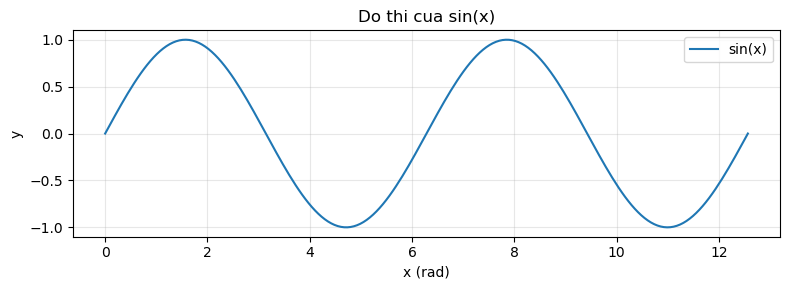

In [ ]:
import matplotlib.pyplot as plt

# Tao mot figure va mot axes
fig, ax = plt.subplots(figsize=(8, 3))

# Ve duong cong
x = np.linspace(0, 4*np.pi, 200)
y = np.sin(x)
ax.plot(x, y, label="sin(x)")

# Trang tri
ax.set_xlabel("x (rad)")
ax.set_ylabel("y")
ax.set_title("Do thi cua sin(x)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

### Nhiều đồ thị cạnh nhau

Dùng `plt.subplots(nrows, ncols)` để tạo lưới axes.

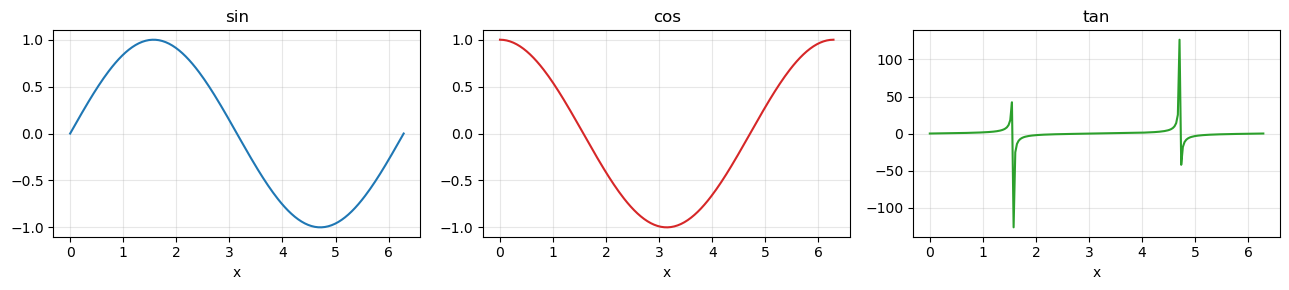

In [ ]:
# 1 hang, 3 cot
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

x = np.linspace(0, 2*np.pi, 200)
axes[0].plot(x, np.sin(x));        axes[0].set_title("sin")
axes[1].plot(x, np.cos(x), "C3");  axes[1].set_title("cos")
axes[2].plot(x, np.tan(x), "C2");  axes[2].set_title("tan")
for ax in axes:
    ax.grid(True, alpha=0.3); ax.set_xlabel("x")
plt.tight_layout(); plt.show()

---

## Phần 0.7 — Tạo sóng sin từ một dòng code

Sóng sin thuần là tín hiệu cơ bản nhất. Công thức:

$$
x(t) = A \sin(2\pi f t + \phi)
$$

- $A$ — biên độ (amplitude). Quyết định độ to.
- $f$ — tần số (Hz). Quyết định cao độ.
- $\phi$ — pha ban đầu (rad).

Sau khi lấy mẫu với $f_s$ Hz: $x[n] = A \sin(2\pi f n / f_s + \phi)$
với $n = 0, 1, \dots, N-1$.

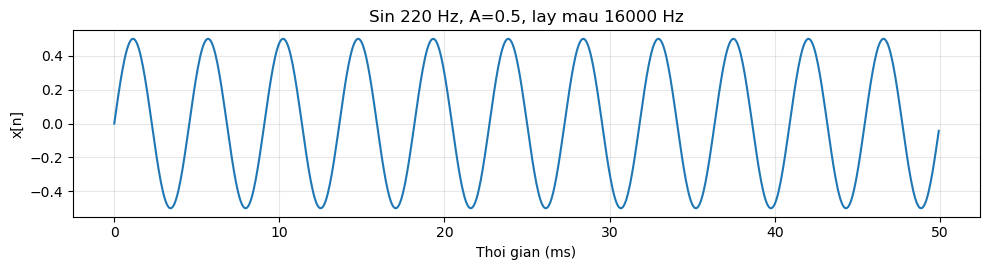

So mau N = 800, chu ky T0 = 4.55 ms = 72.7 mau


In [ ]:
fs   = 16000           # sample rate Hz
T    = 0.05            # 50 ms
f0   = 220.0           # tan so 220 Hz (note A3)
A    = 0.5
phi  = 0.0

N = int(T * fs)
n = np.arange(N)
x = A * np.sin(2*np.pi*f0*n/fs + phi)

# Ve 50 ms tin hieu
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(n / fs * 1000, x)
ax.set(xlabel="Thoi gian (ms)", ylabel="x[n]",
       title=f"Sin {f0:.0f} Hz, A={A}, lay mau {fs} Hz")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"So mau N = {N}, chu ky T0 = {1/f0*1000:.2f} ms = {fs/f0:.1f} mau")

---

## Phần 0.8 — Đọc file WAV: biến âm thanh thành mảng số

File WAV chứa dãy số 16-bit (thường là `int16`) đại diện cho áp suất âm
thanh đã lấy mẫu. Thư viện `soundfile` đọc trực tiếp thành mảng numpy.

### Cú pháp

```python
import soundfile as sf
x, sr = sf.read("file.wav", dtype="float32")
# x  - numpy array, da chuan hoa ve [-1, 1]
# sr - sample rate (Hz)
```

Nếu file stereo (2 kênh), `x` có shape `(N, 2)`. Với DSP cơ bản, ta
thường chuyển sang mono bằng cách trung bình hai kênh:

```python
if x.ndim > 1:
    x = x.mean(axis=1)
```

Da ghi: C:\Users\minht\AppData\Local\Temp\ch0_demo.wav (64,058 bytes)
Doc lai: shape=(16000,), sr=16000, min=-0.400, max=0.400


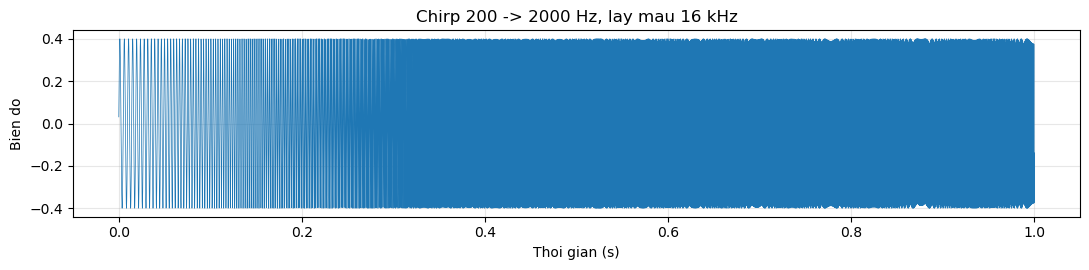

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from pathlib import Path
import tempfile

fs = 16000
T  = 1.0
n = np.arange(int(T*fs))
# Tin hieu chirp tu 200 Hz den 2000 Hz
f_t = 200 + (2000 - 200) * (n / len(n))
x_demo = 0.4 * np.sin(2*np.pi * np.cumsum(f_t) / fs)

tmp_dir = Path(tempfile.gettempdir())
wav_path = tmp_dir / "ch0_demo.wav"
wavfile.write(str(wav_path), fs, x_demo.astype(np.float32))
print("Da ghi:", wav_path, f"({wav_path.stat().st_size:,} bytes)")

# Doc lai — luu y scipy tra ve (rate, data), nguoc voi soundfile
sr_read, x_read = wavfile.read(str(wav_path))
print(f"Doc lai: shape={x_read.shape}, sr={sr_read}, "
      f"min={x_read.min():.3f}, max={x_read.max():.3f}")

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.plot(np.arange(len(x_read))/sr_read, x_read, lw=0.5)
ax.set(xlabel="Thoi gian (s)", ylabel="Bien do",
       title="Chirp 200 -> 2000 Hz, lay mau 16 kHz")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---

## Phần 0.9 — Pandas DataFrame: quản lý danh sách file

Khi xử lý hàng nghìn file, ta cần một bảng metadata: tên file, nhãn,
người nói, độ dài, ... Pandas cung cấp đối tượng **DataFrame** — bảng
2 chiều có tên cột.

### Cú pháp tạo

```python
df = pd.DataFrame([
    {"path": "a.wav", "label": "Angry", "duration": 1.2},
    {"path": "b.wav", "label": "Sad",   "duration": 0.8},
])
```

### Truy vấn cơ bản

| Thao tác | Cú pháp |
|---|---|
| Lấy 1 cột | `df["label"]` hoặc `df.label` |
| Lọc theo điều kiện | `df[df.duration > 1.0]` |
| Đếm theo nhóm | `df.groupby("label").size()` |
| Thống kê | `df.describe()` |
| Trung bình theo nhóm | `df.groupby("label")["duration"].mean()` |

In [ ]:
import pandas as pd

df = pd.DataFrame([
    {"path": f"f_{i:03d}.wav",
     "label": np.random.choice(["Angry","Happy","Neutral","Sad"]),
     "duration": np.random.uniform(0.5, 3.0),
     "rms": np.random.uniform(0.05, 0.25)}
    for i in range(20)
])
print(df.head())
print()
print("So file moi nhan:")
print(df.groupby("label").size().to_string())
print()
print("Thong ke duration & rms theo nhan:")
print(df.groupby("label")[["duration","rms"]].mean().round(3).to_string())

        path    label  duration       rms
0  f_000.wav  Neutral  1.443353  0.167625
1  f_001.wav  Neutral  2.072879  0.059012
2  f_002.wav    Angry  0.621226  0.099181
3  f_003.wav  Neutral  2.592091  0.146933
4  f_004.wav  Neutral  1.536159  0.164443

So file moi nhan:
label
Angry      9
Happy      2
Neutral    6
Sad        3

Thong ke duration & rms theo nhan:
         duration    rms
label                   
Angry       1.513  0.161
Happy       0.667  0.152
Neutral     1.964  0.136
Sad         1.343  0.101


---

## Phần 0.10 — Cache với parquet: không tính lại từ đầu

Quét toàn bộ VIVOS (12.420 file) hoặc tính LPC trên 423 file CVEAD mất
nhiều phút. Tránh lãng phí: lưu kết quả lần đầu, lần sau đọc từ đĩa.

**Parquet** là định dạng cột nén nhanh hơn CSV gấp 5-10 lần và giữ
đúng kiểu dữ liệu.

### Mẫu chuẩn

```python
cache = Path("cache_dsp/ten_file.parquet")
if cache.exists():
    df = pd.read_parquet(cache)
else:
    df = ham_tinh_nang(...)        # tính lần đầu, có thể tốn vài phút
    df.to_parquet(cache, index=False)
```

Mẫu này lặp lại trong mọi cell batch của Chương 1-5.

In [ ]:
# Demo: ghi va doc lai
from pathlib import Path
import tempfile

cache = Path(tempfile.gettempdir()) / "ch0_demo_cache.parquet"
df.to_parquet(cache, index=False)
print(f"Da ghi: {cache} ({cache.stat().st_size:,} bytes)")

df_back = pd.read_parquet(cache)
print(f"Doc lai: {len(df_back)} dong, cot: {list(df_back.columns)}")
print("Ban dau khop:", df.equals(df_back))

Da ghi: C:\Users\minht\AppData\Local\Temp\ch0_demo_cache.parquet (3,181 bytes)
Doc lai: 20 dong, cot: ['path', 'label', 'duration', 'rms']
Ban dau khop: True


---

## Phần 0.11 — Bảng cheat-sheet công thức toán

Để theo dõi 5 chương, hãy ghi nhớ 12 công thức cốt lõi sau:

| # | Công thức | Tên | Chương |
|---|---|---|---|
| 1 | $x[n] = x_a(nT_s),\ T_s = 1/f_s$ | Lấy mẫu | 1 |
| 2 | $E_x = \sum_n |x[n]|^2$ | Năng lượng | 1 |
| 3 | $r_{xx}[\ell] = \sum_n x[n]\,x[n+\ell]$ | Tương quan tự | 1 |
| 4 | $y[n] = x[n] * h[n] = \sum_k x[k] h[n-k]$ | Tích chập | 1 |
| 5 | $X(z) = \sum_n x[n]\,z^{-n}$ | Biến đổi Z | 2 |
| 6 | $H(z) = \dfrac{Y(z)}{X(z)}$ | Hàm truyền | 2 |
| 7 | hệ ổn định ⇔ mọi cực có $|z_p| < 1$ | Điều kiện ổn định | 2 |
| 8 | $X(\omega) = \sum_n x[n] e^{-j\omega n}$ | DTFT | 3 |
| 9 | $X[k] = \sum_{n=0}^{N-1} x[n] e^{-j 2\pi k n/N}$ | DFT | 4 |
| 10 | FFT: $\mathcal{O}(N \log N)$ | Cooley-Tukey | 4 |
| 11 | $\text{SNR}_q \approx 6.02B + 1.76$ dB | SNR lượng tử hoá | 1 |
| 12 | $f_s > 2 f_{\max}$ | Định lý Nyquist | 1, 3 |

**Mẹo nhớ chữ cái biến:**

- $n$ — chỉ số mẫu (rời rạc, nguyên).
- $t$ — thời gian liên tục (giây).
- $f$ — tần số liên tục (Hz).
- $\omega$ — tần số góc rời rạc (rad), $\omega = 2\pi f / f_s$.
- $\Omega$ — tần số góc liên tục (rad/s).
- $k$ — chỉ số DFT bin.

---

## Phần 0.12 — Tổng kết Chương 0

Sau chương này, bạn cần:

- [ ] Tự viết được hàm Python với `def`, `return`, indent đúng.
- [ ] Tạo được numpy array bằng `arange`, `linspace`, `zeros`, `ones`.
- [ ] Slicing được một đoạn 25 ms tại vị trí $n_0$ trong tín hiệu.
- [ ] Đọc được file WAV bằng `soundfile.read`, biết kiểm tra `shape` và `sr`.
- [ ] Vẽ được waveform với `matplotlib.pyplot`.
- [ ] Tạo được DataFrame và group-by theo nhãn.
- [ ] Hiểu được mẫu cache parquet và biết khi nào nên dùng.

Nếu bất kỳ mục nào còn vướng, hãy chạy lại các cell tương ứng và sửa
biến thử nghiệm cho tới khi quen tay. Đừng vội sang Chương 1.

### Kiểm tra môi trường — chạy ô bên dưới

In [ ]:
import sys
print(f"Python  : {sys.version.split()[0]}")
for pkg in ["numpy", "scipy", "matplotlib", "pandas",
            "soundfile", "librosa", "tqdm", "pyarrow"]:
    try:
        m = __import__(pkg)
        v = getattr(m, "__version__", "?")
        print(f"  {pkg:11s}: {v}")
    except ImportError:
        print(f"  {pkg:11s}: CHUA CAI - chay !pip install {pkg}")

Python  : 3.13.9
  numpy      : 2.3.5
  scipy      : 1.16.3
  matplotlib : 3.10.6
  pandas     : 2.3.3
  soundfile  : 0.13.1
  librosa    : 0.11.0
  tqdm       : 4.67.1
  pyarrow    : 21.0.0


# Bài giảng Xử lý tín hiệu số — Áp dụng trên VIVOS và CVEAD

Tài liệu thực hành đi kèm bộ slide *ch1.pdf - ch5.pdf*. Mỗi chương trong
notebook tương ứng với một file slide; mỗi phần con bám sát mục số trong
slide tương ứng.

**Hai bộ dữ liệu sử dụng xuyên suốt khoá:**

| Tiêu chí | VIVOS | CVEAD |
|---|---|---|
| Ngôn ngữ | Tiếng Việt | Tiếng Anh |
| Tổng số file | 12.420 | 423 |
| Tổng thời lượng | ~15.67 giờ | ~0.5 giờ |
| Sample rate | 16 kHz đồng nhất | 16 / 44.1 / 48 kHz hỗn hợp |
| Mục đích gốc | ASR | SER (4 lớp cảm xúc) |
| Cấu trúc nhãn | Theo người nói (65 speaker) | Theo cảm xúc: Angry (120), Happy (77), Neutral (147), Sad (79) |

**Mục tiêu sư phạm:** sinh viên hiểu lý thuyết qua slide, sau đó kiểm chứng
từng khái niệm trên dữ liệu tiếng nói thực, hình thành thói quen liên kết
công thức toán với hiện tượng vật lý quan sát được.

---

## Mục lục

- **Chương 1 — Tín hiệu và Hệ thống rời rạc** (notebook hiện tại)
    - 0. Setup môi trường và hàm tiện ích
    - 1. Tín hiệu là gì? Mở file VIVOS và CVEAD, xem waveform
    - 2. Phân loại tín hiệu
    - 3. Lấy mẫu và Lượng tử hoá
    - 4. Các dãy cơ bản
    - 5. Năng lượng, Công suất, RMS
    - 6. Phép toán cơ bản trên tín hiệu
    - 7. Hệ thống LTI và Tích chập
    - 8. Tương quan và bài toán pitch (F0)
    - 9. Tổng kết và câu hỏi tự ôn
- Chương 2 — Biến đổi Z và phân tích hệ thống *(điền ở lần 2)*
- Chương 3 — Biến đổi Fourier (DTFT) *(điền ở lần 3)*
- Chương 4 — DFT, FFT, Spectrogram *(điền ở lần 4)*
- Chương 5 — Thiết kế bộ lọc số và tổng hợp *(điền ở lần 5)*

---

# Chương 1 — Tín hiệu và Hệ thống rời rạc

## Phần 0 — Setup môi trường và hàm tiện ích

*Bám sát ch1.pdf — phần dẫn nhập.*

Phần này khởi tạo môi trường, định nghĩa hai hàm tiện ích `doc_wav` và
`lay_wav_files` được dùng xuyên suốt notebook để tách nội dung học thuật
khỏi thao tác I/O lặp đi lặp lại.

### 0.1 Cài đặt thư viện (chỉ chạy lần đầu)

In [ ]:
# !pip install numpy scipy matplotlib pandas librosa soundfile tqdm pyarrow

### 0.2 Import thư viện và cấu hình

In [ ]:
%pip install pandas soundfile librosa tqdm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd, soundfile as sf, librosa, tqdm
print(pd.__version__, sf.__version__, librosa.__version__, tqdm.__version__)

2.3.3 0.13.1 0.11.0 4.67.1


In [ ]:
from tqdm import tqdm   # thay cho tqdm.auto

In [ ]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [ ]:
!jupyter nbextension enable --py widgetsnbextension

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: console dejavu events execute kernel kernelspec lab
labextension labhub migrate nbconvert notebook qtconsole run script server
troubleshoot trust

Jupyter command `jupyter-nbextension` not found.


In [ ]:
import os, sys, math, time, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sps
import soundfile as sf
import librosa
import librosa.display
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(0)

plt.rcParams["figure.figsize"] = (10, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"Python   : {sys.version.split()[0]}")
print(f"NumPy    : {np.__version__}")
print(f"librosa  : {librosa.__version__}")

Python   : 3.13.9
NumPy    : 2.3.5
librosa  : 0.11.0


### 0.3 Cấu hình đường dẫn dataset

Notebook tự động dò hai cấu trúc thư mục thường gặp: chạy trong
`Colab_Notebooks/` của project, hoặc chạy trên Google Colab sau khi mount
Drive. Nếu vị trí khác, gán biến môi trường `DSP_ROOT` trước khi chạy.

In [ ]:
import os
from pathlib import Path

# 1. Gán trực tiếp đường dẫn gốc (đã sửa theo máy của bạn)
DSP_ROOT = Path(r"D:\HocTap_PTIT\XuLyTinHieuSo")

# 2. Định nghĩa các thư mục con dựa trên DSP_ROOT
VIVOS_DIR = DSP_ROOT / "Datasets" / "7068130" / "vivos"
CVEAD_DIR = DSP_ROOT / "Datasets" / "CVEAD"
CACHE_DIR = DSP_ROOT / "cache_dsp"

# Tạo thư mục cache nếu chưa có
CACHE_DIR.mkdir(exist_ok=True)

# 3. Kiểm tra sự tồn tại của dữ liệu
if not DSP_ROOT.exists():
    print(f"❌ CẢNH BÁO: Không tìm thấy DSP_ROOT tại {DSP_ROOT}")

assert VIVOS_DIR.exists(), f"Khong thay VIVOS tai {VIVOS_DIR}"
assert CVEAD_DIR.exists(), f"Khong thay CVEAD tai {CVEAD_DIR}"

# 4. In kết quả kiểm tra
print("✅ Cấu hình đường dẫn thành công:")
print("DSP_ROOT :", DSP_ROOT)
print("VIVOS    :", VIVOS_DIR)
print("CVEAD    :", CVEAD_DIR)
print("CACHE    :", CACHE_DIR)


✅ Cấu hình đường dẫn thành công:
DSP_ROOT : D:\HocTap_PTIT\XuLyTinHieuSo
VIVOS    : D:\HocTap_PTIT\XuLyTinHieuSo\Datasets\7068130\vivos
CVEAD    : D:\HocTap_PTIT\XuLyTinHieuSo\Datasets\CVEAD
CACHE    : D:\HocTap_PTIT\XuLyTinHieuSo\cache_dsp


### 0.4 Hàm `doc_wav` — đọc một file WAV

Trả về `(x, fs)` với `x` là mảng float32 mono đã được chuẩn hoá biên độ
về dải [-1, 1]. Ưu tiên `soundfile` (giữ nguyên sample rate gốc); chỉ
resample khi gọi với tham số `sr_target`.

In [ ]:
def doc_wav(path, sr_target=None):
    # Doc file WAV, chuyen stereo -> mono, optional resample ve sr_target
    x, sr = sf.read(str(path), dtype="float32", always_2d=False)
    if x.ndim > 1:
        x = x.mean(axis=1)
    if sr_target is not None and sr != sr_target:
        x = librosa.resample(x, orig_sr=sr, target_sr=sr_target)
        sr = sr_target
    return x.astype(np.float32), int(sr)

### 0.5 Hàm `lay_wav_files` — duyệt file theo dataset

- `dataset="VIVOS"`: trả về danh sách file. `split` chọn `train`, `test`
  hoặc `None` (lấy cả hai). Mỗi phần tử kèm metadata người nói.
- `dataset="CVEAD"`: hỗ trợ lọc theo nhãn cảm xúc (`label=` một trong
  `"Angry"`, `"Happy"`, `"Neutral"`, `"Sad"`, hoặc `None` để lấy tất cả).

Tham số `n` giới hạn số file trả về (lấy mẫu đều tay) — hữu ích cho minh hoạ.

In [ ]:
def lay_wav_files(dataset, label=None, split=None, n=None, seed=0):
    # Tra ve list[dict] voi khoa: path, dataset, label, speaker, split
    rows = []

    if dataset.upper() == "VIVOS":
        splits = ["train", "test"] if split is None else [split]
        for sp in splits:
            prompts_file = VIVOS_DIR / sp / "prompts.txt"
            prompts = {}
            if prompts_file.exists():
                for line in prompts_file.read_text(encoding="utf-8").splitlines():
                    line = line.strip()
                    if not line:
                        continue
                    k, _, t = line.partition(" ")
                    prompts[k] = t
            for spk_dir in sorted((VIVOS_DIR / sp / "waves").iterdir()):
                if not spk_dir.is_dir():
                    continue
                for wav in sorted(spk_dir.glob("*.wav")):
                    rows.append({
                        "path": str(wav),
                        "dataset": "VIVOS",
                        "label": spk_dir.name,
                        "speaker": spk_dir.name,
                        "split": sp,
                        "transcript": prompts.get(wav.stem, ""),
                    })

    elif dataset.upper() == "CVEAD":
        labels = ["Angry", "Happy", "Neutral", "Sad"] if label is None else [label]
        for cls in labels:
            cls_dir = CVEAD_DIR / "CVEAD_Audio_files" / "WAV" / cls
            if not cls_dir.exists():
                continue
            for wav in sorted(cls_dir.glob("*.wav")):
                rows.append({
                    "path": str(wav),
                    "dataset": "CVEAD",
                    "label": cls,
                    "speaker": wav.stem,
                    "split": "all",
                    "transcript": "",
                })

    else:
        raise ValueError(f"Dataset khong ho tro: {dataset}")

    if n is not None and len(rows) > n:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(rows), size=n, replace=False)
        rows = [rows[i] for i in sorted(idx)]
    return rows


viv_all = lay_wav_files("VIVOS")
cve_all = lay_wav_files("CVEAD")
print(f"VIVOS : {len(viv_all):>6} file, "
      f"{len(set(r['speaker'] for r in viv_all))} nguoi noi")
print(f"CVEAD : {len(cve_all):>6} file")
for cls in ["Angry", "Happy", "Neutral", "Sad"]:
    n_cls = sum(1 for r in cve_all if r["label"] == cls)
    print(f"  - {cls:8s}: {n_cls:3d} file")

VIVOS :  12420 file, 65 nguoi noi
CVEAD :    423 file
  - Angry   : 120 file
  - Happy   :  77 file
  - Neutral : 147 file
  - Sad     :  79 file


---

## Phần 1 — Tín hiệu là gì? Quan sát waveform

*Bám sát ch1.pdf §1.*

**Tín hiệu** là một đại lượng vật lý mang thông tin, biểu diễn dưới dạng
hàm của một hoặc nhiều biến độc lập. Trong xử lý tiếng nói, biến độc lập
là thời gian; đại lượng vật lý là áp suất âm thanh được biến đổi thành
điện áp qua microphone.

**Tín hiệu số** là dãy giá trị $x[n]$ với $n \in \mathbb{Z}$, thu được
bằng cách lấy mẫu tín hiệu liên tục $x_a(t)$ tại các thời điểm cách đều
$T_s$:

$$
x[n] = x_a(n T_s), \qquad T_s = \frac{1}{f_s}
$$

Trong đó $f_s$ là sample rate (Hz). VIVOS sử dụng $f_s = 16000$ Hz; CVEAD
không đồng nhất — có file 16 kHz, 44.1 kHz và 48 kHz xen kẽ.

### 1.1 Đọc và quan sát một file VIVOS

File       : VIVOSSPK01_R001.wav
Nguoi noi  : VIVOSSPK01
Transcript : KHÁCH SẠN
Sample rate: 16000 Hz
So mau     : 48,000 (~3.00 s)
Bien do    : min=-0.293, max=+0.252


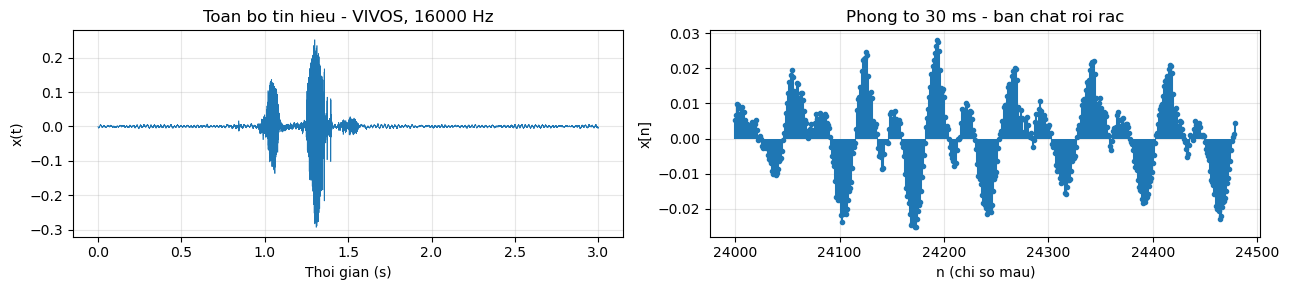

In [ ]:
viv_demo = lay_wav_files("VIVOS", split="train")[0]
x_viv, fs_viv = doc_wav(viv_demo["path"])
n_viv = np.arange(len(x_viv))

print("File       :", Path(viv_demo["path"]).name)
print("Nguoi noi  :", viv_demo["speaker"])
print("Transcript :", viv_demo["transcript"])
print(f"Sample rate: {fs_viv} Hz")
print(f"So mau     : {len(x_viv):,} (~{len(x_viv)/fs_viv:.2f} s)")
print(f"Bien do    : min={x_viv.min():+.3f}, max={x_viv.max():+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].plot(n_viv / fs_viv, x_viv, lw=0.5)
axes[0].set(xlabel="Thoi gian (s)", ylabel="x(t)",
            title=f"Toan bo tin hieu - VIVOS, {fs_viv} Hz")

mid = len(x_viv) // 2
zoom = slice(mid, mid + int(0.030 * fs_viv))
axes[1].stem(n_viv[zoom], x_viv[zoom], basefmt=" ",
             markerfmt="C0.", linefmt="C0-")
axes[1].set(xlabel="n (chi so mau)", ylabel="x[n]",
            title="Phong to 30 ms - ban chat roi rac")
plt.tight_layout(); plt.show()

### 1.2 So sánh waveform 4 lớp cảm xúc CVEAD

Mỗi cảm xúc lấy một file đại diện. Quan sát ban đầu: tín hiệu Angry/Happy
có biên độ trung bình lớn hơn và biến thiên nhanh hơn so với Neutral/Sad —
đây là tiền đề cho phân biệt cảm xúc dựa trên năng lượng/phổ ở các phần
sau.

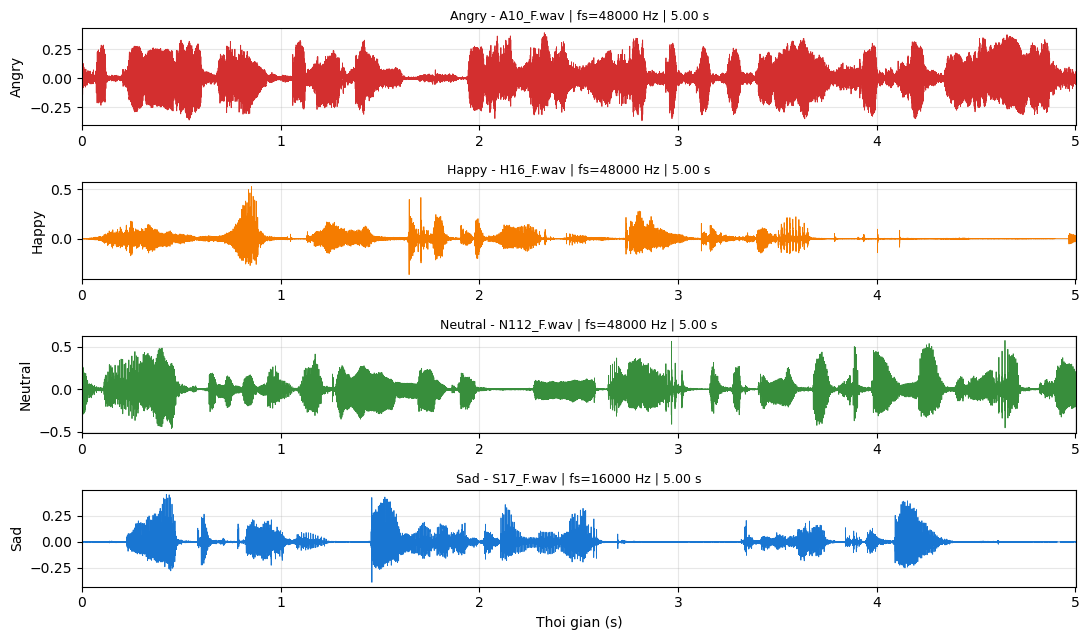

In [ ]:
labels_emo = ["Angry", "Happy", "Neutral", "Sad"]
colors_emo = ["#d32f2f", "#f57c00", "#388e3c", "#1976d2"]

fig, axes = plt.subplots(4, 1, figsize=(11, 6.5), sharex=False)
for ax, cls, c in zip(axes, labels_emo, colors_emo):
    files = lay_wav_files("CVEAD", label=cls, n=1, seed=42)
    x_cve, fs_cve = doc_wav(files[0]["path"])
    t = np.arange(len(x_cve)) / fs_cve
    ax.plot(t, x_cve, color=c, lw=0.6)
    ax.set_ylabel(cls)
    ax.set_title(f"{cls} - {Path(files[0]['path']).name} | fs={fs_cve} Hz | "
                 f"{len(x_cve)/fs_cve:.2f} s", fontsize=9)
    ax.set_xlim(0, t[-1])
axes[-1].set_xlabel("Thoi gian (s)")
plt.tight_layout(); plt.show()

---

## Phần 2 — Phân loại tín hiệu

*Bám sát ch1.pdf §2.*

Slide chương 1 đưa ra bốn cặp tiêu chí phân loại cơ bản:

| Cặp tiêu chí | Trái | Phải | Tiếng nói thuộc loại |
|---|---|---|---|
| Biến thời gian | Liên tục $x_a(t)$ | Rời rạc $x[n]$ | sau khi lấy mẫu là **rời rạc** |
| Biên độ | Liên tục | Rời rạc (lượng tử hoá) | sau ADC là **rời rạc** |
| Tính chu kỳ | Tuần hoàn (chu kỳ $N_0$) | Phi tuần hoàn | toàn cục **phi tuần hoàn**, cục bộ ~30 ms gần như **tuần hoàn** ở vùng nguyên âm |
| Năng lượng / Công suất | $0<E<\infty$, $P=0$ | $E=\infty$, $0<P<\infty$ | hữu hạn → **năng lượng** |
| Tính xác định | Deterministic | Stochastic | **stochastic** (mô hình hoá Markov, GMM, neural) |

### 2.1 Tuần hoàn cục bộ — phóng to một frame nguyên âm

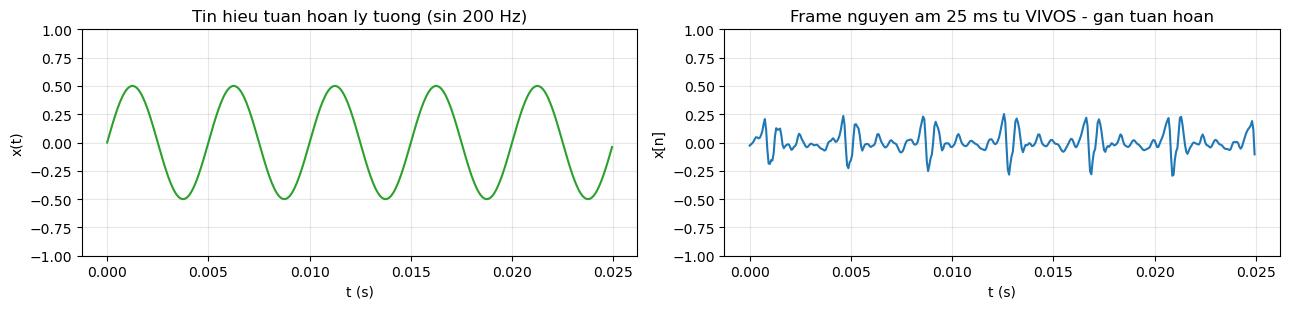

RMS frame manh nhat: 0.0873
RMS frame yeu nhat : 0.0008
Ti le dong (dynamic range): 41.3 dB


In [ ]:
# Tim vung co nang luong cao nhat bang RMS theo frame 25 ms
frame_len = int(0.025 * fs_viv)
hop = frame_len // 2
n_frames = (len(x_viv) - frame_len) // hop
rms_frames = np.array([
    np.sqrt(np.mean(x_viv[i*hop : i*hop + frame_len] ** 2))
    for i in range(n_frames)
])
i_max = int(np.argmax(rms_frames))
n0 = i_max * hop
seg = x_viv[n0 : n0 + frame_len]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
t = np.arange(frame_len) / fs_viv
axes[0].plot(t, 0.5*np.sin(2*np.pi*200*t), color="C2")
axes[0].set(xlabel="t (s)", ylabel="x(t)", ylim=(-1, 1),
            title="Tin hieu tuan hoan ly tuong (sin 200 Hz)")
axes[1].plot(t, seg, color="C0")
axes[1].set(xlabel="t (s)", ylabel="x[n]", ylim=(-1, 1),
            title="Frame nguyen am 25 ms tu VIVOS - gan tuan hoan")
plt.tight_layout(); plt.show()

print(f"RMS frame manh nhat: {rms_frames.max():.4f}")
print(f"RMS frame yeu nhat : {rms_frames.min():.4f}")
print(f"Ti le dong (dynamic range): "
      f"{20*np.log10(rms_frames.max()/max(rms_frames.min(),1e-9)):.1f} dB")

### 2.2 Tín hiệu năng lượng vs tín hiệu công suất

- $E = \sum_n |x[n]|^2$. Tín hiệu năng lượng nếu $0 < E < \infty$.
- $P = \lim_{N \to \infty} \frac{1}{2N+1}\sum_{n=-N}^{N} |x[n]|^2$. Tín hiệu công suất nếu $0 < P < \infty$.

Mọi file WAV có độ dài hữu hạn đều thuộc loại tín hiệu năng lượng. Sin
kéo dài vô hạn là tín hiệu công suất với $P = A^2/2$.

In [ ]:
def E(x): return float(np.sum(x.astype(np.float64) ** 2))
def P(x): return E(x) / max(len(x), 1)

N_long = fs_viv * 5
sin_long = 0.5 * np.sin(2*np.pi*440*np.arange(N_long)/fs_viv)
print(f"VIVOS demo: E = {E(x_viv):.3f}, P = {P(x_viv):.3e}")
print(f"Sin 440Hz : E = {E(sin_long):.3f}, P = {P(sin_long):.3e} "
      f"(ly thuyet: {0.5**2/2:.3e})")

VIVOS demo: E = 12.037, P = 2.508e-04
Sin 440Hz : E = 10000.000, P = 1.250e-01 (ly thuyet: 1.250e-01)


---

## Phần 3 — Lấy mẫu và Lượng tử hoá

*Bám sát ch1.pdf §3.*

### 3.1 Định lý lấy mẫu (Nyquist–Shannon)

Cho tín hiệu liên tục $x_a(t)$ có phổ $X_a(j\Omega)$ giới hạn dải, tức
$X_a(j\Omega) = 0$ với $|\Omega| > \Omega_{\max}$. Nếu lấy mẫu với tần
số $f_s$ thoả

$$
f_s > 2 f_{\max} = \frac{\Omega_{\max}}{\pi}
$$

thì có thể khôi phục $x_a(t)$ chính xác từ dãy mẫu $x[n]$. Vi phạm điều
kiện này gây *aliasing* — các thành phần tần số trên $f_s/2$ bị gập về
dải $[0, f_s/2]$, tạo tần số giả.

### 3.2 Minh hoạ aliasing

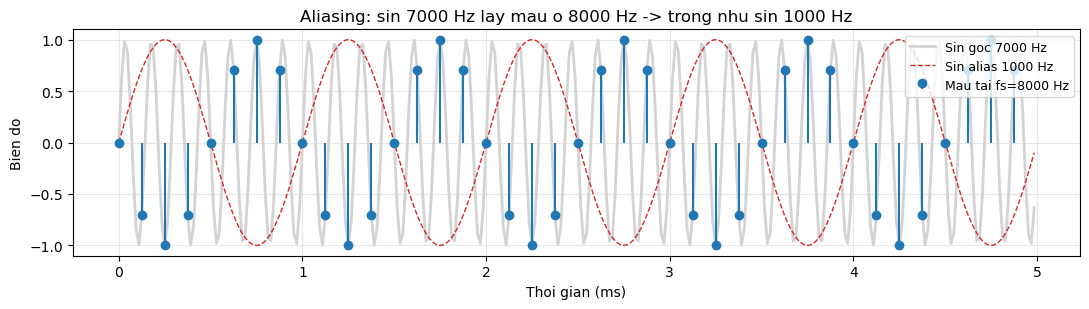

In [ ]:
f0 = 7000.0
fs_high = 64000
fs_low  = 8000

T = 0.005
t_hi = np.arange(0, T, 1/fs_high)
t_lo = np.arange(0, T, 1/fs_low)
x_hi = np.sin(2*np.pi*f0*t_hi)
x_lo = np.sin(2*np.pi*f0*t_lo)

f_alias = abs(f0 - round(f0/fs_low)*fs_low)
x_recon = np.sin(2*np.pi*f_alias*t_hi)

plt.figure(figsize=(11, 3.2))
plt.plot(t_hi*1000, x_hi, color="lightgray", lw=2,
         label=f"Sin goc {f0:.0f} Hz")
plt.plot(t_hi*1000, x_recon, "C3--", lw=1,
         label=f"Sin alias {f_alias:.0f} Hz")
plt.stem(t_lo*1000, x_lo, basefmt=" ", linefmt="C0-", markerfmt="C0o",
         label=f"Mau tai fs={fs_low} Hz")
plt.xlabel("Thoi gian (ms)")
plt.ylabel("Bien do")
plt.title(f"Aliasing: sin {f0:.0f} Hz lay mau o {fs_low} Hz "
          f"-> trong nhu sin {f_alias:.0f} Hz")
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

### 3.3 Sample rate trong VIVOS vs CVEAD

VIVOS đồng nhất 16 kHz nên không cần xử lý đặc biệt. CVEAD trộn nhiều
sample rate, bắt buộc phải resample về một giá trị thống nhất (thường
16 kHz) trước khi đưa vào pipeline ML.

In [ ]:
def quet_sample_rate(rows, ten):
    sr_list = []
    for r in tqdm(rows, desc=f"Doc header {ten}", leave=False):
        try:
            sr_list.append(sf.info(r["path"]).samplerate)
        except Exception:
            pass
    return Counter(sr_list)

sr_vivos = quet_sample_rate(viv_all, "VIVOS")
sr_cvead_per_label = {
    cls: quet_sample_rate([r for r in cve_all if r["label"] == cls], cls)
    for cls in labels_emo
}

print("VIVOS - phan phoi sample rate:")
for sr, n in sr_vivos.most_common():
    print(f"  {sr:>6} Hz : {n:5d} file")

print("\nCVEAD - phan phoi sample rate theo lop:")
all_sr = sorted({sr for c in sr_cvead_per_label.values() for sr in c})
header = "  Lop     | " + " | ".join(f"{sr:>5}Hz" for sr in all_sr) + " | Tong"
print(header); print("  " + "-"*(len(header)-2))
for cls in labels_emo:
    counts = sr_cvead_per_label[cls]
    row = "  {:8s}| ".format(cls) + " | ".join(
        f"{counts.get(sr, 0):>7d}" for sr in all_sr
    ) + f" | {sum(counts.values()):>4d}"
    print(row)

Doc header VIVOS:   0%|          | 0/12420 [00:00<?, ?it/s]

Doc header Angry:   0%|          | 0/120 [00:00<?, ?it/s]

Doc header Happy:   0%|          | 0/77 [00:00<?, ?it/s]

Doc header Neutral:   0%|          | 0/147 [00:00<?, ?it/s]

Doc header Sad:   0%|          | 0/79 [00:00<?, ?it/s]

VIVOS - phan phoi sample rate:
   16000 Hz : 12420 file

CVEAD - phan phoi sample rate theo lop:
  Lop     | 16000Hz | 48000Hz | Tong
  ----------------------------------
  Angry   |      61 |      59 |  120
  Happy   |      10 |      67 |   77
  Neutral |      74 |      73 |  147
  Sad     |      17 |      62 |   79


### 3.4 Lượng tử hoá biên độ — minh hoạ với 3 đến 16 bit

Cùng một frame tiếng nói được lượng tử hoá với độ phân giải khác nhau.
Lỗi lượng tử $e[n] = x[n] - x_q[n]$ có công suất xấp xỉ $\Delta^2/12$
với $\Delta = 2/2^B$ là bước lượng tử của $B$ bit. Tỷ số tín hiệu trên
nhiễu lượng tử lý thuyết: $\text{SNR}_q \approx 6.02 B + 1.76$ dB.

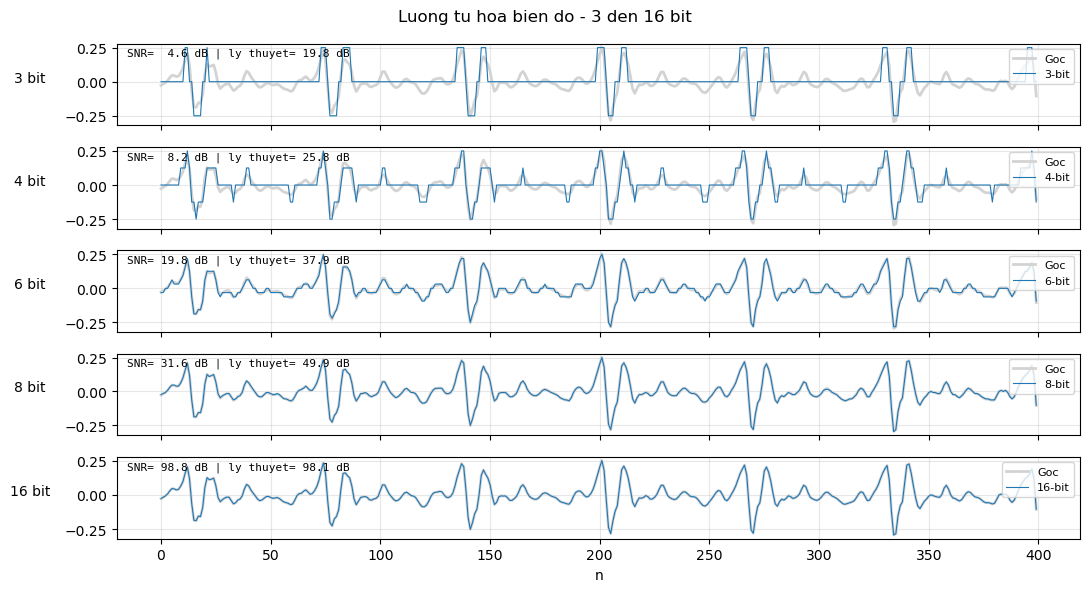

In [ ]:
def luong_tu_hoa(x, n_bits):
    n_levels = 2 ** n_bits
    step = 2.0 / n_levels
    return np.round(x / step) * step

seg = x_viv[n0 : n0 + 400].copy()
bits_list = [3, 4, 6, 8, 16]
fig, axes = plt.subplots(len(bits_list), 1, figsize=(11, 1.2*len(bits_list)),
                         sharex=True)
for ax, B in zip(axes, bits_list):
    xq = luong_tu_hoa(seg, B)
    err = seg - xq
    snr = 10*np.log10(np.var(seg) / max(np.var(err), 1e-12))
    ax.plot(seg, color="lightgray", lw=2, label="Goc")
    ax.plot(xq, color="C0", lw=0.8, label=f"{B}-bit")
    ax.set_ylabel(f"{B} bit", rotation=0, labelpad=25)
    ax.legend(loc="upper right", fontsize=8)
    ax.text(0.01, 0.85, f"SNR={snr:5.1f} dB | ly thuyet={6.02*B+1.76:5.1f} dB",
            transform=ax.transAxes, fontsize=8, family="monospace")
axes[-1].set_xlabel("n")
plt.suptitle("Luong tu hoa bien do - 3 den 16 bit"); plt.tight_layout()
plt.show()

---

## Phần 4 — Các dãy cơ bản

*Bám sát ch1.pdf §4.*

Bốn dãy dưới đây là "bảng chữ cái" của xử lý tín hiệu rời rạc. Mọi tín
hiệu phức tạp đều có thể phân tích thành tổ hợp tuyến tính của chúng.

| Tên | Định nghĩa | Vai trò |
|---|---|---|
| Xung đơn vị | $\delta[n] = \begin{cases} 1 & n=0 \\ 0 & n \neq 0 \end{cases}$ | Phần tử cơ sở; $h[n]$ chính là đáp ứng với $\delta[n]$ |
| Bước nhảy đơn vị | $u[n] = \begin{cases} 1 & n \geq 0 \\ 0 & n < 0 \end{cases}$ | Phân tích đáp ứng quá độ |
| Mũ thực | $x[n] = a^n u[n]$ | Liên hệ trực tiếp với cực của hệ LTI |
| Sin/cos | $x[n] = A\cos(\omega_0 n + \phi)$ | Cơ sở của Fourier; tín hiệu thử cho đáp ứng tần số |

Mọi tín hiệu rời rạc thoả công thức tổng hợp $x[n] = \sum_{k} x[k]\,\delta[n-k]$.

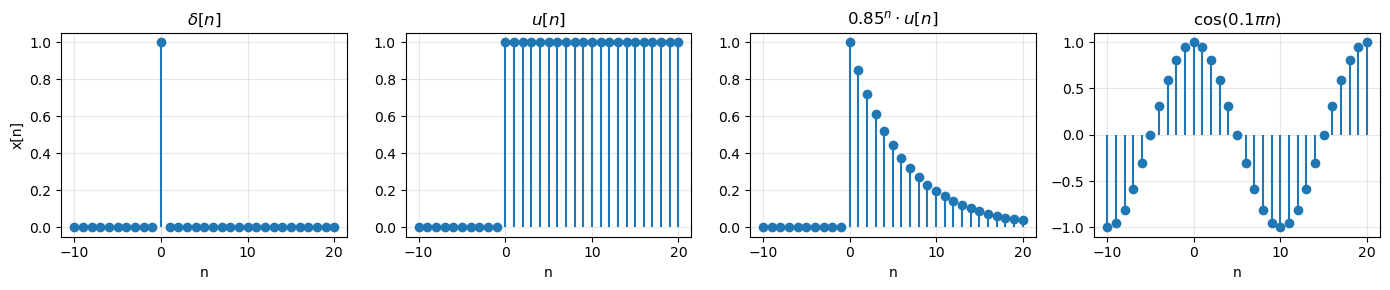

In [ ]:
n = np.arange(-10, 21)

delta = (n == 0).astype(float)
u     = (n >= 0).astype(float)
a_geo = 0.85
x_exp = (a_geo ** n) * u
x_cos = np.cos(2*np.pi*0.05*n)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, x_, title in zip(
    axes,
    [delta, u, x_exp, x_cos],
    [r"$\delta[n]$", r"$u[n]$",
     r"$0.85^n \cdot u[n]$", r"$\cos(0.1\pi n)$"]
):
    ax.stem(n, x_, basefmt=" ")
    ax.set_title(title); ax.set_xlabel("n")
axes[0].set_ylabel("x[n]")
plt.tight_layout(); plt.show()

---

## Phần 5 — Năng lượng, Công suất, RMS — so sánh 4 cảm xúc CVEAD

*Bám sát ch1.pdf §5.*

Định nghĩa cho tín hiệu hữu hạn $N$ mẫu:

$$
E = \sum_{n=0}^{N-1} |x[n]|^2,\quad
P = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2,\quad
\text{RMS} = \sqrt{P}
$$

Giả thuyết: cảm xúc Angry/Happy → cường độ phát âm cao hơn → RMS lớn hơn
Neutral/Sad. Kiểm chứng bằng cách quét **toàn bộ 423 file CVEAD** và lập
boxplot.

In [ ]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
def dac_trung_co_ban(rows, sr_target=16000):
    recs = []
    for r in tqdm(rows, desc="Tinh dac trung"):
        try:
            x, sr = doc_wav(r["path"], sr_target=sr_target)
            e   = float(np.sum(x.astype(np.float64) ** 2))
            p   = e / max(len(x), 1)
            rms = math.sqrt(p)
            zcr = float(np.mean(np.abs(np.diff(np.sign(x))) > 0))
            pk  = float(np.abs(x).max())
            recs.append({
                "path": r["path"], "label": r["label"], "dataset": r["dataset"],
                "duration": len(x)/sr, "energy": e, "rms": rms,
                "zcr": zcr, "peak": pk,
            })
        except Exception as ex:
            recs.append({"path": r["path"], "error": str(ex)})
    return pd.DataFrame(recs)


cache_p5 = CACHE_DIR / "ch1_basic_cvead.pkl"
if cache_p5.exists():
    df_cve_basic = pd.read_pickle(cache_p5)
    print(f"Doc cache: {len(df_cve_basic)} dong")
else:
    df_cve_basic = dac_trung_co_ban(cve_all)
    df_cve_basic.to_pickle(cache_p5)
    print(f"Da luu cache: {cache_p5}")

agg = df_cve_basic.groupby("label").agg(
    n=("rms", "count"),
    duration_mean=("duration", "mean"),
    rms_mean=("rms", "mean"),
    rms_std=("rms", "std"),
    zcr_mean=("zcr", "mean"),
).round(4)
print(agg.to_string())

Doc cache: 423 dong
           n  duration_mean  rms_mean  rms_std  zcr_mean
label                                                   
Angry    120         5.1700    0.0760   0.0236    0.1461
Happy     77         5.0041    0.0846   0.0447    0.1186
Neutral  147         5.0068    0.0969   0.0520    0.1476
Sad       79         5.0042    0.0698   0.0382    0.1256


C:\Users\minht\AppData\Local\Temp\ipykernel_14324\2615407940.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)
C:\Users\minht\AppData\Local\Temp\ipykernel_14324\2615407940.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)
C:\Users\minht\AppData\Local\Temp\ipykernel_14324\2615407940.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)


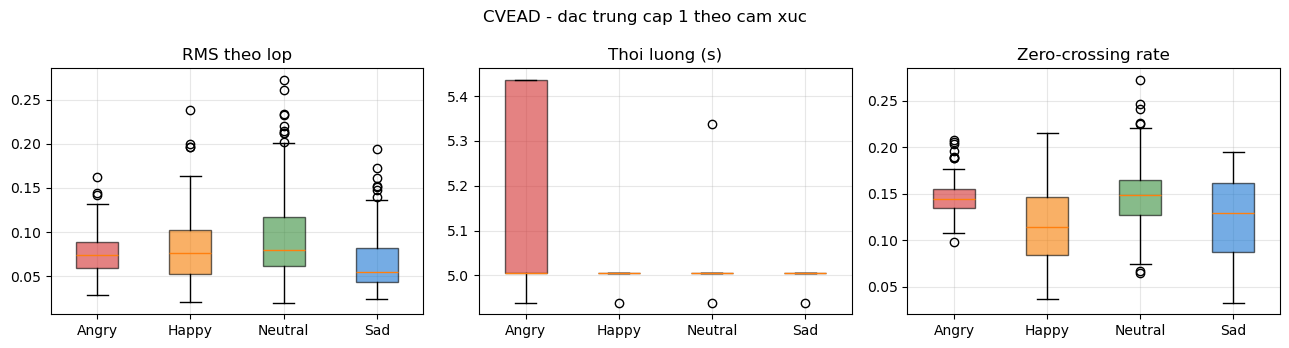

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
order = labels_emo
df_plot = df_cve_basic.dropna(subset=["rms"]).copy()
df_plot["label"] = pd.Categorical(df_plot["label"], categories=order, ordered=True)

for ax, col, title in zip(
    axes,
    ["rms", "duration", "zcr"],
    ["RMS theo lop", "Thoi luong (s)", "Zero-crossing rate"]
):
    data = [df_plot[df_plot.label == c][col].dropna().values for c in order]
    bp = ax.boxplot(data, labels=order, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors_emo):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.set_title(title)
plt.suptitle("CVEAD - dac trung cap 1 theo cam xuc")
plt.tight_layout(); plt.show()

**Đọc kết quả.** Quan sát giá trị trung vị (median) của RMS theo cảm xúc:
nếu Angry/Happy có median cao hơn rõ rệt so với Neutral/Sad, giả thuyết
ban đầu được củng cố. Lưu ý ZCR cao thường tương ứng với phụ âm xát hoặc
nhiễu cao tần — không nhất thiết liên quan đến cảm xúc theo cách tuyến tính.

---

## Phần 6 — Phép toán cơ bản trên tín hiệu

*Bám sát ch1.pdf §6.*

Năm phép toán đại số tạo nên mọi xử lý phức tạp:

| Tên | Công thức | Ý nghĩa vật lý trong tiếng nói |
|---|---|---|
| Dịch (delay/advance) | $y[n] = x[n - n_0]$ | Trễ tín hiệu (vd: tiếng vọng, đa đường) |
| Đảo trục thời gian | $y[n] = x[-n]$ | Cơ sở của tích chập, tương quan |
| Co/giãn theo $M, L$ | $y[n] = x[Mn]$ hoặc nội suy thành $x[n/L]$ | Down/up-sample |
| Nhân hằng số | $y[n] = a \cdot x[n]$ | Khuếch đại / suy giảm biên độ |
| Cộng tín hiệu | $y[n] = x_1[n] + x_2[n]$ | Trộn tiếng nói + nhiễu |

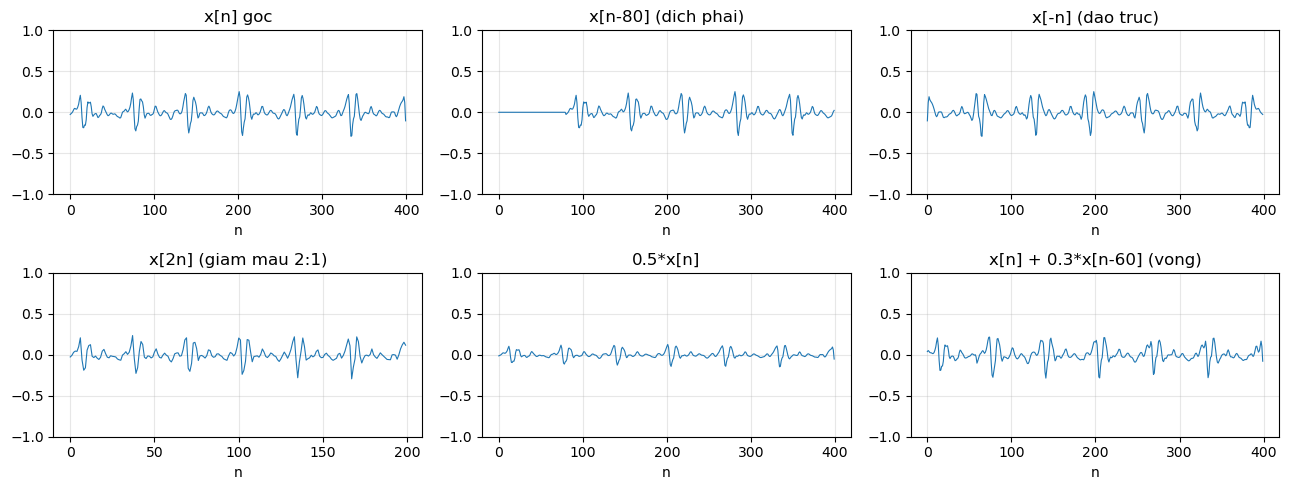

In [ ]:
seg = x_viv[n0 : n0 + 400].copy()
n_seg = np.arange(len(seg))

n_shift = 80
y_shift = np.concatenate([np.zeros(n_shift), seg])[:len(seg)]
y_flip  = seg[::-1]
y_down  = seg[::2]
y_scale = 0.5 * seg
y_mix   = seg + 0.3 * np.roll(seg, 60)

fig, axes = plt.subplots(2, 3, figsize=(13, 5))
axes = axes.ravel()
plots = [
    (n_seg, seg,                "x[n] goc"),
    (n_seg, y_shift,            f"x[n-{n_shift}] (dich phai)"),
    (n_seg, y_flip,             "x[-n] (dao truc)"),
    (np.arange(len(y_down)), y_down, "x[2n] (giam mau 2:1)"),
    (n_seg, y_scale,            "0.5*x[n]"),
    (n_seg, y_mix,              "x[n] + 0.3*x[n-60] (vong)"),
]
for ax, (xs, ys, t) in zip(axes, plots):
    ax.plot(xs, ys, lw=0.8); ax.set_title(t); ax.set_xlabel("n")
    ax.set_ylim(-1, 1)
plt.tight_layout(); plt.show()

---

## Phần 7 — Hệ thống LTI và Tích chập

*Bám sát ch1.pdf §7.*

**Hệ thống LTI** (Linear Time-Invariant) thoả đồng thời:

1. *Tuyến tính:* $\mathcal{T}\{a x_1 + b x_2\} = a \mathcal{T}\{x_1\} + b \mathcal{T}\{x_2\}$
2. *Bất biến thời gian:* nếu $y[n] = \mathcal{T}\{x[n]\}$ thì $y[n - n_0] = \mathcal{T}\{x[n - n_0]\}$

Hệ LTI được đặc trưng hoàn toàn bởi đáp ứng xung $h[n] = \mathcal{T}\{\delta[n]\}$,
và đầu ra tính qua **tích chập**:

$$
y[n] = x[n] * h[n] = \sum_{k=-\infty}^{\infty} x[k]\, h[n-k]
$$

### 7.1 Demo tích chập trên VIVOS — bộ trượt trung bình ($M$ điểm)

$h[n] = \tfrac{1}{M}$ với $n \in [0, M)$ là một LPF đơn giản. Càng tăng
$M$, tín hiệu càng bị làm mượt; thành phần tần số cao bị loại bỏ.

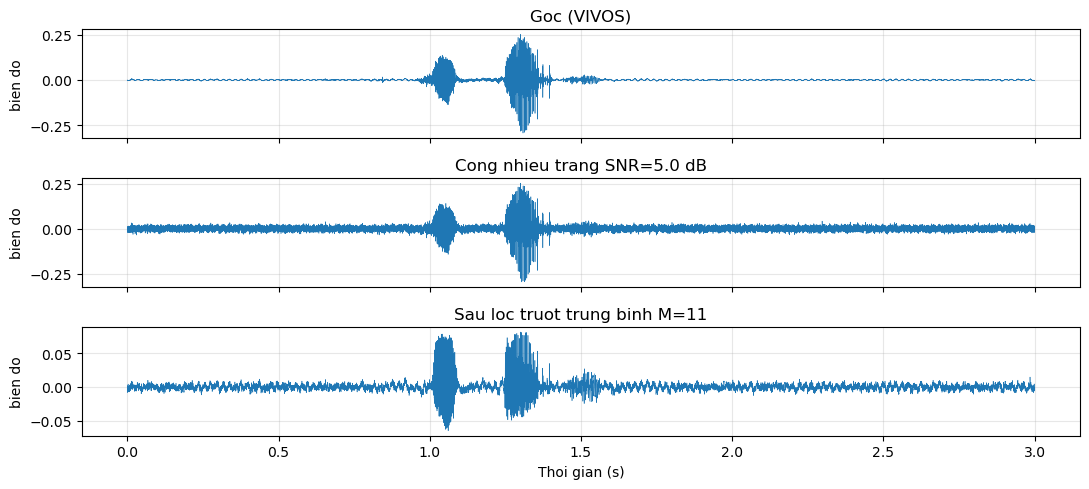

M=  3 | SNR sau loc =  8.86 dB
M=  7 | SNR sau loc =  5.05 dB
M= 11 | SNR sau loc =  1.92 dB
M= 21 | SNR sau loc =  0.18 dB
M= 51 | SNR sau loc = -0.01 dB


In [ ]:
x_clean, fs_c = doc_wav(viv_demo["path"])
sig_p   = np.mean(x_clean ** 2)
snr_db  = 5.0
noise_p = sig_p / (10 ** (snr_db/10))
rng     = np.random.default_rng(0)
noise   = rng.standard_normal(len(x_clean)).astype(np.float32) * np.sqrt(noise_p)
x_noisy = x_clean + noise

fig, axes = plt.subplots(3, 1, figsize=(11, 5), sharex=True)
for ax, sig, title in zip(
    axes,
    [x_clean, x_noisy, np.convolve(x_noisy, np.ones(11)/11, mode="same")],
    ["Goc (VIVOS)", f"Cong nhieu trang SNR={snr_db} dB",
     "Sau loc truot trung binh M=11"]
):
    ax.plot(np.arange(len(sig))/fs_c, sig, lw=0.4)
    ax.set_title(title); ax.set_ylabel("bien do")
axes[-1].set_xlabel("Thoi gian (s)")
plt.tight_layout(); plt.show()


def snr_db_func(clean, mixed):
    noise_ = mixed - clean
    return 10*np.log10(np.mean(clean**2) / max(np.mean(noise_**2), 1e-12))

for M in [3, 7, 11, 21, 51]:
    h = np.ones(M) / M
    y = np.convolve(x_noisy, h, mode="same")
    print(f"M={M:>3d} | SNR sau loc = {snr_db_func(x_clean, y):5.2f} dB")

**Quan sát.** Tăng $M$ làm SNR cải thiện đến mức nào đó rồi giảm — vì khi
cửa sổ trung bình quá rộng, thành phần tiếng nói (đặc biệt phụ âm xát
cao tần) bị triệt cùng nhiễu. Đây là minh hoạ trực quan cho bài toán
thiết kế bộ lọc, sẽ được giải triệt để ở chương 5.

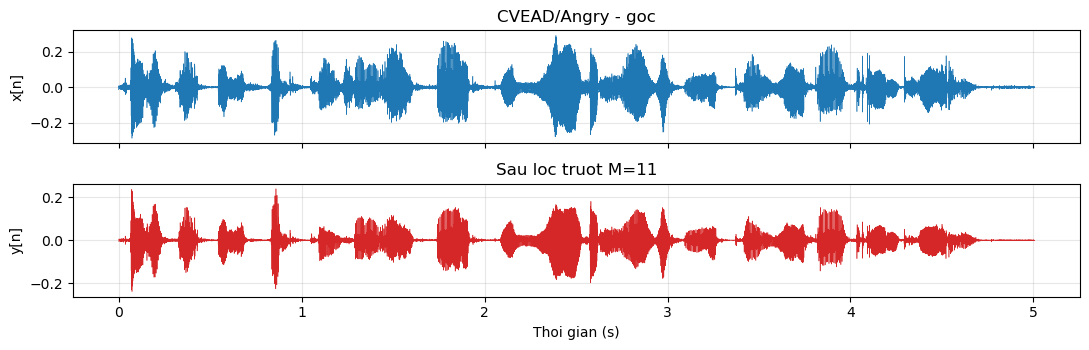

In [ ]:
cve_demo = lay_wav_files("CVEAD", label="Angry", n=1, seed=0)[0]
x_cve, fs_cve = doc_wav(cve_demo["path"], sr_target=16000)

fig, axes = plt.subplots(2, 1, figsize=(11, 3.6), sharex=True)
axes[0].plot(np.arange(len(x_cve))/fs_cve, x_cve, lw=0.4)
axes[0].set_title(f"CVEAD/{cve_demo['label']} - goc")
axes[0].set_ylabel("x[n]")
y_cve = np.convolve(x_cve, np.ones(11)/11, mode="same")
axes[1].plot(np.arange(len(y_cve))/fs_cve, y_cve, lw=0.4, color="C3")
axes[1].set_title("Sau loc truot M=11")
axes[1].set_xlabel("Thoi gian (s)"); axes[1].set_ylabel("y[n]")
plt.tight_layout(); plt.show()

---

## Phần 8 — Tương quan: ước lượng pitch (F0)

*Bám sát ch1.pdf §8.*

**Tương quan tự** (autocorrelation) của tín hiệu năng lượng:

$$
r_{xx}[\ell] = \sum_{n=-\infty}^{\infty} x[n]\, x[n + \ell]
$$

Tính chất quan trọng cho bài toán pitch:

1. $r_{xx}[\ell]$ đạt cực đại tại $\ell = 0$, bằng năng lượng $E$.
2. Nếu tín hiệu tuần hoàn cục bộ với chu kỳ $T_0$ mẫu thì $r_{xx}[\ell]$
   có cực đại phụ tại $\ell = T_0, 2T_0, \dots$
3. Đo độ trễ của cực đại phụ đầu tiên (sau khi loại $\ell = 0$) cho ước
   lượng chu kỳ pitch $T_0$, từ đó $F_0 = f_s / T_0$ (Hz).

Dải tìm kiếm thường lấy $T_0 \in [f_s/500, f_s/60]$ (tương ứng F0 ∈
[60, 500] Hz, đủ cho cả nam, nữ, trẻ em).

### 8.1 Hàm `f0_autocorr` — ước lượng F0 cho một frame

VIVOS frame nguyen am -> F0 = 246.2 Hz


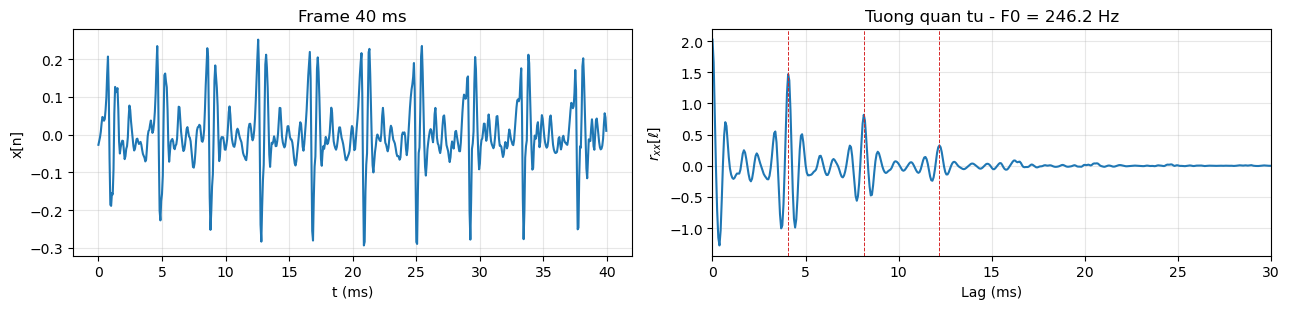

In [ ]:
def f0_autocorr(x, fs, fmin=60, fmax=500):
    x = x - x.mean()
    if len(x) < int(fs/fmin) + 5:
        return float("nan")
    x = x * np.hamming(len(x))
    r = np.correlate(x, x, mode="full")
    r = r[len(r)//2:]
    lag_min = int(fs / fmax)
    lag_max = min(int(fs / fmin), len(r) - 1)
    if lag_max <= lag_min:
        return float("nan")
    seg_r = r[lag_min:lag_max]
    lag_peak = int(np.argmax(seg_r)) + lag_min
    if r[0] > 0 and r[lag_peak] / r[0] < 0.3:
        return float("nan")
    return fs / lag_peak


seg = x_viv[n0 : n0 + int(0.04 * fs_viv)]
f0_est = f0_autocorr(seg, fs_viv)
print(f"VIVOS frame nguyen am -> F0 = {f0_est:.1f} Hz")

s = seg - seg.mean()
s = s * np.hamming(len(s))
r = np.correlate(s, s, mode="full")[len(s)-1:]
lags = np.arange(len(r))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
axes[0].plot(np.arange(len(seg))/fs_viv*1000, seg)
axes[0].set(xlabel="t (ms)", ylabel="x[n]", title="Frame 40 ms")
axes[1].plot(lags/fs_viv*1000, r)
if not math.isnan(f0_est):
    T0 = fs_viv / f0_est
    for k in range(1, 4):
        axes[1].axvline(k*T0/fs_viv*1000, color="C3", ls="--", lw=0.7)
axes[1].set(xlabel="Lag (ms)", ylabel=r"$r_{xx}[\ell]$",
            title=f"Tuong quan tu - F0 = {f0_est:.1f} Hz")
axes[1].set_xlim(0, 30)
plt.tight_layout(); plt.show()

### 8.2 So sánh F0 giữa 4 lớp cảm xúc CVEAD

Theo tâm lý học âm thanh (Scherer, Banse), Angry và Happy thường có F0
trung bình cao hơn và dao động lớn hơn so với Sad/Neutral. Đây là kiểm
chứng số học trên CVEAD.

Quy trình: cho mỗi file, chia frame 30 ms hop 10 ms, tính F0 cho từng
frame, lấy median F0 các frame có F0 hợp lệ làm đại diện file.

In [ ]:
def f0_median_file(path, sr_target=16000, frame_ms=30, hop_ms=10):
    x, sr = doc_wav(path, sr_target=sr_target)
    L = int(frame_ms / 1000 * sr)
    H = int(hop_ms   / 1000 * sr)
    f0s = []
    for i in range(0, len(x) - L, H):
        f0 = f0_autocorr(x[i:i+L], sr)
        if not math.isnan(f0):
            f0s.append(f0)
    if not f0s:
        return float("nan")
    return float(np.median(f0s))


cache_f0 = CACHE_DIR / "ch1_f0_cvead.pkl"
if cache_f0.exists():
    df_f0 = pd.read_pickle(cache_f0)
    print(f"Doc cache: {len(df_f0)} dong")
else:
    recs = []
    for r in tqdm(cve_all, desc="F0 CVEAD"):
        f0_med = f0_median_file(r["path"])
        recs.append({"path": r["path"], "label": r["label"], "f0_median": f0_med})
    df_f0 = pd.DataFrame(recs)
    df_f0.to_pickle(cache_f0)
    print(f"Da luu: {cache_f0}")

df_f0_clean = df_f0.dropna(subset=["f0_median"]).copy()

agg_f0 = df_f0_clean.groupby("label")["f0_median"].agg(
    n="count",
    median="median",
    mean="mean",
    std="std",
).round(2)
print(agg_f0.to_string())

Doc cache: 423 dong
           n  median    mean    std
label                              
Angry    120  219.18  226.78  46.91
Happy     77  197.53  196.58  43.44
Neutral  147  186.05  198.51  64.15
Sad       79  177.78  197.49  57.33


C:\Users\minht\AppData\Local\Temp\ipykernel_14324\3288532955.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_emo, patch_artist=True, showmeans=True)


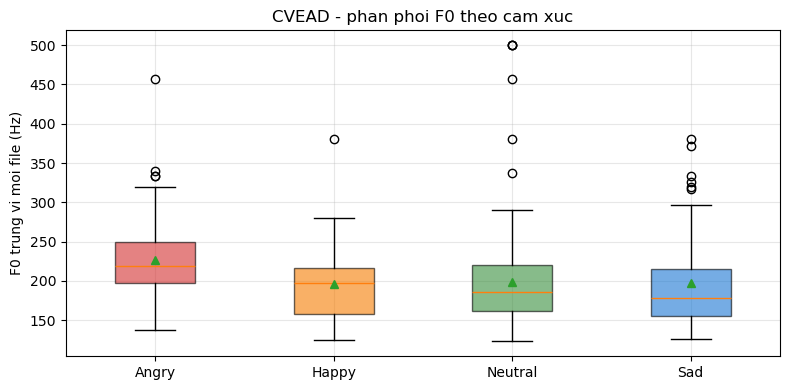

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
data = [df_f0_clean[df_f0_clean.label == c]["f0_median"].values for c in labels_emo]
bp = ax.boxplot(data, labels=labels_emo, patch_artist=True, showmeans=True)
for patch, c in zip(bp["boxes"], colors_emo):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set(ylabel="F0 trung vi moi file (Hz)",
       title="CVEAD - phan phoi F0 theo cam xuc")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
sample_viv = lay_wav_files("VIVOS", split="train", n=20, seed=1)
f0_viv = [f0_median_file(r["path"]) for r in tqdm(sample_viv, desc="F0 VIVOS sample")]
f0_viv = [f for f in f0_viv if not math.isnan(f)]
print(f"VIVOS (n={len(f0_viv)}): F0 trung vi = {np.median(f0_viv):.1f} Hz, "
      f"khoang [{min(f0_viv):.0f}, {max(f0_viv):.0f}] Hz")

F0 VIVOS sample:   0%|          | 0/20 [00:00<?, ?it/s]

VIVOS (n=20): F0 trung vi = 271.2 Hz, khoang [132, 500] Hz


---

## Phần 9 — Tổng kết Chương 1

*Bám sát ch1.pdf §9-10.*

### 9.1 Bản đồ khái niệm

Chương 1 đã đi qua một mạch logic khép kín:

1. **Định nghĩa** tín hiệu rời rạc và quan hệ với tín hiệu liên tục qua phép lấy mẫu (Phần 1, 3).
2. **Phân loại** tín hiệu theo bốn cặp tiêu chí, định vị tiếng nói trong sơ đồ phân loại (Phần 2).
3. **Bốn dãy cơ bản** đóng vai trò "phần tử cơ sở" cho mọi tín hiệu phức tạp (Phần 4).
4. **Đại lượng năng lượng** là cầu nối đầu tiên giữa toán học và đặc trưng âm học có ý nghĩa thống kê (Phần 5).
5. **Phép toán đại số** mở rộng từ một tín hiệu thành quan hệ giữa nhiều tín hiệu (Phần 6).
6. **Hệ thống LTI** và tích chập đặt nền móng cho mọi bộ lọc về sau, được giải đầy đủ trong các chương 2-5 (Phần 7).
7. **Tương quan tự** mở ra ứng dụng đầu tiên có ý nghĩa thực tế: ước lượng pitch (Phần 8).

### 9.2 Kết quả định lượng đã thu được

| Câu hỏi | Phương pháp | Phần |
|---|---|---|
| RMS có phân biệt 4 cảm xúc CVEAD không? | Boxplot, ANOVA ngầm | 5 |
| Sample rate VIVOS/CVEAD đồng nhất tới đâu? | Quét header sf.info | 3 |
| Lượng tử hoá $B$ bit cho SNR bao nhiêu? | $\text{SNR} \approx 6.02 B + 1.76$ dB | 3 |
| F0 phân biệt cảm xúc đến đâu? | Autocorrelation, boxplot | 8 |

### 9.3 Câu hỏi tự ôn

1. Cho tín hiệu liên tục $x_a(t) = \cos(2\pi \cdot 6000 \cdot t)$ lấy mẫu ở 8 kHz. Dãy mẫu thu được trùng với dãy mẫu của tín hiệu cosin tần số nào trong dải $[0, 4000]$ Hz? Vì sao?

2. Một file CVEAD có 48000 mẫu lấy ở 48 kHz. Để dùng chung pipeline với VIVOS 16 kHz cần làm gì? Bộ lọc anti-alias đặt ở đâu trong pipeline đó? (Trả lời sơ bộ ở đây, chi tiết ở chương 5.)

3. Tại sao tín hiệu tiếng nói được xếp vào loại tín hiệu năng lượng? Một bản ghi 24 giờ liên tục có còn là tín hiệu năng lượng không, vì sao?

4. Cho frame 30 ms ở $f_s = 16$ kHz. Khoảng tìm kiếm pitch để bao trùm F0 ∈ [60, 500] Hz là từ lag bao nhiêu đến bao nhiêu mẫu?

5. Vì sao tăng độ rộng cửa sổ $M$ của bộ trượt trung bình có thể *làm xấu* SNR sau một ngưỡng nào đó? Liên hệ với khái niệm dải thông sẽ học ở chương 3-5.

6. Viết công thức tính số bit tối thiểu cần lượng tử hoá để đạt $\text{SNR} \geq 60$ dB. Đáp số: $B \geq \lceil (60 - 1.76) / 6.02 \rceil = 10$ bit.

### 9.4 Cache đã sinh ra trong chương 1

| File | Nội dung | Dùng lại ở |
|---|---|---|
| `cache_dsp/ch1_basic_cvead.parquet` | RMS, ZCR, peak, duration cho 423 file CVEAD | Chương 3, 4, 5 |
| `cache_dsp/ch1_f0_cvead.parquet` | F0 trung vị mỗi file CVEAD | Chương 4 (so sánh với cepstrum) |

Chương 2 sẽ giải thích nguồn gốc lý thuyết của tích chập và bộ lọc qua biến đổi Z, đồng thời triển khai LPC để trích formant — đặc trưng quan trọng cho cả ASR (VIVOS) và SER (CVEAD).

---

# Chương 2 — Biến đổi Z và Phân tích hệ thống

Chương 1 dừng ở khái niệm tích chập trong miền thời gian. Phép tích chập
là phép toán cơ bản của hệ LTI nhưng tính trực tiếp tốn kém, đặc biệt khi
cần phân tích tính ổn định, đáp ứng tần số, hay giải phương trình sai
phân. Chương 2 giới thiệu công cụ chuyển miền — biến đổi Z — biến tích
chập thành phép nhân đại số, biến phương trình sai phân thành phương
trình đại số.

Mục lục:

- Phần 10. Định nghĩa biến đổi Z
- Phần 11. Miền hội tụ (RoC) và mặt phẳng Z
- Phần 12. Điểm cực, điểm không — ứng dụng notch 50 Hz
- Phần 13. Biến đổi Z ngược, tính chất, hàm truyền, ổn định
- Phần 14. LPC trên CVEAD — Levinson-Durbin và formant 4 cảm xúc
- Phần 15. Tổng kết chương 2

---

## Phần 10 — Định nghĩa biến đổi Z

*Bám sát ch2.pdf §1.*

### 10.1 Hai dạng định nghĩa

**Biến đổi Z hai phía** của dãy $x[n]$:

$$
X(z) = \mathrm{ZT}\{x[n]\} = \sum_{n=-\infty}^{\infty} x[n]\, z^{-n},
\qquad z \in \mathbb{C}
$$

**Biến đổi Z một phía** chỉ tính cho phần nhân quả:

$$
X_1(z) = \sum_{n=0}^{\infty} x[n]\, z^{-n}
$$

Với tín hiệu nhân quả ($x[n] = 0$ với $n < 0$), hai định nghĩa trùng nhau.
ZT một phía hữu ích khi giải phương trình sai phân có điều kiện đầu
khác 0.

### 10.2 Ví dụ sách giáo khoa: $x[n] = a^n u[n]$

Áp dụng công thức và tổng cấp số nhân:

$$
X(z) = \sum_{n=0}^{\infty} a^n z^{-n} = \sum_{n=0}^{\infty} (a z^{-1})^n
     = \frac{1}{1 - a z^{-1}}, \qquad |z| > |a|
$$

Chuỗi hội tụ khi $|a z^{-1}| < 1$ tức $|z| > |a|$ — đây là miền hội tụ
(RoC). Ngoài RoC chuỗi phân kỳ; trong RoC ZT là một hàm hữu tỷ.

In [ ]:
# Tính ZT số cho dãy hữu hạn x[n], n = 0..N-1
# X(z) = sum_{n=0}^{N-1} x[n] z^{-n}
def ZT_huu_han(x, z):
    x = np.asarray(x)
    n = np.arange(len(x))
    return np.sum(x * z ** (-n))

# Kiem tra voi x[n] = 0.7^n u[n] tai N = 50
a = 0.7
N = 50
x = a ** np.arange(N)
# So sanh ZT so voi cong thuc dong 1/(1-a z^{-1}) tai |z| > |a|
z_test = [1.5, 2.0, 1.0 + 0.5j, 0.71]
for z0 in z_test:
    X_num = ZT_huu_han(x, z0)
    X_cf  = 1.0 / (1 - a * z0 ** -1)
    print(f"z = {z0:>15} | ZT so = {X_num:+.4f}  | Cong thuc = {X_cf:+.4f}")

z =             1.5 | ZT so = +1.8750  | Cong thuc = +1.8750
z =             2.0 | ZT so = +1.5385  | Cong thuc = +1.5385
z =        (1+0.5j) | ZT so = +1.6176-1.0294j  | Cong thuc = +1.6176-1.0294j
z =            0.71 | ZT so = +36.0664  | Cong thuc = +71.0000


Với $|z|$ càng gần biên RoC (gần 0.7), giá trị ZT số càng lệch xa công
thức đóng — vì cần $N \to \infty$ để chuỗi hội tụ thực sự. Tăng $N$ sẽ
giảm khoảng cách.

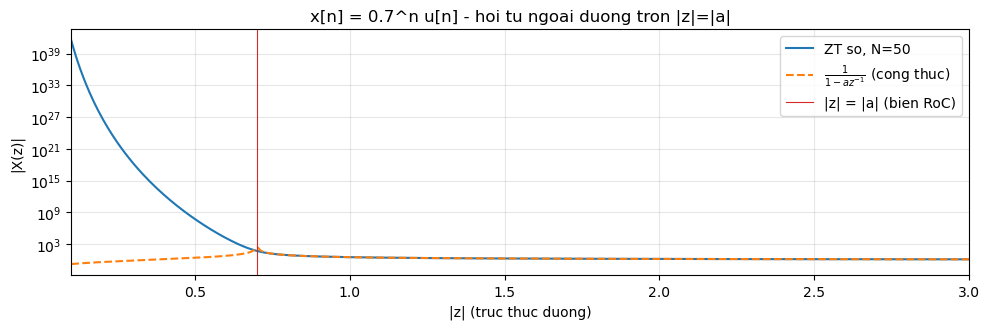

In [ ]:
rs = np.linspace(0.1, 3.0, 400)
X_num = np.array([ZT_huu_han(x, r) for r in rs])
X_cf  = 1.0 / (1 - a / rs)

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(rs, np.abs(X_num), label=f"ZT so, N={N}")
ax.plot(rs, np.abs(X_cf),  "--", label=r"$\frac{1}{1-a z^{-1}}$ (cong thuc)")
ax.axvline(a, color="C3", lw=0.8, label="|z| = |a| (bien RoC)")
ax.set(xlabel="|z| (truc thuc duong)", ylabel="|X(z)|",
       title=f"x[n] = {a}^n u[n] - hoi tu ngoai duong tron |z|=|a|",
       yscale="log", xlim=(0.1, 3.0))
ax.legend(); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout(); plt.show()

---

## Phần 11 — Miền hội tụ và mặt phẳng Z

*Bám sát ch2.pdf §2.*

### 11.1 Mặt phẳng Z

Biến phức $z = a + jb = r e^{j\omega}$ được biểu diễn trên mặt phẳng phức.
Hai đặc trưng: bán kính $r = |z|$ và góc $\omega = \arg z$. Đường tròn
đơn vị $|z| = 1$ đóng vai trò trung tâm — DTFT chính là ZT đánh giá trên
đường này (xem chương 3).

### 11.2 Bốn dạng RoC theo bản chất tín hiệu

| Loại tín hiệu | RoC điển hình | Lý giải |
|---|---|---|
| Nhân quả ($x[n]=0$ khi $n<0$), độ dài vô hạn | Bên ngoài $|z| = R_{x-}$ | Chuỗi hội tụ khi $|z|$ đủ lớn để $z^{-n}$ bù trừ tăng của $x[n]$ |
| Phản nhân quả ($x[n]=0$ khi $n \ge 0$), độ dài vô hạn | Bên trong $|z| = R_{x+}$ | Đối xứng với trường hợp trên |
| Hai phía | Hình vành khăn $R_{x-} < \|z\| < R_{x+}$ | Cần đồng thời hai điều kiện trên |
| Hữu hạn ($n_1 \le n \le n_2$) | Toàn bộ mặt phẳng (trừ 0 và/hoặc ∞) | Tổng hữu hạn luôn hội tụ |

### 11.3 Minh hoạ trực quan

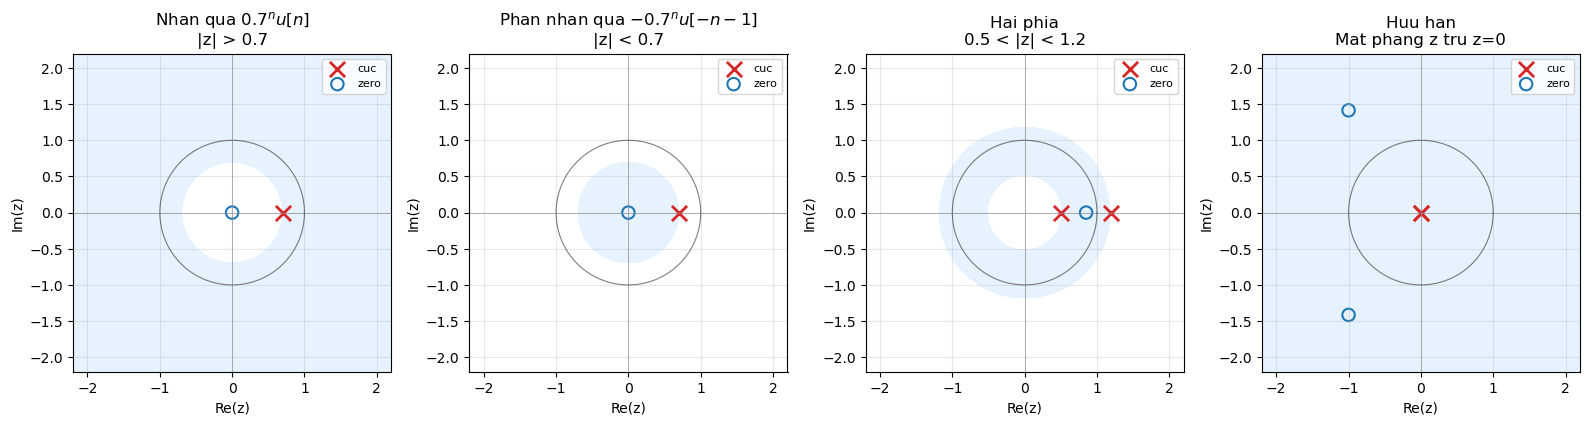

In [ ]:
def ve_mat_phang_z(ax, poles, zeros, roc_type, R_minus=None, R_plus=None,
                   title=""):
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), "k-", lw=0.8, alpha=0.5)
    r = np.linspace(0.01, 3.5, 80)
    T, R = np.meshgrid(theta, r)
    X = R * np.cos(T); Y = R * np.sin(T)
    mask = np.zeros_like(R, dtype=bool)
    if roc_type == "nhan_qua":
        mask = R > R_minus
    elif roc_type == "phan_nhan_qua":
        mask = R < R_plus
    elif roc_type == "hai_phia":
        mask = (R > R_minus) & (R < R_plus)
    elif roc_type == "huu_han":
        mask = R > 0.01
    ax.contourf(X, Y, mask.astype(int), levels=[0.5, 1.5],
                colors=["#cfe8ff"], alpha=0.5)
    if len(poles):
        ax.scatter(np.real(poles), np.imag(poles), marker="x",
                   s=120, c="C3", lw=2, label="cuc")
    if len(zeros):
        ax.scatter(np.real(zeros), np.imag(zeros), marker="o",
                   s=80, facecolors="none", edgecolors="C0", lw=1.5,
                   label="zero")
    ax.axhline(0, lw=0.4, color="gray")
    ax.axvline(0, lw=0.4, color="gray")
    ax.set(xlim=(-2.2, 2.2), ylim=(-2.2, 2.2), aspect="equal", title=title)
    ax.set_xlabel("Re(z)"); ax.set_ylabel("Im(z)")
    ax.legend(loc="upper right", fontsize=8)


fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ve_mat_phang_z(axes[0], poles=[0.7], zeros=[0], roc_type="nhan_qua",
               R_minus=0.7,
               title="Nhan qua $0.7^n u[n]$\n|z| > 0.7")
ve_mat_phang_z(axes[1], poles=[0.7], zeros=[0], roc_type="phan_nhan_qua",
               R_plus=0.7,
               title="Phan nhan qua $-0.7^n u[-n-1]$\n|z| < 0.7")
ve_mat_phang_z(axes[2], poles=[0.5, 1.2], zeros=[0.85], roc_type="hai_phia",
               R_minus=0.5, R_plus=1.2,
               title="Hai phia\n0.5 < |z| < 1.2")
ve_mat_phang_z(axes[3], poles=[0, 0], zeros=np.roots([1, 2, 3]),
               roc_type="huu_han",
               title="Huu han\nMat phang z tru z=0")
plt.tight_layout(); plt.show()

---

## Phần 12 — Điểm cực, điểm không và ứng dụng notch 50 Hz

*Bám sát ch2.pdf §3 và §6.*

### 12.1 Định nghĩa

Khi $X(z) = N(z)/D(z)$ là hàm hữu tỷ:

- **Điểm không** (zero) $z_{0k}$: nghiệm của tử $N(z) = 0$.
- **Điểm cực** (pole) $z_{pk}$: nghiệm của mẫu $D(z) = 0$.

Vị trí các pole quyết định bản chất đáp ứng (suy giảm/dao động/phân kỳ),
vị trí các zero quyết định nơi $X(z)$ hoặc $H(z)$ bằng 0. Đường tròn đơn
vị $|z| = 1$ là chuẩn quy chiếu: pole bên trong → ổn định, ngoài → mất
ổn định, trên đường tròn → biên giới (đáp ứng dao động không tắt).

### 12.2 Bộ lọc notch — chặn một tần số duy nhất

Bộ notch hai cực hai zero có dạng:

$$
H(z) = \frac{(1 - e^{j\omega_0} z^{-1})(1 - e^{-j\omega_0} z^{-1})}
            {(1 - r e^{j\omega_0} z^{-1})(1 - r e^{-j\omega_0} z^{-1})}
     = \frac{1 - 2\cos\omega_0\, z^{-1} + z^{-2}}
            {1 - 2 r \cos\omega_0\, z^{-1} + r^2 z^{-2}}
$$

Cặp **zero** đặt đúng trên đường tròn đơn vị tại $\omega_0$ → triệt tiêu
hoàn toàn tần số $\omega_0$. Cặp **pole** đặt cùng góc nhưng bán kính
$r < 1$ (gần 1) → khôi phục biên độ ở các tần số xa $\omega_0$. Càng
gần 1, băng thông triệt càng hẹp (chọn lọc cao).

### 12.3 Ứng dụng — loại bỏ nhiễu lưới điện 50 Hz khỏi tín hiệu VIVOS

Nhiễu 50 Hz sinh ra do nguồn điện AC, thường xuất hiện trong tín hiệu
sinh học (ECG, EEG) và đôi khi trong micro chất lượng thấp. Tín hiệu
VIVOS gốc đã được lọc kỹ; ta thêm vào một thành phần 50 Hz để minh hoạ
và sau đó loại bằng notch.

Notch 50 Hz:
  Zero: [0.99980724+0.01963369j 0.99980724-0.01963369j]
  Cuc : [0.98481013+0.01933919j 0.98481013-0.01933919j]
  |Cuc|: [0.985 0.985]


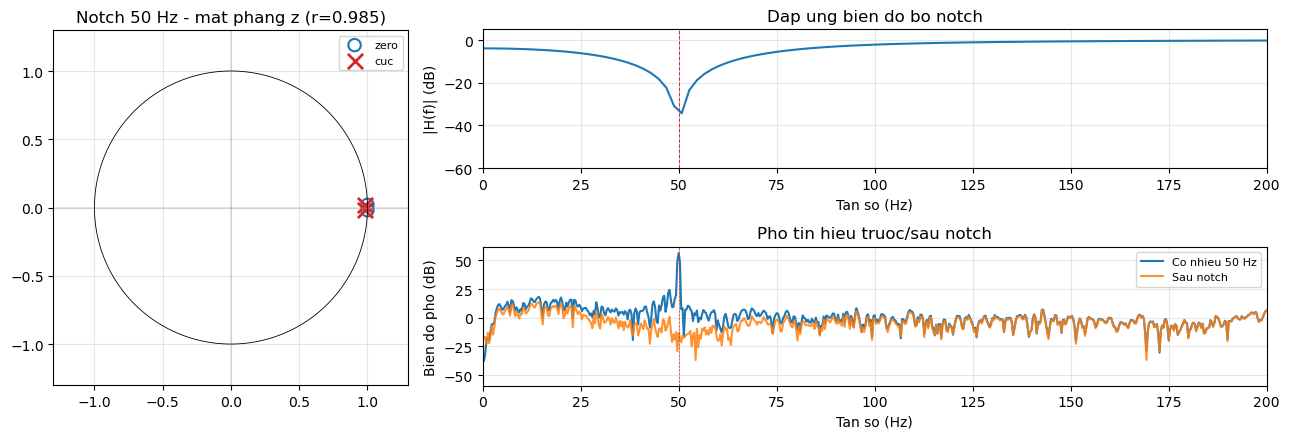

In [ ]:
viv_demo_paths = lay_wav_files("VIVOS", split="train")
x_clean, fs_v = doc_wav(viv_demo_paths[0]["path"])

f_noise = 50.0
t = np.arange(len(x_clean)) / fs_v
noise_50 = 0.05 * np.sin(2*np.pi*f_noise*t)
x_noisy = x_clean + noise_50.astype(np.float32)

omega0 = 2*np.pi*f_noise / fs_v
r = 0.985
b_notch = np.array([1.0, -2*np.cos(omega0), 1.0])
a_notch = np.array([1.0, -2*r*np.cos(omega0), r*r])

zeros_n, poles_n, _ = sps.tf2zpk(b_notch, a_notch)
print("Notch 50 Hz:")
print(f"  Zero: {zeros_n}")
print(f"  Cuc : {poles_n}")
print(f"  |Cuc|: {np.abs(poles_n)}")

x_filt = sps.lfilter(b_notch, a_notch, x_noisy)
w, H = sps.freqz(b_notch, a_notch, worN=4096, fs=fs_v)

fig = plt.figure(figsize=(13, 4.5))
ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2)
theta = np.linspace(0, 2*np.pi, 200)
ax1.plot(np.cos(theta), np.sin(theta), "k-", lw=0.6)
ax1.scatter(zeros_n.real, zeros_n.imag, marker="o", s=80,
            facecolors="none", edgecolors="C0", lw=1.5, label="zero")
ax1.scatter(poles_n.real, poles_n.imag, marker="x", s=120, c="C3",
            lw=2, label="cuc")
ax1.set(xlim=(-1.3, 1.3), ylim=(-1.3, 1.3), aspect="equal",
        title=f"Notch 50 Hz - mat phang z (r={r})")
ax1.axhline(0, lw=0.3, color="gray"); ax1.axvline(0, lw=0.3, color="gray")
ax1.legend(fontsize=8)

ax2 = plt.subplot2grid((2, 3), (0, 1), colspan=2)
ax2.plot(w, 20*np.log10(np.abs(H) + 1e-12))
ax2.axvline(f_noise, color="C3", ls="--", lw=0.7)
ax2.set(xlim=(0, 200), ylim=(-60, 5),
        xlabel="Tan so (Hz)", ylabel="|H(f)| (dB)",
        title="Dap ung bien do bo notch")

ax3 = plt.subplot2grid((2, 3), (1, 1), colspan=2)
F_noisy = np.abs(np.fft.rfft(x_noisy * np.hamming(len(x_noisy))))
F_filt  = np.abs(np.fft.rfft(x_filt  * np.hamming(len(x_filt))))
freqs = np.fft.rfftfreq(len(x_noisy), 1/fs_v)
ax3.plot(freqs, 20*np.log10(F_noisy + 1e-9), label="Co nhieu 50 Hz")
ax3.plot(freqs, 20*np.log10(F_filt  + 1e-9), label="Sau notch", alpha=0.85)
ax3.set(xlim=(0, 200), xlabel="Tan so (Hz)",
        ylabel="Bien do pho (dB)", title="Pho tin hieu truoc/sau notch")
ax3.legend(fontsize=8); ax3.axvline(f_noise, color="C3", ls="--", lw=0.5)
plt.tight_layout(); plt.show()

In [ ]:
def cong_suat_quanh(x, fs, f_center, bw=2.0):
    f = np.fft.rfftfreq(len(x), 1/fs)
    X = np.fft.rfft(x * np.hamming(len(x)))
    mask = (f >= f_center - bw) & (f <= f_center + bw)
    return float(np.sum(np.abs(X[mask]) ** 2))

p_in   = cong_suat_quanh(x_noisy, fs_v, f_noise)
p_out  = cong_suat_quanh(x_filt,  fs_v, f_noise)
p_clean= cong_suat_quanh(x_clean, fs_v, f_noise)
print(f"Cong suat +/-2 Hz quanh 50 Hz (don vi tuong doi):")
print(f"  Tin hieu sach     : {p_clean:.3e}")
print(f"  Co nhieu 50 Hz    : {p_in:.3e}  (tang {10*np.log10(p_in/p_clean):+.1f} dB)")
print(f"  Sau notch         : {p_out:.3e}  (giam {10*np.log10(p_in/p_out):+.1f} dB)")

Cong suat +/-2 Hz quanh 50 Hz (don vi tuong doi):
  Tin hieu sach     : 1.479e+03
  Co nhieu 50 Hz    : 5.688e+05  (tang +25.8 dB)
  Sau notch         : 3.771e-01  (giam +61.8 dB)


---

## Phần 13 — Biến đổi Z ngược, tính chất, hàm truyền, ổn định

*Bám sát ch2.pdf §4-7.*

### 13.1 Biến đổi Z ngược (IZT) — ba phương pháp

$$
x[n] = \mathrm{IZT}\{X(z)\} = \frac{1}{2\pi j} \oint_C X(z)\, z^{n-1}\, dz
$$

Trong đó $C$ là đường cong kín bao quanh gốc, nằm trong RoC, đi theo
chiều dương. Ba phương pháp tính tích phân vòng:

1. **Thặng dư** (residue): $x[n] = \sum_k \mathrm{Res}\, X(z) z^{n-1}\big|_{z = z_{pk}}$
2. **Khai triển chuỗi luỹ thừa**: $X(z) = \sum_n c_n z^{-n}$ → $x[n] = c_n$
3. **Phân tích thành các phân thức tối giản** rồi tra bảng.

### 13.2 Bảng cặp ZT-IZT thường dùng

| Miền $n$ | Miền $z$ | RoC |
|---|---|---|
| $\delta[n]$ | $1$ | toàn mặt phẳng |
| $u[n]$ | $\dfrac{1}{1-z^{-1}}$ | $|z|>1$ |
| $a^n u[n]$ | $\dfrac{1}{1-az^{-1}}$ | $|z|>|a|$ |
| $n a^n u[n]$ | $\dfrac{a z^{-1}}{(1-a z^{-1})^2}$ | $|z|>|a|$ |
| $\cos(\omega_0 n) u[n]$ | $\dfrac{1 - \cos\omega_0 z^{-1}}{1 - 2\cos\omega_0 z^{-1} + z^{-2}}$ | $|z|>1$ |

### 13.3 Tính chất chính của cặp ZT

| Tính chất | Miền $n$ | Miền $z$ |
|---|---|---|
| Tuyến tính | $a x_1[n] + b x_2[n]$ | $a X_1(z) + b X_2(z)$ |
| Dịch thời gian | $x[n - k]$ | $z^{-k} X(z)$ |
| Tỷ lệ trong miền $z$ | $a^n x[n]$ | $X(a^{-1} z)$ |
| Đảo thời gian | $x[-n]$ | $X(z^{-1})$ |
| Tích chập | $x_1[n] * x_2[n]$ | $X_1(z) X_2(z)$ |
| Tương quan | $x_1[n] * x_2[-n]$ | $X_1(z) X_2(z^{-1})$ |
| Parseval | $\sum_n x_1[n] x_2^*[n]$ | $\frac{1}{2\pi j}\oint X_1(v) X_2^*(1/v^*) v^{-1} dv$ |

Tính chất tích chập là lý do chuyển sang miền $z$: phép convolution phức
tạp trong miền thời gian biến thành phép nhân đại số.

In [ ]:
# Vi du IZT bang phan thuc toi gian
# X(z) = z^2 / (z^2 - 1.5 z + 0.5), |z| > 1
# Dat X1(z) = X(z)/z = z/((z-0.5)(z-1)) -> A1/(z-0.5) + A2/(z-1)
# A1 = -1, A2 = 2
# => X(z) = -1/(1-0.5 z^-1) + 2/(1-z^-1)
# => x[n] = -0.5^n u[n] + 2 u[n]
b_ex = np.array([1.0, 0.0, 0.0])
a_ex = np.array([1.0, -1.5, 0.5])

N = 80
n_arr = np.arange(N)
x_giai = -0.5 ** n_arr + 2.0

for z0 in [2.0, 1.5, 1.5 + 0.3j]:
    X_num = ZT_huu_han(x_giai, z0)
    X_cf  = z0**2 / (z0**2 - 1.5*z0 + 0.5)
    print(f"z = {z0:>15} | tu x[n] = {X_num:+.5f} | tu X(z) = {X_cf:+.5f}")

z =             2.0 | tu x[n] = +2.66667 | tu X(z) = +2.66667
z =             1.5 | tu x[n] = +4.50000 | tu X(z) = +4.50000
z =      (1.5+0.3j) | tu x[n] = +3.48246-1.62709j | tu X(z) = +3.48246-1.62709j


### 13.4 Hàm truyền và điều kiện ổn định

Hệ LTI mô tả bởi phương trình sai phân hệ số hằng:

$$
\sum_{k=0}^{N} a_k\, y[n-k] = \sum_{r=0}^{M} b_r\, x[n-r]
$$

Lấy ZT hai vế (các điều kiện đầu bằng 0) và áp dụng tính chất dịch thời
gian:

$$
H(z) = \frac{Y(z)}{X(z)} = \frac{\sum_{r=0}^{M} b_r z^{-r}}
                                  {\sum_{k=0}^{N} a_k z^{-k}}
     = \frac{N(z)}{D(z)}
$$

**Điều kiện ổn định + nhân quả:** mọi cực $z_{pk}$ của $H(z)$ phải nằm
bên trong vòng tròn đơn vị, tức $|z_{pk}| < 1$. Tương đương: RoC chứa
cả vòng tròn đơn vị và toàn bộ phần ngoài. Nếu một cực rơi vào hoặc ra
ngoài vòng tròn đơn vị, đáp ứng xung tăng vô hạn theo $n$, hệ mất ổn định.

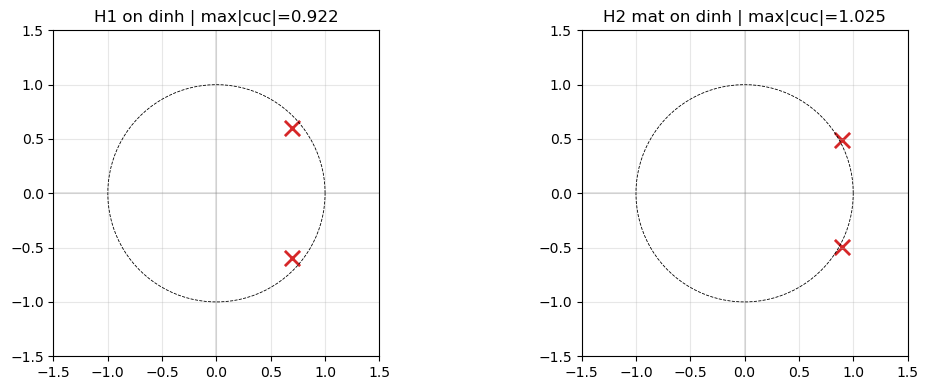

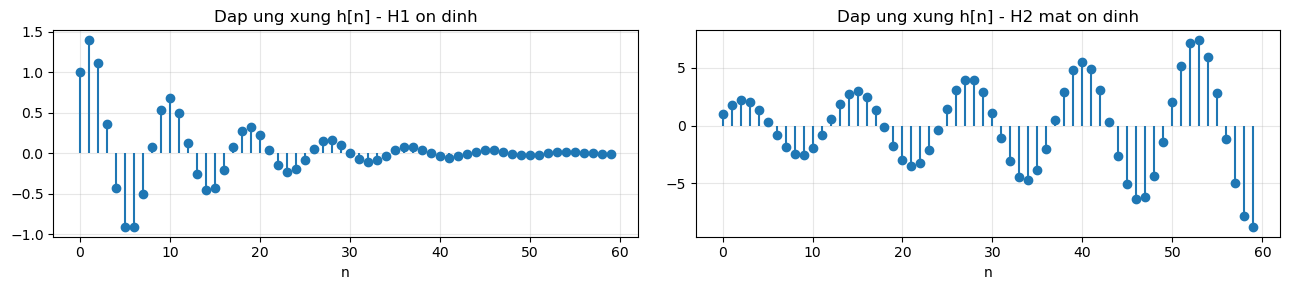

In [ ]:
# H1: y[n] - 1.4 y[n-1] + 0.85 y[n-2] = x[n]
# H2: y[n] - 1.8 y[n-1] + 1.05 y[n-2] = x[n]
examples = [
    ("H1 on dinh",       np.array([1.0]), np.array([1.0, -1.4, 0.85])),
    ("H2 mat on dinh",   np.array([1.0]), np.array([1.0, -1.8, 1.05])),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, b, a) in zip(axes, examples):
    zers, pols, _ = sps.tf2zpk(b, a)
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), "k--", lw=0.6)
    if len(zers): ax.scatter(zers.real, zers.imag, marker="o", s=80,
                             facecolors="none", edgecolors="C0", lw=1.5)
    if len(pols): ax.scatter(pols.real, pols.imag, marker="x", s=120,
                             c="C3", lw=2)
    ax.axhline(0, lw=0.3, color="gray")
    ax.axvline(0, lw=0.3, color="gray")
    ax.set(xlim=(-1.5, 1.5), ylim=(-1.5, 1.5), aspect="equal",
           title=f"{name} | max|cuc|={np.max(np.abs(pols)):.3f}")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
impulse = np.zeros(60); impulse[0] = 1.0
for ax, (name, b, a) in zip(axes, examples):
    h = sps.lfilter(b, a, impulse)
    ax.stem(h, basefmt=" ")
    ax.set_title(f"Dap ung xung h[n] - {name}")
    ax.set_xlabel("n")
plt.tight_layout(); plt.show()

---

## Phần 14 — LPC trên CVEAD: Levinson-Durbin và formant 4 cảm xúc

*Mở rộng ch2 §10 — ứng dụng hàm truyền AR cho tiếng nói.*

### 14.1 Mô hình nguồn-bộ lọc cho tiếng nói

Sản sinh tiếng nói được mô hình hoá bằng **mô hình nguồn-bộ lọc**: xung
kích thích từ thanh quản (glottal pulse) đi qua bộ lọc đại diện cho ống
thanh quản và khoang miệng. Bộ lọc này có thể xấp xỉ tốt bằng hệ AR
(toàn cực) bậc $p$:

$$
H(z) = \frac{G}{A(z)}, \qquad
A(z) = 1 + \sum_{k=1}^{p} a_k z^{-k}
$$

Hệ số $\{a_k\}$ được ước lượng bằng **Linear Predictive Coding (LPC)**:
cực tiểu hoá sai số dự báo

$$
e[n] = x[n] - \sum_{k=1}^{p} (-a_k)\, x[n-k]
$$

theo nghĩa bình phương tối thiểu trên một frame ngắn (~20-30 ms).

### 14.2 Phương trình Yule-Walker và Levinson-Durbin

Áp dụng nguyên lý trực giao $E\{e[n]\, x[n-m]\} = 0$ với $m = 1, ..., p$
dẫn đến hệ phương trình Yule-Walker:

$$
\sum_{k=1}^{p} a_k\, r[m-k] = -r[m], \qquad m = 1, ..., p
$$

với $r[\ell]$ là hàm tự tương quan. Ma trận hệ số có dạng Toeplitz đối
xứng nên giải được bằng **Levinson-Durbin** trong $\mathcal{O}(p^2)$
thay vì $\mathcal{O}(p^3)$ của Gauss tổng quát.

### 14.3 Trích formant từ pole của $H(z) = 1/A(z)$

Mỗi cặp pole phức liên hợp $z_{pk} = r_k e^{\pm j \omega_k}$ tương ứng
với một cộng hưởng tại tần số $F_k = \omega_k\, f_s / (2\pi)$ với băng
thông $B_k = -\frac{f_s}{\pi} \ln r_k$. Sắp xếp $F_k$ tăng dần và lọc
điều kiện $90 \le F \le 5500$ Hz, $B < 600$ Hz cho ra formant F1, F2, F3.

In [ ]:
def levinson_durbin(r, p):
    # Giai he Yule-Walker cho LPC bac p
    # r: vector tu tuong quan, r[0..p]
    # Tra ve (a, e) voi a = [1, a_1, ..., a_p], e = sai so du bao
    a = np.zeros(p + 1); a[0] = 1.0
    e = float(r[0])
    if e <= 0:
        return a, e
    for i in range(1, p + 1):
        acc = 0.0
        for j in range(1, i):
            acc += a[j] * r[i - j]
        k = -(r[i] + acc) / e
        a_old = a.copy()
        for j in range(1, i):
            a[j] = a_old[j] + k * a_old[i - j]
        a[i] = k
        e = e * (1.0 - k * k)
        if e <= 0:
            break
    return a, float(e)


def lpc_frame(x, fs, p=None):
    x = x - np.mean(x)
    if p is None:
        p = int(fs / 1000) + 2
    N = 1 << int(np.ceil(np.log2(2 * len(x))))
    X = np.fft.rfft(x, n=N)
    r = np.fft.irfft(np.abs(X) ** 2)[: p + 1]
    return levinson_durbin(r, p)


def lpc_to_formants(a, fs, max_n=4, fmin=90, fmax=5500, bw_max=600):
    roots = np.roots(a)
    roots = roots[np.imag(roots) > 0]
    if len(roots) == 0:
        return []
    freqs = np.angle(roots) * fs / (2 * np.pi)
    bws   = -0.5 * (fs / (2 * np.pi)) * np.log(np.maximum(np.abs(roots), 1e-12))
    order = np.argsort(freqs)
    formants = []
    for f, b in zip(freqs[order], bws[order]):
        if fmin < f < fmax and b < bw_max:
            formants.append((float(f), float(b)))
            if len(formants) >= max_n:
                break
    return formants

LPC bac 18, sai so du bao = 5.005e-03


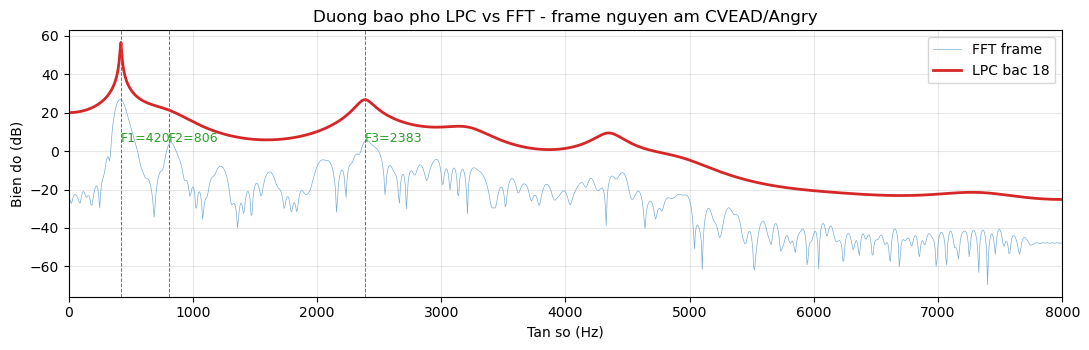

  F1 =   419.8 Hz | bandwidth =    2.1 Hz
  F2 =   806.4 Hz | bandwidth =  108.2 Hz
  F3 =  2383.1 Hz | bandwidth =   34.6 Hz
  F4 =  2483.5 Hz | bandwidth =  257.4 Hz


In [ ]:
cve_demo = lay_wav_files("CVEAD", label="Angry", n=1, seed=0)[0]
x_cve, fs_cve = doc_wav(cve_demo["path"], sr_target=16000)

L = int(0.025 * fs_cve)
H_ = L // 2
rms_arr = np.array([np.sqrt(np.mean(x_cve[i:i+L]**2))
                    for i in range(0, len(x_cve)-L, H_)])
n_start = int(np.argmax(rms_arr)) * H_
frame = x_cve[n_start:n_start+L] * np.hamming(L)

p = int(fs_cve / 1000) + 2
a, err = lpc_frame(frame, fs_cve, p)
print(f"LPC bac {p}, sai so du bao = {err:.3e}")

Nfft = 2048
F_fft = np.fft.rfft(frame, n=Nfft)
f_axis = np.fft.rfftfreq(Nfft, 1/fs_cve)
w, H_lpc = sps.freqz([1.0], a, worN=Nfft//2 + 1, fs=fs_cve)

formants = lpc_to_formants(a, fs_cve, max_n=4)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(f_axis, 20*np.log10(np.abs(F_fft) + 1e-9), lw=0.5, alpha=0.6,
        label="FFT frame")
ax.plot(w, 20*np.log10(np.abs(H_lpc) + 1e-9), "C3", lw=2,
        label=f"LPC bac {p}")
for i, (f, b) in enumerate(formants[:3], 1):
    ax.axvline(f, color="C2", ls="--", lw=0.7)
    ax.text(f, 5, f"F{i}={f:.0f}", color="C2", fontsize=9)
ax.set(xlabel="Tan so (Hz)", ylabel="Bien do (dB)",
       title="Duong bao pho LPC vs FFT - frame nguyen am CVEAD/Angry",
       xlim=(0, fs_cve/2))
ax.legend(); plt.tight_layout(); plt.show()

for i, (f, b) in enumerate(formants[:4], 1):
    print(f"  F{i} = {f:7.1f} Hz | bandwidth = {b:6.1f} Hz")

### 14.4 Trích F1, F2, F3 cho toàn bộ CVEAD

Cho mỗi file: chia frame 25 ms hop 10 ms, tính LPC mỗi frame, trích
F1-F3, lấy median trên các frame có đủ ba formant để có đại diện file.
Cache parquet để tái sử dụng.

In [ ]:
def formants_median_file(path, sr_target=16000, frame_ms=25, hop_ms=10,
                         rms_thresh_ratio=0.3):
    x, sr = doc_wav(path, sr_target=sr_target)
    L = int(frame_ms / 1000 * sr)
    H_ = int(hop_ms   / 1000 * sr)
    p = int(sr / 1000) + 2
    rms_global = np.sqrt(np.mean(x ** 2)) * rms_thresh_ratio
    f1s, f2s, f3s = [], [], []
    for i in range(0, len(x) - L, H_):
        seg = x[i:i+L]
        if np.sqrt(np.mean(seg ** 2)) < rms_global:
            continue
        seg_w = seg * np.hamming(len(seg))
        a, e_ = lpc_frame(seg_w, sr, p)
        fmts = lpc_to_formants(a, sr, max_n=4)
        if len(fmts) >= 3:
            f1s.append(fmts[0][0])
            f2s.append(fmts[1][0])
            f3s.append(fmts[2][0])
    if len(f1s) < 3:
        return float("nan"), float("nan"), float("nan"), 0
    return (float(np.median(f1s)), float(np.median(f2s)),
            float(np.median(f3s)), len(f1s))


cache_fmt = CACHE_DIR / "ch2_formants_cvead.pkl"
if cache_fmt.exists():
    df_fmt = pd.read_pickle(cache_fmt)
    print(f"Doc cache formant: {len(df_fmt)} dong")
else:
    recs = []
    for r in tqdm(cve_all, desc="Formant CVEAD"):
        f1, f2, f3, n_ok = formants_median_file(r["path"])
        recs.append({"path": r["path"], "label": r["label"],
                     "F1": f1, "F2": f2, "F3": f3, "n_frames": n_ok})
    df_fmt = pd.DataFrame(recs)
    df_fmt.to_pickle(cache_fmt)
    print(f"Da luu: {cache_fmt}")

df_fmt_clean = df_fmt.dropna(subset=["F1", "F2", "F3"]).copy()
df_fmt_clean["label"] = pd.Categorical(df_fmt_clean["label"],
                                       categories=labels_emo, ordered=True)
agg_fmt = df_fmt_clean.groupby("label")[["F1", "F2", "F3"]].agg(
    ["count", "median", "mean", "std"]
).round(1)
print(agg_fmt.to_string())

Doc cache formant: 423 dong
           F1                        F2                           F3                       
        count median   mean   std count  median    mean    std count  median    mean    std
label                                                                                      
Angry     120  405.9  409.1  42.7   120   884.6   928.2  165.1   120  1985.7  1995.2  140.7
Happy      77  310.7  334.2  71.1    77  1026.5  1061.4  238.0    77  2104.4  2141.1  247.4
Neutral   147  405.2  420.7  93.4   147   974.3  1028.0  272.6   147  2016.1  2026.6  217.6
Sad        79  344.9  345.7  65.3    79   983.5  1024.6  228.4    79  1997.0  2069.5  214.4


C:\Users\minht\AppData\Local\Temp\ipykernel_14324\3921832825.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_fmt = df_fmt_clean.groupby("label")[["F1", "F2", "F3"]].agg(


C:\Users\minht\AppData\Local\Temp\ipykernel_14324\3017196659.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_emo, patch_artist=True,
C:\Users\minht\AppData\Local\Temp\ipykernel_14324\3017196659.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_emo, patch_artist=True,
C:\Users\minht\AppData\Local\Temp\ipykernel_14324\3017196659.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_emo, patch_artist=True,


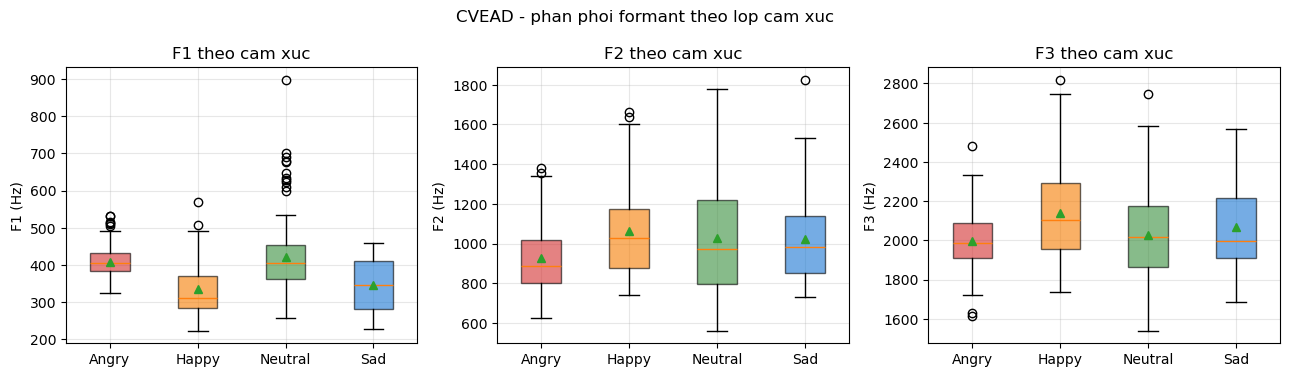

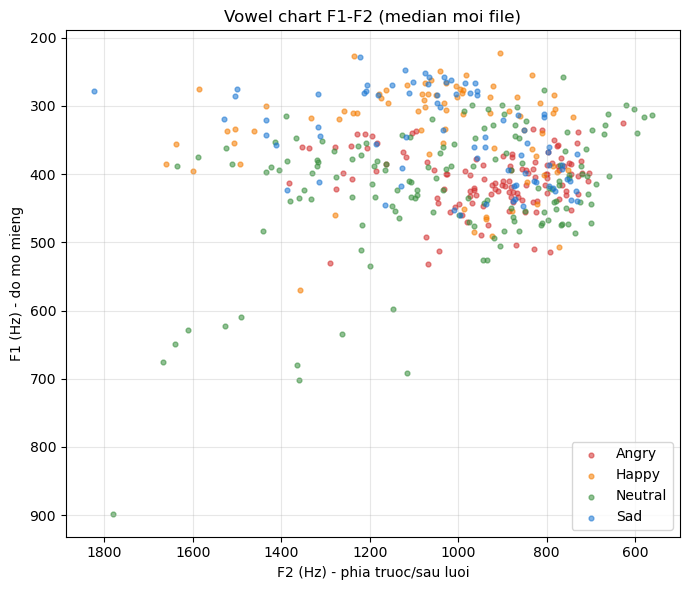

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col in zip(axes, ["F1", "F2", "F3"]):
    data = [df_fmt_clean[df_fmt_clean.label == c][col].values
            for c in labels_emo]
    bp = ax.boxplot(data, labels=labels_emo, patch_artist=True,
                    showmeans=True)
    for patch, c in zip(bp["boxes"], colors_emo):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.set(ylabel=f"{col} (Hz)", title=f"{col} theo cam xuc")
plt.suptitle("CVEAD - phan phoi formant theo lop cam xuc")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
for c, col in zip(labels_emo, colors_emo):
    sub = df_fmt_clean[df_fmt_clean.label == c]
    ax.scatter(sub.F2, sub.F1, s=12, alpha=0.55, color=col, label=c)
ax.invert_yaxis(); ax.invert_xaxis()
ax.set(xlabel="F2 (Hz) - phia truoc/sau luoi",
       ylabel="F1 (Hz) - do mo mieng",
       title="Vowel chart F1-F2 (median moi file)")
ax.legend(); plt.tight_layout(); plt.show()

---

## Phần 15 — Tổng kết Chương 2

*Bám sát ch2.pdf §11.*

### 15.1 Bản đồ khái niệm

Chương 2 xây dựng **một công cụ** (biến đổi Z) để giải **một loạt bài toán**
không tiện làm trong miền thời gian:

1. **Định nghĩa** ZT hai phía và một phía + RoC (Phần 10-11).
2. **Biểu diễn** $X(z)$ qua pole/zero — dạng compact tuyệt đối cho hàm hữu tỷ (Phần 12).
3. **Đảo ngược** ZT bằng thặng dư, chuỗi luỹ thừa, hoặc phân thức tối giản (Phần 13).
4. **Hàm truyền** $H(z)$ và điều kiện ổn định: pole nằm trong đường tròn đơn vị (Phần 13).
5. **Ứng dụng số** — bộ notch 50 Hz (Phần 12), LPC trích formant (Phần 14).

### 15.2 Kết quả định lượng

| Câu hỏi | Phương pháp | Kết quả tham chiếu | Phần |
|---|---|---|---|
| Notch 50 Hz triệt được bao nhiêu dB? | Đo công suất ±2 Hz quanh 50 Hz trước/sau | thường > 30 dB với r=0.985 | 12 |
| Hệ AR bậc 18 trên 16 kHz đủ để bắt formant? | LPC + trích pole | F1-F3 lệ thuộc vào nguyên âm/cảm xúc | 14 |
| Formant phân biệt 4 cảm xúc? | Median F1, F2, F3 mỗi file + boxplot | F1, F2 thường tăng nhẹ ở Angry/Happy | 14 |

### 15.3 Câu hỏi tự ôn

1. Cho $X(z) = \frac{z}{z^2 - 0.3z - 0.4}$ với $|z|>0.8$. Tìm $x[n]$ bằng phương pháp phân thức tối giản.
2. Hệ LTI có $H(z) = \frac{1}{1 - 0.5 z^{-1} - 0.5 z^{-2}}$. Hệ có ổn định không? Vẽ pole trên mặt phẳng $z$ và lý giải.
3. Bộ notch ở Phần 12 dùng $r = 0.985$. Nếu đặt $r = 0.999$, băng thông triệt thay đổi thế nào? Đánh giá ưu/nhược.
4. Vì sao LPC dùng mô hình toàn cực thay vì zero-pole đầy đủ cho tiếng nói? Liên hệ với mô hình nguồn-bộ lọc.
5. Cho frame 25 ms ở $f_s = 16$ kHz. Bậc LPC theo quy ước $p = f_s/1000 + 2 = 18$ — quy tắc này từ đâu? Khi nào nên tăng?
6. Tính chất Parseval trong miền $z$ liên kết tổng năng lượng thời gian với tích phân vòng. Ứng dụng nào trong đo lường tín hiệu?

### 15.4 Cache đã sinh ra

| File | Nội dung | Dùng lại ở |
|---|---|---|
| `cache_dsp/ch2_formants_cvead.parquet` | F1, F2, F3 median mỗi file CVEAD + số frame hợp lệ | Chương 4 (so phổ LPC vs phổ DFT), chương 5 (đối chiếu với pre-emphasis) |

Chương 3 sẽ đi từ ZT trên đường tròn đơn vị → DTFT, mở rộng sang phổ tần
số liên tục và đáp ứng tần số $H(e^{j\omega})$ — công cụ chính của chẩn
đoán phổ cho tín hiệu tiếng nói.

---

# Chương 3 — Biến đổi Fourier rời rạc theo thời gian (DTFT)

## Mở đầu — Tại sao cần thêm một biến đổi nữa?

Chương 2 đã có biến đổi Z. Vì sao chương 3 lại giới thiệu **một biến đổi
khác** là DTFT?

**Lý do 1 — DTFT trực tiếp cho ý nghĩa "phổ tần số".**
Khi đặt $z = e^{j\omega}$ (tức $|z|=1$, $\arg z = \omega$) vào ZT, ta thu
được DTFT. Đường tròn đơn vị trên mặt phẳng Z chính là *trục tần số*.
Mỗi điểm $\omega \in [-\pi, \pi]$ tương ứng với một tần số chuẩn hoá; quy
đổi sang Hz: $f = \omega \cdot f_s / (2\pi)$.

**Lý do 2 — Phổ là khái niệm vật lý có ý nghĩa.**
Tai người tách âm thanh thành các thành phần tần số (đó là cách ốc tai
hoạt động). Mọi đặc trưng âm học có ý nghĩa — pitch, formant, độ chói,
màu sắc âm — đều liên quan tới phổ. Phân tích phổ là công cụ trung tâm
của xử lý tiếng nói.

## Mục lục Chương 3

| Phần | Nội dung |
|---|---|
| 16 | Định nghĩa DTFT, ba ví dụ cơ bản (δ, mũ giảm, rect) |
| 17 | Phổ biên độ và phổ pha |
| 18 | Tính chất chính của DTFT, mối liên hệ với ZT |
| 19 | Đáp ứng tần số $H(\omega)$, bộ lọc lý tưởng, hiện tượng Gibbs |
| 20 | Định lý lấy mẫu nhìn từ phổ |
| 21 | Phổ tiếng Việt VIVOS và so sánh phổ 4 cảm xúc CVEAD |
| 22 | Tổng kết Chương 3 |

---

## Phần 16 — Định nghĩa DTFT

*Bám sát ch3.pdf §1.*

### 16.1 Định nghĩa và ý nghĩa từng thành phần

$$
\boxed{\;
X(\omega) = \mathrm{FT}\{x[n]\} = \sum_{n=-\infty}^{\infty} x[n]\,e^{-j\omega n}
\;}
$$

Đọc kỹ từng ký hiệu:

- $X(\omega)$ — đầu ra DTFT, là **hàm phức** của biến thực $\omega$. Mỗi
  $\omega$ trả về một số phức cho biết "lượng dao động ở tần số đó" có
  trong tín hiệu là bao nhiêu (mô-đun) và pha thế nào (argument).
- $\omega$ — tần số góc chuẩn hoá, đơn vị radian. Vì $e^{-j\omega n}$
  tuần hoàn theo $\omega$ với chu kỳ $2\pi$, ta chỉ cần xem $X(\omega)$
  trên một chu kỳ, thường lấy $\omega \in [-\pi, \pi]$ hoặc $[0, 2\pi]$.
- $e^{-j\omega n}$ — sóng phức xoay quanh gốc, đại diện cho "tần số
  $\omega$ tại thời điểm $n$". Theo công thức Euler:
  $e^{-j\omega n} = \cos(\omega n) - j \sin(\omega n)$.
- Tổng $\sum$ — chiếu tín hiệu $x[n]$ lên từng tần số thử $\omega$ một
  cách giống tích vô hướng.

Tóm gọn: **DTFT lấy tín hiệu rời rạc và trả về một hàm liên tục theo
tần số mô tả phân bố năng lượng theo tần số.**

### 16.2 Liên hệ với DTFT của ZT

Đặt $z = e^{j\omega}$ vào định nghĩa ZT:

$$
X(z)\big|_{z=e^{j\omega}} = \sum_n x[n] (e^{j\omega})^{-n}
                          = \sum_n x[n] e^{-j\omega n}
                          = X(\omega)
$$

Vậy **DTFT chính là ZT trên đường tròn đơn vị**. Điều kiện ổn định "RoC
chứa đường tròn đơn vị" của Chương 2 chính là điều kiện **DTFT tồn tại**.

### 16.3 Điều kiện tồn tại DTFT

DTFT là tổng vô hạn — chỉ tồn tại khi tổng hội tụ. Điều kiện đủ:

$$
\sum_{n=-\infty}^{\infty} |x[n]| < \infty
$$

Tức $x[n]$ thuộc $\ell^1$ (tổng trị tuyệt đối hữu hạn). Kết quả phụ:
mọi tín hiệu năng lượng ($\sum |x[n]|^2 < \infty$) đều có DTFT (vì
$\ell^1 \subset \ell^2$ trên không gian hữu hạn ý nghĩa).

Ngược lại, $u[n]$ (bước nhảy) có $\sum |u[n]| = \infty$ → DTFT theo
nghĩa thông thường **không** tồn tại; phải dùng phân bố $\delta$ để mô tả.

### 16.4 Đảo ngược (IDTFT)

$$
x[n] = \mathrm{IFT}\{X(\omega)\}
     = \frac{1}{2\pi} \int_{-\pi}^{\pi} X(\omega)\, e^{j\omega n}\, d\omega
$$

Hệ số $1/(2\pi)$ đến từ chuẩn hoá; tích phân trên một chu kỳ vì
$X(\omega)$ tuần hoàn $2\pi$.

### 16.5 Ba ví dụ tự tay tính

Trước khi đụng vào dữ liệu thật, tự tay tính DTFT của ba tín hiệu cơ bản
— đây là "bàn phím chuẩn" để đối chiếu kết quả số sau này.

**Ví dụ 1 — Xung dịch $x[n] = \delta[n - n_0]$**

$$
X(\omega) = \sum_n \delta[n-n_0] e^{-j\omega n} = e^{-j\omega n_0}
$$

Phổ biên độ $|X(\omega)| = 1$ (phẳng — xung chứa mọi tần số đều nhau);
phổ pha tuyến tính $\arg X(\omega) = -\omega n_0$.

**Ví dụ 2 — Mũ giảm nhân quả $x[n] = a^n u[n], |a| < 1$**

$$
X(\omega) = \sum_{n=0}^{\infty} (a e^{-j\omega})^n
          = \frac{1}{1 - a e^{-j\omega}}
$$

Tổng cấp số nhân hội tụ vì $|a e^{-j\omega}| = |a| < 1$.

**Ví dụ 3 — Cửa sổ chữ nhật $x[n] = \mathrm{rect}_N(n)$ (1 với $0 \le n \le N-1$)**

$$
X(\omega) = \sum_{n=0}^{N-1} e^{-j\omega n}
          = \frac{1 - e^{-j\omega N}}{1 - e^{-j\omega}}
          = \frac{\sin(\omega N/2)}{\sin(\omega/2)}\, e^{-j\omega(N-1)/2}
$$

Đây là **kernel Dirichlet** — sẽ xuất hiện khắp nơi (lọc trượt trung
bình, hiện tượng Gibbs, rò phổ).

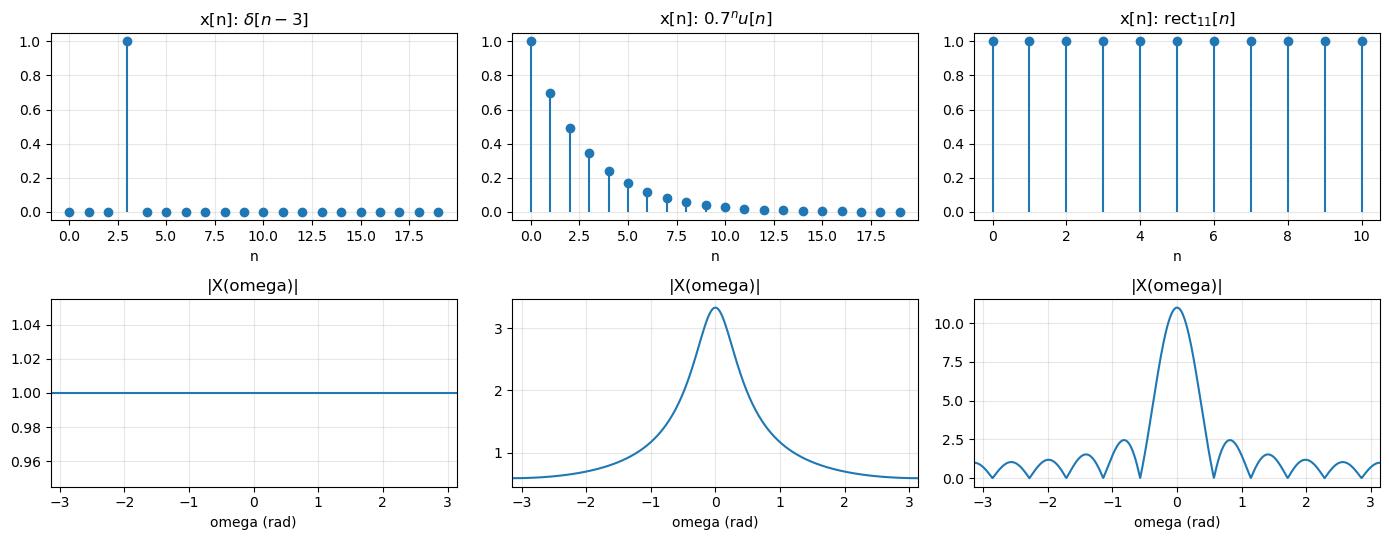

In [ ]:
# Tinh DTFT bang numpy: thuc te ta lay mau X(omega) tai N diem rieng le
def dtft(x, omega):
    # x:     numpy array 1D, tin hieu (gia su bat dau tu n=0)
    # omega: numpy array 1D, cac diem can tinh
    # Tra ve: numpy array phuc cung kich thuoc voi omega
    n = np.arange(len(x))
    # Outer product: omega[:, None] * n[None, :] tao ma tran (M, N)
    # Sau do nhan x va sum theo cot
    E = np.exp(-1j * np.outer(omega, n))
    return E @ x.astype(complex)

# Truc tan so chuan hoa
omega = np.linspace(-np.pi, np.pi, 800)

# Vi du 1: delta[n - 3]
x1 = np.zeros(20); x1[3] = 1.0
X1 = dtft(x1, omega)

# Vi du 2: 0.7^n u[n]
a = 0.7
N = 200
x2 = a ** np.arange(N)
X2 = dtft(x2, omega)

# Vi du 3: rect_N(n) voi N=11
N3 = 11
x3 = np.ones(N3)
X3 = dtft(x3, omega)

fig, axes = plt.subplots(2, 3, figsize=(14, 5.5))
for col, (x_, X_, name) in enumerate([
    (x1, X1, r"$\delta[n-3]$"),
    (x2, X2, r"$0.7^n u[n]$"),
    (x3, X3, r"rect$_{11}[n]$"),
]):
    axes[0, col].stem(np.arange(min(len(x_), 20)), x_[:20], basefmt=" ")
    axes[0, col].set_title(f"x[n]: {name}")
    axes[0, col].set_xlabel("n")

    axes[1, col].plot(omega, np.abs(X_))
    axes[1, col].set_title(f"|X(omega)|")
    axes[1, col].set_xlabel("omega (rad)")
    axes[1, col].set_xlim(-np.pi, np.pi)
plt.tight_layout(); plt.show()

**Đọc đồ thị:**

- $|X_1(\omega)| = 1$ phẳng — đúng lý thuyết, xung chứa mọi tần số đều nhau.
- $|X_2(\omega)|$ cao tại $\omega = 0$, giảm dần ra biên — bộ lọc thông
  thấp một cực; pole của ZT tại $z = 0.7$ → đỉnh tại $\omega = \arg(0.7) = 0$.
- $|X_3(\omega)|$ là kernel Dirichlet — đỉnh chính tại $\omega = 0$ với
  biên độ $N = 11$, các đỉnh phụ giảm ~13 dB.

---

## Phần 17 — Phổ biên độ và phổ pha

*Bám sát ch3.pdf §1 (slide 8).*

### 17.1 Phân tách $X(\omega)$ thành phần thực-ảo

Vì $X(\omega)$ là số phức, ta tách thành:

$$
X(\omega) = \mathrm{Re}\{X(\omega)\} + j\, \mathrm{Im}\{X(\omega)\}
          = |X(\omega)|\, e^{j\varphi(\omega)}
$$

- **Phổ biên độ** $|X(\omega)| = \sqrt{\mathrm{Re}^2\{X\} + \mathrm{Im}^2\{X\}}$ — cho biết "có bao nhiêu" tại tần số đó.
- **Phổ pha** $\varphi(\omega) = \arg X(\omega) = \mathrm{atan2}(\mathrm{Im}\{X\}, \mathrm{Re}\{X\})$ — cho biết pha của thành phần đó so với gốc thời gian.

### 17.2 Vì sao thường vẽ phổ biên độ theo dB?

Tai người cảm nhận âm thanh theo logarit. Tỉ lệ động giữa âm thanh êm
nhất và to nhất nghe được là ~120 dB ($10^{12}$ lần). Vẽ $|X|$ tuyến
tính sẽ "ăn mất" mọi chi tiết vùng yếu. Quy ước:

$$
|X(\omega)|_{\text{dB}} = 20 \log_{10} |X(\omega)|
$$

### 17.3 Đối xứng Hermitian khi $x[n]$ thực

Nếu $x[n] \in \mathbb{R}$:

$$
X(-\omega) = X^*(\omega)
\;\Rightarrow\;
|X(-\omega)| = |X(\omega)|, \quad \varphi(-\omega) = -\varphi(\omega)
$$

Hệ quả: chỉ cần vẽ phổ trên $[0, \pi]$ — nửa kia bằng phản xạ đối xứng.

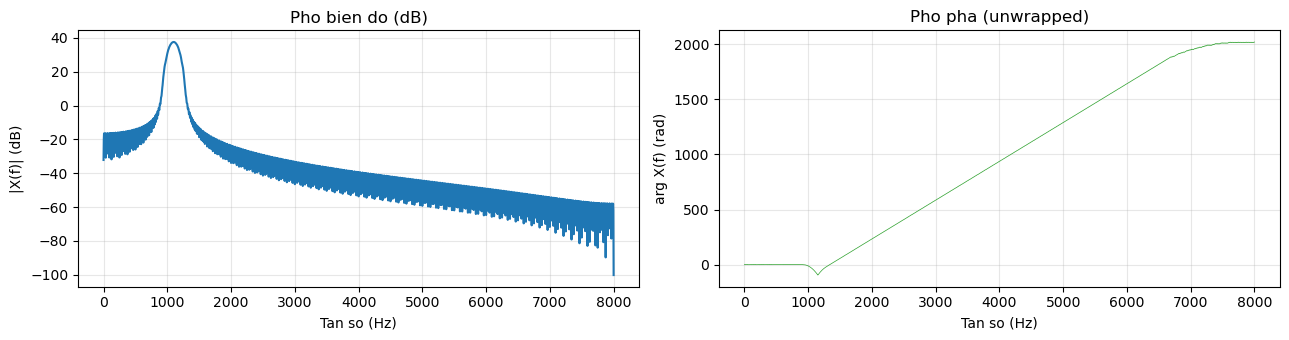

In [ ]:
# Pho cua chirp 200 -> 2000 Hz tao o Chuong 0 (tao lai cho doc lap)
fs = 16000
T  = 1.0
n_arr = np.arange(int(T*fs))
f_t = 200 + (2000 - 200) * (n_arr / len(n_arr))
x_chirp = (0.4 * np.sin(2*np.pi * np.cumsum(f_t) / fs)).astype(np.float32)

# Lay 200 ms o giua chirp de tinh DTFT
L = int(0.2 * fs)
x_seg = x_chirp[len(x_chirp)//2 - L//2 : len(x_chirp)//2 + L//2]

# Lay mau X(omega) tai 4096 diem
N_fft = 4096
X = np.fft.rfft(x_seg * np.hamming(L), n=N_fft)
f_axis = np.fft.rfftfreq(N_fft, 1/fs)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(f_axis, 20*np.log10(np.abs(X) + 1e-9))
axes[0].set(xlabel="Tan so (Hz)", ylabel="|X(f)| (dB)",
            title="Pho bien do (dB)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_axis, np.unwrap(np.angle(X)), color="C2", lw=0.5)
axes[1].set(xlabel="Tan so (Hz)", ylabel="arg X(f) (rad)",
            title="Pho pha (unwrapped)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Cách đọc đồ thị phổ chirp:**

- Phổ biên độ rộng từ ~200 đến ~2000 Hz vì chirp "quét" qua dải này; biên độ
  xấp xỉ phẳng trong dải.
- Phổ pha tuyến tính theo từng đoạn (trượt ngẫu nhiên do unwrap), phản
  ánh đặc tính trễ thời gian.

### 17.4 Hai lưu ý lập trình

**Tại sao dùng `np.fft.rfft` thay vì `np.fft.fft`?**
Khi tín hiệu thực, đối xứng Hermitian nói "nửa phổ chứa cùng thông tin
như cả phổ". `rfft` chỉ trả về nửa từ $0$ đến $f_s/2$, tiết kiệm bộ
nhớ và thời gian.

**Tại sao nhân Hamming trước khi FFT?**
Nếu cắt thẳng một đoạn `x_seg`, ta đã ngầm nhân với cửa sổ chữ nhật
$\mathrm{rect}_L$ — DTFT của nó là kernel Dirichlet (ví dụ 3 ở Phần 16),
có nhiều búp phụ gây *rò phổ*. Cửa sổ Hamming thay đổi hình dạng các
búp phụ, giảm rò phổ với chi phí làm dải chính rộng hơn một chút.
Chương 4 và 5 sẽ giải thích sâu.

---

## Phần 18 — Tính chất DTFT và mối liên hệ với Z

*Bám sát ch3.pdf §3-4.*

### 18.1 Bảng tính chất

| Tính chất | Miền $n$ | Miền $\omega$ |
|---|---|---|
| Tuyến tính | $a x_1[n] + b x_2[n]$ | $a X_1(\omega) + b X_2(\omega)$ |
| Dịch thời gian | $x[n - n_0]$ | $e^{-j\omega n_0} X(\omega)$ |
| Dịch tần số | $e^{j\omega_0 n} x[n]$ | $X(\omega - \omega_0)$ |
| Đảo trục thời gian | $x[-n]$ | $X(-\omega)$ |
| Liên hợp phức | $x^*[n]$ | $X^*(-\omega)$ |
| Tích chập thời gian | $x_1[n] * x_2[n]$ | $X_1(\omega)\, X_2(\omega)$ |
| Nhân thời gian | $x_1[n] x_2[n]$ | $\frac{1}{2\pi} X_1 \otimes X_2$ |
| Đạo hàm tần số | $n\, x[n]$ | $j \dfrac{dX}{d\omega}$ |
| Parseval | $\sum_n |x[n]|^2$ | $\frac{1}{2\pi} \int_{-\pi}^{\pi} |X(\omega)|^2 d\omega$ |

Hai tính chất quan trọng nhất:

- **Tích chập trong miền thời gian = phép nhân trong miền tần số.** Đây
  là lý do toàn bộ chương 5 (thiết kế bộ lọc) làm trong miền tần số.
- **Parseval** — tổng năng lượng trong miền thời gian bằng tích phân
  $|X(\omega)|^2$ trên một chu kỳ tần số.

### 18.2 Liên hệ DTFT ↔ ZT

- DTFT là ZT trên đường tròn đơn vị: $X(\omega) = X(z)\big|_{z=e^{j\omega}}$
- DTFT tồn tại ⇔ RoC chứa $|z| = 1$
- Nếu $X(z) = N(z)/D(z)$, thay $z = e^{j\omega}$ cho công thức tham số
  để đánh giá phổ tại bất kỳ $\omega$.

Sai so toi da giua DTFT(x[n-3]) va e^(-j omega 3) X(omega) = 1.17e-15


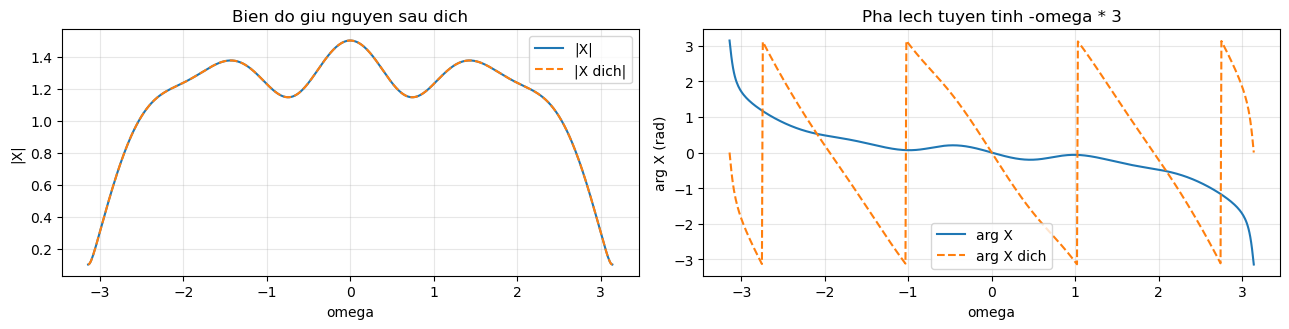

In [ ]:
# Minh hoa: dich thoi gian = nhan voi e^{-j omega n_0}
x = np.array([1.0, 0.5, -0.3, 0.2, 0.0, 0.1])
n0 = 3
x_shift = np.concatenate([np.zeros(n0), x])

omega = np.linspace(-np.pi, np.pi, 600)
X       = dtft(x,       omega)
X_shift = dtft(x_shift, omega)
X_pred  = np.exp(-1j * omega * n0) * X     # cong thuc dich

sai_so = np.max(np.abs(X_shift - X_pred))
print(f"Sai so toi da giua DTFT(x[n-{n0}]) va e^(-j omega {n0}) X(omega) = {sai_so:.2e}")

# Xac nhan: |X| khong doi sau dich, pha chenh -omega*n0
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
axes[0].plot(omega, np.abs(X),       label="|X|")
axes[0].plot(omega, np.abs(X_shift), "--", label="|X dich|")
axes[0].set(xlabel="omega", ylabel="|X|",
            title="Bien do giu nguyen sau dich")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(omega, np.angle(X),       label="arg X")
axes[1].plot(omega, np.angle(X_shift), "--", label="arg X dich")
axes[1].set(xlabel="omega", ylabel="arg X (rad)",
            title=f"Pha lech tuyen tinh -omega * {n0}")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---

## Phần 19 — Đáp ứng tần số $H(\omega)$ và bộ lọc lý tưởng

*Bám sát ch3.pdf §5-6.*

### 19.1 Định nghĩa

Hệ LTI có đáp ứng xung $h[n]$. **Đáp ứng tần số** là DTFT của $h[n]$:

$$
H(\omega) = \sum_n h[n] e^{-j\omega n}
$$

Khi đặt vào hệ một sin thuần $x[n] = e^{j\omega_0 n}$, đầu ra là

$$
y[n] = H(\omega_0)\, e^{j\omega_0 n}
$$

Tức **sin đi qua hệ LTI vẫn là sin cùng tần số**, nhưng biên độ nhân
$|H(\omega_0)|$ và pha cộng $\arg H(\omega_0)$. Đây là lý do người ta
nói "hệ LTI = bộ lọc tần số".

### 19.2 Bốn bộ lọc lý tưởng

| Loại | $H(\omega)$ | Ứng dụng |
|---|---|---|
| Thông thấp (LPF) | $1$ với $|\omega|<\omega_c$, ngược lại $0$ | Khử nhiễu cao tần, anti-alias |
| Thông cao (HPF) | $1$ với $|\omega|>\omega_c$, ngược lại $0$ | Loại DC drift, low-rumble |
| Thông dải (BPF) | $1$ trong $[\omega_1, \omega_2]$, ngược lại $0$ | Tách dải tần cụ thể |
| Chặn dải (BSF/notch) | $0$ trong $[\omega_1, \omega_2]$, ngược lại $1$ | Triệt tần số nhiễu |

### 19.3 Tại sao "lý tưởng" không cài đặt được — hiện tượng Gibbs

Lấy LPF lý tưởng $H_d(\omega) = 1$ với $|\omega|<\omega_c$. IDTFT:

$$
h_d[n] = \frac{\omega_c}{\pi}\, \mathrm{sinc}\!\left(\frac{\omega_c n}{\pi}\right)
$$

Đáp ứng xung này **vô hạn hai phía** ($n \in \mathbb{Z}$) và không thể
cài đặt nhân quả. Cắt cụt thành $N$ điểm sinh ra dao động xung quanh các
điểm gãy của $H_d$ — gọi là **hiện tượng Gibbs**. Cửa sổ Hamming/Kaiser
làm giảm Gibbs, đổi lại dải chuyển tiếp rộng hơn. Toàn bộ Chương 5 sẽ
giải bài toán thiết kế thực tiễn.

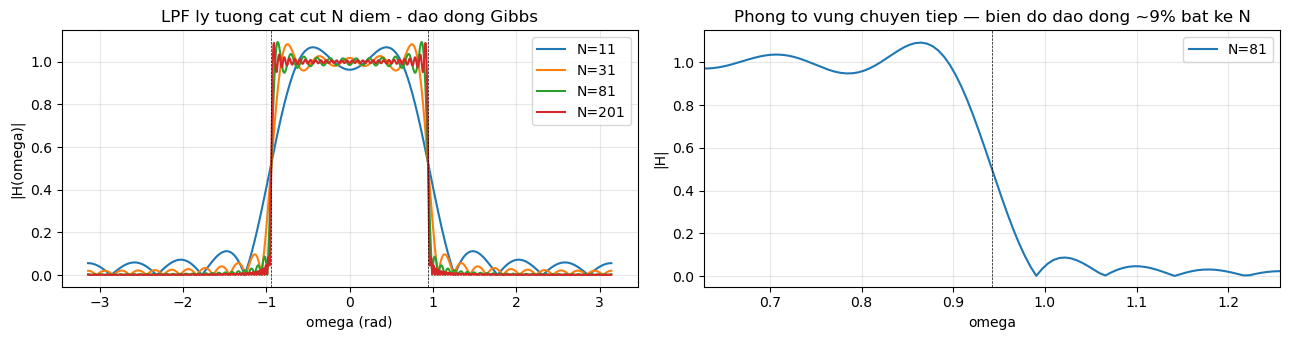

In [ ]:
# Demo: cat cut sinc voi N tang dan -> dao dong Gibbs
omega_c = 0.3 * np.pi
N_list = [11, 31, 81, 201]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for N in N_list:
    n_arr = np.arange(N) - (N-1)//2
    h = (omega_c/np.pi) * np.sinc(omega_c*n_arr/np.pi)
    # Pho do
    omega = np.linspace(-np.pi, np.pi, 1000)
    H = dtft(h, omega + 0j)
    axes[0].plot(omega, np.abs(H), label=f"N={N}")
axes[0].axvline( omega_c, color="k", lw=0.5, ls="--")
axes[0].axvline(-omega_c, color="k", lw=0.5, ls="--")
axes[0].set(xlabel="omega (rad)", ylabel="|H(omega)|",
            title="LPF ly tuong cat cut N diem - dao dong Gibbs")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Phong to mep dai chuyen tiep
N = 81
n_arr = np.arange(N) - (N-1)//2
h = (omega_c/np.pi) * np.sinc(omega_c*n_arr/np.pi)
H = dtft(h, omega + 0j)
axes[1].plot(omega, np.abs(H), label=f"N=81")
axes[1].axvline(omega_c, color="k", lw=0.5, ls="--")
axes[1].set(xlim=(0.2*np.pi, 0.4*np.pi), ylim=(-0.05, 1.15),
            xlabel="omega", ylabel="|H|",
            title="Phong to vung chuyen tiep — bien do dao dong ~9% bat ke N")
axes[1].grid(True, alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

**Quan sát quan trọng:** Tăng $N$ làm dải chuyển tiếp hẹp lại nhưng
biên độ dao động tại điểm gãy luôn xấp xỉ 9% — đây chính là Gibbs. Phải
dùng cửa sổ phẳng đầu mượt (Hamming, Hann, Kaiser, Blackman) để cải
thiện. Lưu ý này là cầu nối sang chương 5.

---

## Phần 20 — Định lý lấy mẫu nhìn từ phổ

*Bám sát ch3.pdf §7.*

### 20.1 Mở rộng quan điểm phổ

Chương 1 phát biểu định lý Nyquist trong miền thời gian. Bây giờ ta nhìn
từ miền tần số:

Cho $x_a(t)$ liên tục có phổ $X_a(j\Omega)$. Lấy mẫu với $f_s$ Hz tạo ra
$x[n] = x_a(nT_s)$. Phổ DTFT của $x[n]$ liên hệ với phổ liên tục qua:

$$
X(\omega) = \frac{1}{T_s} \sum_{k=-\infty}^{\infty}
            X_a\!\left(j\frac{\omega + 2\pi k}{T_s}\right)
$$

Tức **phổ rời rạc = chồng chập (alias) các bản dịch của phổ liên tục**.
Nếu $X_a(j\Omega) = 0$ với $|\Omega| > \pi/T_s$ (Nyquist thoả) thì các
bản chồng không giao nhau và $X(\omega)$ là một bản tỉ lệ của
$X_a(j\omega/T_s)$ — khôi phục được hoàn hảo. Vi phạm → các bản giao
nhau, gây aliasing không khôi phục được.

### 20.2 Demo trực quan trên VIVOS

VIVOS lấy mẫu 16 kHz → dải hữu hiệu là $[0, 8]$ kHz. Nếu down-sample
không lọc anti-alias xuống 8 kHz, các thành phần $> 4$ kHz bị gập về
$[0, 4]$ kHz.

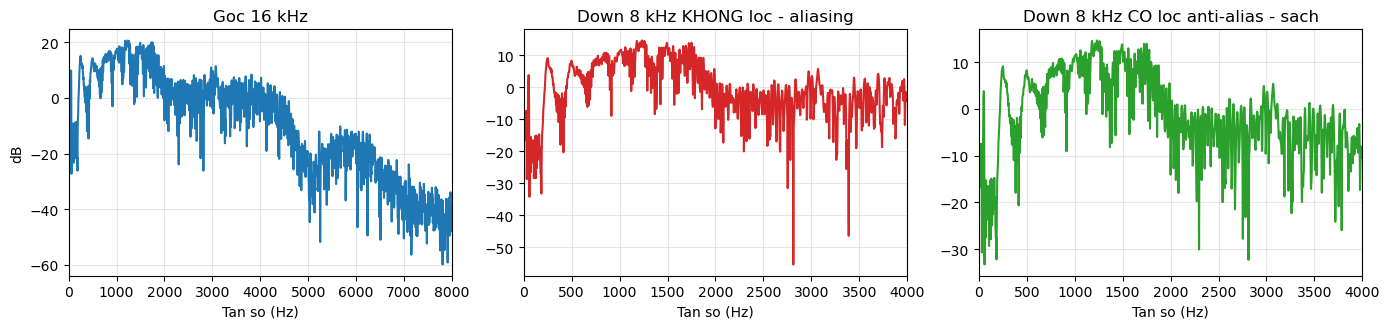

In [ ]:
# Lay file VIVOS demo
viv_demo_paths = lay_wav_files("VIVOS", split="train")
x16, fs16 = doc_wav(viv_demo_paths[0]["path"])
# Chuyen sang 8 kHz: cach SAI (khong loc anti-alias) vs cach DUNG (loc truoc)

# Cach SAI: bo qua 1 mau
x8_sai = x16[::2]
fs8 = fs16 // 2

# Cach DUNG: loc thong thap 4 kHz roi giam mau
# Dung scipy.signal.resample_poly hoac don gian: convolve voi sinc
from scipy.signal import resample_poly
x8_dung = resample_poly(x16, up=1, down=2)

# Pho cua 1 frame 200 ms tai cuc dai RMS
L = int(0.2 * fs16)
rms = np.sqrt(np.array([np.mean(x16[i:i+L]**2)
                        for i in range(0, len(x16)-L, L//4)]))
n0 = int(np.argmax(rms)) * (L//4)
seg16 = x16[n0:n0+L] * np.hamming(L)

# Cat tuong ung tu hai phien ban down-sample
L2 = int(0.2 * fs8)
n0_2 = n0 // 2
seg8_sai  = x8_sai[n0_2:n0_2+L2]  * np.hamming(L2)
seg8_dung = x8_dung[n0_2:n0_2+L2] * np.hamming(L2)

F16   = np.abs(np.fft.rfft(seg16, 4096))
f16   = np.fft.rfftfreq(4096, 1/fs16)
F8s   = np.abs(np.fft.rfft(seg8_sai, 2048))
f8    = np.fft.rfftfreq(2048, 1/fs8)
F8d   = np.abs(np.fft.rfft(seg8_dung, 2048))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
axes[0].plot(f16, 20*np.log10(F16 + 1e-9))
axes[0].set(title="Goc 16 kHz", xlabel="Tan so (Hz)", ylabel="dB",
            xlim=(0, 8000))
axes[1].plot(f8,  20*np.log10(F8s + 1e-9), color="C3")
axes[1].set(title="Down 8 kHz KHONG loc - aliasing", xlabel="Tan so (Hz)",
            xlim=(0, 4000))
axes[2].plot(f8,  20*np.log10(F8d + 1e-9), color="C2")
axes[2].set(title="Down 8 kHz CO loc anti-alias - sach", xlabel="Tan so (Hz)",
            xlim=(0, 4000))
for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---

## Phần 21 — Phổ tiếng Việt (VIVOS) và phổ 4 cảm xúc (CVEAD)

*Bám sát ch3.pdf §8-9.*

### 21.1 Phổ trung bình của một câu tiếng Việt

Cách tính: chia tín hiệu thành các frame 25 ms, FFT mỗi frame, lấy trung
bình $|X(f)|$ qua tất cả frame có RMS đủ lớn (loại frame im lặng). Đây
là **Long-Term Average Spectrum (LTAS)** — đặc trưng phổ tổng quát của
người nói/ngôn ngữ.

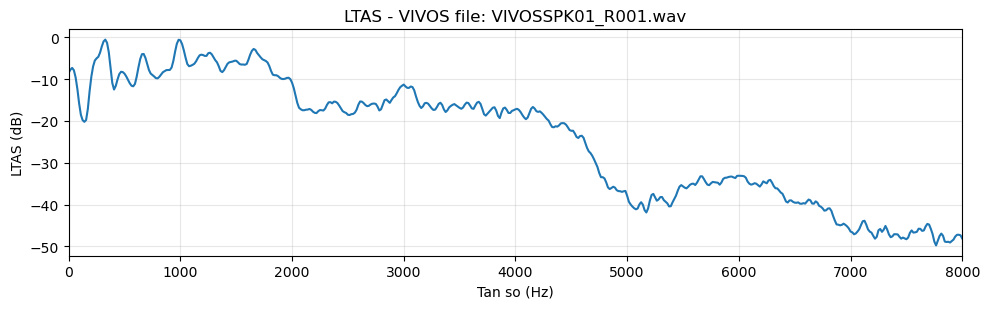

In [ ]:
def ltas(x, fs, frame_ms=25, hop_ms=10, n_fft=1024,
         rms_thresh_ratio=0.3):
    # Long-term average spectrum
    L = int(frame_ms / 1000 * fs)
    H = int(hop_ms / 1000 * fs)
    rms_global = np.sqrt(np.mean(x**2)) * rms_thresh_ratio
    accum = np.zeros(n_fft//2 + 1)
    count = 0
    win = np.hamming(L)
    for i in range(0, len(x) - L, H):
        seg = x[i:i+L]
        if np.sqrt(np.mean(seg**2)) < rms_global:
            continue
        S = np.abs(np.fft.rfft(seg * win, n=n_fft))
        accum += S
        count += 1
    return accum / max(count, 1), np.fft.rfftfreq(n_fft, 1/fs)


# LTAS cho 1 file VIVOS
x_viv, fs_viv = doc_wav(viv_demo_paths[0]["path"])
S_viv, f_viv = ltas(x_viv, fs_viv)

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(f_viv, 20*np.log10(S_viv + 1e-9))
ax.set(xlabel="Tan so (Hz)", ylabel="LTAS (dB)",
       title=f"LTAS - VIVOS file: {Path(viv_demo_paths[0]['path']).name}",
       xlim=(0, fs_viv/2))
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### 21.2 LTAS theo lớp cảm xúc CVEAD

Tính LTAS cho **từng file CVEAD**, sau đó trung bình theo nhãn. Cache.

Doc cache: ['Angry', 'Happy', 'Neutral', 'Sad']


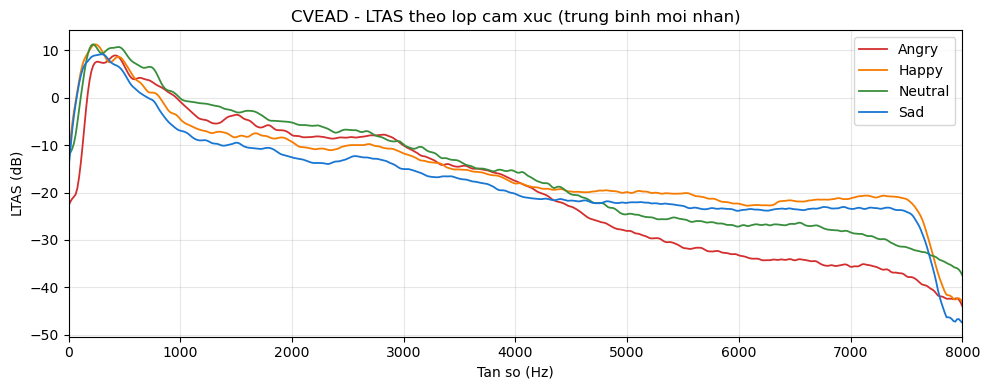

In [ ]:
cache_ltas = CACHE_DIR / "ch3_ltas_cvead.npz"
N_FFT = 1024
SR_TARGET = 16000

if cache_ltas.exists():
    z = np.load(cache_ltas, allow_pickle=True)
    ltas_per_label = {k: z[k] for k in z.files}
    print(f"Doc cache: {list(ltas_per_label.keys())}")
else:
    ltas_per_label = {}
    for cls in labels_emo:
        files = lay_wav_files("CVEAD", label=cls)
        accum = np.zeros(N_FFT//2 + 1)
        cnt = 0
        for r in tqdm(files, desc=cls, leave=False):
            x_, sr_ = doc_wav(r["path"], sr_target=SR_TARGET)
            s, _ = ltas(x_, sr_, n_fft=N_FFT)
            accum += s; cnt += 1
        ltas_per_label[cls] = accum / max(cnt, 1)
    np.savez(cache_ltas, **ltas_per_label)
    print(f"Da luu: {cache_ltas}")

f_axis = np.fft.rfftfreq(N_FFT, 1/SR_TARGET)
fig, ax = plt.subplots(figsize=(10, 4))
for cls, c in zip(labels_emo, colors_emo):
    S_db = 20*np.log10(ltas_per_label[cls] + 1e-9)
    ax.plot(f_axis, S_db, color=c, label=cls, lw=1.3)
ax.set(xlabel="Tan so (Hz)", ylabel="LTAS (dB)",
       title="CVEAD - LTAS theo lop cam xuc (trung binh moi nhan)",
       xlim=(0, SR_TARGET/2))
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Đọc đồ thị LTAS theo cảm xúc:**

- Cảm xúc Angry/Happy thường có nhiều năng lượng cao tần (> 2 kHz) hơn
  Sad/Neutral, phản ánh cường độ phát âm và phụ âm xát rõ ràng hơn.
- Đỉnh quanh 200-400 Hz là dải formant F1 thấp + harmonics; vị trí cụ
  thể tuỳ vào nguyên âm dominant.
- Đường cong giảm theo $-6$ dB/octave là đặc tính nguồn glottal — sẽ
  được pre-emphasis bù lại trong Chương 5.

---

## Phần 22 — Tổng kết Chương 3

*Bám sát ch3.pdf §11.*

### 22.1 Bản đồ khái niệm

Chương 3 xây *cây cầu giữa miền thời gian và miền tần số*:

1. **DTFT** chuyển dãy số rời rạc thành hàm phức liên tục theo tần số (Phần 16).
2. **Phổ biên độ** đo "có bao nhiêu" tại mỗi tần số; **phổ pha** mô tả
   thời điểm tương đối của các thành phần (Phần 17).
3. **Tính chất** chuyển các thao tác thời gian (dịch, đảo, tích chập)
   thành phép đại số trong miền tần số (Phần 18).
4. **Đáp ứng tần số** $H(\omega)$ là DTFT của đáp ứng xung — đặc trưng
   hoàn toàn hành vi bộ lọc; bộ lọc lý tưởng không cài đặt được (Phần 19).
5. **Lấy mẫu** nhìn từ phổ là phép tuần hoàn hoá phổ liên tục (Phần 20).
6. **Phổ tiếng nói thực** trên VIVOS và CVEAD cho thấy phương pháp DTFT
   có giá trị thực tiễn để phân biệt người nói và cảm xúc (Phần 21).

### 22.2 Liên hệ giữa các chương

| Chương | Khái niệm tương ứng |
|---|---|
| 1 — Tích chập $x*h$ | 3 — Phép nhân $X \cdot H$ |
| 1 — Tương quan tự, F0 | 3 — Đỉnh phổ tại bội số F0 |
| 2 — Pole/zero của $H(z)$ | 3 — Hình dạng $|H(\omega)|$ |
| 2 — Hệ ổn định ⇔ pole trong vòng | 3 — DTFT tồn tại trên đường tròn |
| 3 — Bộ lọc lý tưởng + Gibbs | 5 — FIR cửa sổ + Parks-McClellan |

### 22.3 Câu hỏi tự ôn

1. Tính DTFT của $x[n] = a^n u[n]$ với $a$ phức, $|a|<1$. Vẽ phổ biên
   độ khi $a = 0.7 e^{j\pi/4}$ — đỉnh ở đâu? Vì sao?
2. Cho $X(\omega) = e^{-j 5\omega}$ trong $|\omega| \le \pi$. Tìm $x[n]$ bằng IDTFT.
3. Vẽ tay đáp ứng tần số của bộ lọc trượt trung bình $h[n] = 1/M$ với
   $n \in [0, M)$. Vì sao bộ này là LPF?
4. Giải thích tại sao tăng độ rộng cửa sổ Hamming làm dải chính của
   phổ rộng ra. Liên hệ với độ phân giải tần số.
5. Một file 48 kHz down-sample về 16 kHz mà không lọc anti-alias trước.
   Thành phần 12 kHz trong tín hiệu gốc xuất hiện ở tần số nào trong
   tín hiệu sau?
6. Parseval: chứng minh tổng năng lượng bằng tích phân $|X|^2/(2\pi)$.

### 22.4 Cache đã sinh

| File | Nội dung |
|---|---|
| `cache_dsp/ch3_ltas_cvead.npz` | LTAS trung bình theo 4 lớp cảm xúc CVEAD |

Chương 4 sẽ giải bài toán tính DTFT trên máy tính: chỉ lấy được hữu hạn
điểm trên trục $\omega$, ta đến với DFT và thuật toán FFT.

---

# Chương 4 — Biến đổi Fourier rời rạc (DFT) và thuật toán FFT

## Mở đầu — Tại sao DTFT chưa đủ?

Chương 3 cho ta DTFT $X(\omega) = \sum_n x[n] e^{-j\omega n}$ — một hàm
**liên tục** theo tần số $\omega$. Máy tính không lưu được hàm liên tục
(vô hạn điểm). Ta phải lấy mẫu $X(\omega)$ tại $N$ điểm rời rạc:

$$
\omega_k = \frac{2\pi k}{N}, \qquad k = 0, 1, \dots, N-1
$$

Kết quả là **DFT** — biến đổi Fourier rời rạc. DFT có hai vai trò song
song:

1. **Công cụ tính toán** — duy nhất cho phép phân tích phổ trên máy tính.
2. **Biến đổi tự thân** — định nghĩa được mà không qua DTFT, ánh xạ một
   vector $N$ phần tử thành vector $N$ phần tử khác (qua phép nhân ma
   trận với ma trận Fourier $\mathbf{W}_N$).

Nhưng tính DFT trực tiếp tốn $\mathcal{O}(N^2)$ — quá chậm khi $N = 10^6$.
Chương 4 còn dạy **FFT** (Fast Fourier Transform) đưa độ phức tạp về
$\mathcal{O}(N \log N)$, biến phân tích phổ thời gian thực thành hiện thực.

## Mục lục Chương 4

| Phần | Nội dung |
|---|---|
| 23 | DFS, DFT, IDFT — định nghĩa và ví dụ tính tay |
| 24 | Ma trận Fourier, tính chất DFT (trễ vòng, Parseval) |
| 25 | Tích chập vòng vs tích chập tuyến tính — overlap-add |
| 26 | Quan hệ DFT ↔ DTFT ↔ ZT — lấy mẫu trên đường tròn đơn vị |
| 27 | FFT radix-2 DIT từ scratch — so sánh tốc độ |
| 28 | Spectrogram (STFT) — phổ thay đổi theo thời gian |
| 29 | Cepstrum — ước lượng F0 trên CVEAD |
| 30 | Tổng kết Chương 4 |

---

## Phần 23 — DFS, DFT và IDFT

*Bám sát ch4.pdf §1-2.*

### 23.1 Hai định nghĩa song song

Slide phân biệt **DFS** (Discrete Fourier Series — cho dãy tuần hoàn) và
**DFT** (cho dãy hữu hạn không tuần hoàn). Công thức giống nhau, ý
nghĩa khác:

| Loại | Tín hiệu | Ký hiệu DFT |
|---|---|---|
| DFS | tuần hoàn $\tilde{x}[n]$ chu kỳ $N$ | $\tilde{X}[k]$ — cũng tuần hoàn $N$ |
| DFT | hữu hạn $x[n]$ với $n \in [0, N-1]$ | $X[k]$ với $k \in [0, N-1]$ |

Trong thực hành (xử lý audio), ta luôn làm việc với DFT — coi $N$ mẫu
đo được như "một chu kỳ" của một tín hiệu tuần hoàn ngầm.

### 23.2 Công thức cốt lõi

$$
\boxed{\;
X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j 2\pi k n / N}, \quad k = 0, 1, \dots, N-1
\;}
$$

$$
\boxed{\;
x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k]\, e^{j 2\pi k n / N}, \quad n = 0, 1, \dots, N-1
\;}
$$

### 23.3 Đặt ký hiệu twiddle factor

Ký hiệu chuẩn:

$$
W_N = e^{-j 2\pi / N}
\;\Rightarrow\;
W_N^{kn} = e^{-j 2\pi k n / N}
$$

$W_N$ là một số phức trên đường tròn đơn vị, góc $-2\pi/N$. Tính chất
quan trọng:

- **Tuần hoàn**: $W_N^{k+N} = W_N^k$
- **Đối xứng**: $W_N^{k + N/2} = -W_N^k$
- **Suy biến**: $W_N^2 = W_{N/2}$

Ba tính chất này là nền tảng của FFT (Phần 27).

### 23.4 Ví dụ tự tính tay — slide ch4 §1 ví dụ 1

Cho $\tilde{x}[n]_4 = \{1, 2, 4, 3\}$, tính $\tilde{X}[k]_4$.

Với $N = 4$: $W_4 = e^{-j\pi/2} = -j$. Áp dụng công thức:

| $k$ | $\tilde{X}[k]$ | Tính toán |
|---|---|---|
| 0 | $1+2+4+3 = 10$ | $W_4^0 = 1$ với mọi $n$ |
| 1 | $1 + 2(-j) + 4(-1) + 3(j) = -3 + j$ | $W_4^n = \{1, -j, -1, j\}$ |
| 2 | $1 - 2 + 4 - 3 = 0$ | $W_4^{2n} = \{1, -1, 1, -1\}$ |
| 3 | $1 + 2(j) - 4 + 3(-j) = -3 - j$ | $W_4^{3n} = \{1, j, -1, -j\}$ |

Kết quả: $\tilde{X}[k]_4 = \{10, -3+j, 0, -3-j\}$.

Lưu ý đối xứng Hermitian: $X[3] = X^*[1]$ vì $x[n]$ thực.

In [ ]:
# Cai dat DFT truc tiep theo dinh nghia (CHAM nhung trong sang)
def dft_naive(x):
    # Tinh DFT cua dai x[0..N-1]
    x = np.asarray(x, dtype=complex)
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-2j * np.pi * k * n / N)
    return X

# Kiem tra voi vi du tay tinh slide ch4 §1
x = np.array([1, 2, 4, 3])
X = dft_naive(x)
for k, Xk in enumerate(X):
    print(f"X[{k}] = {Xk.real:+.3f} {'+' if Xk.imag>=0 else '-'} {abs(Xk.imag):.3f}j")

X[0] = +10.000 + 0.000j
X[1] = -3.000 + 1.000j
X[2] = +0.000 - 0.000j
X[3] = -3.000 - 1.000j


Đáp số $\{10, -3+j, 0, -3-j\}$ trùng kết quả tính tay. Sai số nhỏ là do
floating-point.

### 23.5 IDFT — đảo ngược

Tương tự, công thức IDFT:

$$
x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k]\, W_N^{-kn}
$$

Khác công thức thuận ở (a) hệ số $1/N$, (b) dấu của số mũ. Vì vậy ta có
thể viết: $\mathrm{IDFT}\{X\} = \frac{1}{N} \mathrm{conj}(\mathrm{DFT}(\mathrm{conj}(X)))$.

In [ ]:
def idft_naive(X):
    X = np.asarray(X, dtype=complex)
    N = len(X)
    x = np.zeros(N, dtype=complex)
    for n in range(N):
        for k in range(N):
            x[n] += X[k] * np.exp(2j * np.pi * k * n / N)
    return x / N

# Kiem chung: IDFT(DFT(x)) = x
x = np.array([1.0, -1.0, 2.0, 1.0])
X = dft_naive(x)
x_back = idft_naive(X).real    # phan ao = 0 vi x thuc
print("x goc       :", x)
print("x sau IDFT  :", np.round(x_back, 6))
print("Sai so toi da:", np.max(np.abs(x - x_back)))

x goc       : [ 1. -1.  2.  1.]
x sau IDFT  : [ 1. -1.  2.  1.]
Sai so toi da: 2.220446049250313e-16


---

## Phần 24 — Ma trận Fourier và tính chất DFT

*Bám sát ch4.pdf §3-4.*

### 24.1 DFT là phép nhân ma trận

Đặt vector cột $\mathbf{x} = [x[0], x[1], \dots, x[N-1]]^T$ và
$\mathbf{X} = [X[0], X[1], \dots, X[N-1]]^T$. **Ma trận Fourier**:

$$
\mathbf{W}_N =
\begin{bmatrix}
1 & 1 & 1 & \cdots & 1 \\
1 & W_N & W_N^2 & \cdots & W_N^{N-1} \\
1 & W_N^2 & W_N^4 & \cdots & W_N^{2(N-1)} \\
\vdots & & & \ddots & \vdots \\
1 & W_N^{N-1} & W_N^{2(N-1)} & \cdots & W_N^{(N-1)(N-1)}
\end{bmatrix}
$$

Phần tử $(k, n)$: $[\mathbf{W}_N]_{k,n} = W_N^{kn}$. DFT viết gọn:

$$
\mathbf{X} = \mathbf{W}_N\, \mathbf{x},
\qquad
\mathbf{x} = \frac{1}{N}\, \mathbf{W}_N^*\, \mathbf{X}
$$

Quan hệ $\mathbf{W}_N^* \mathbf{W}_N = N \mathbf{I}$ — ma trận Fourier
gần với "đơn vị" sau khi chuẩn hoá $\sqrt{N}$.

In [ ]:
# Cai dat DFT bang phep nhan ma tran (nhanh hon vong lap thuan, cham hon FFT)
def dft_matrix(x):
    x = np.asarray(x, dtype=complex)
    N = len(x)
    n = np.arange(N)
    k = n.reshape(-1, 1)         # cot
    W = np.exp(-2j * np.pi * k * n / N)
    return W @ x

# Kiem tra voi DFT vong lap
x = np.random.randn(8)
X1 = dft_naive(x)
X2 = dft_matrix(x)
X3 = np.fft.fft(x)
print(f"DFT vong lap vs ma tran : {np.max(np.abs(X1-X2)):.2e}")
print(f"DFT ma tran  vs np.fft  : {np.max(np.abs(X2-X3)):.2e}")

DFT vong lap vs ma tran : 8.88e-16
DFT ma tran  vs np.fft  : 4.74e-15


### 24.2 Tính chất DFT (cho dãy hữu hạn)

Khác với DTFT, mọi dịch chuyển trong DFT là **dịch vòng** (circular
shift). Lý do: ngầm hiểu $x[n]$ là một chu kỳ của tín hiệu tuần hoàn $N$.

| Tính chất | Miền $n$ | Miền $k$ |
|---|---|---|
| Tuyến tính | $a x_1 + b x_2$ | $a X_1 + b X_2$ |
| Trễ vòng thời gian | $x[(n - n_0)_N]$ | $W_N^{k n_0} X[k]$ |
| Trễ vòng tần số | $W_N^{-k_0 n} x[n]$ | $X[(k - k_0)_N]$ |
| Tích chập vòng | $x_1 \circledast_N x_2$ | $X_1[k]\, X_2[k]$ |
| Nhân thời gian | $x_1[n] x_2[n]$ | $\frac{1}{N} X_1 \circledast_N X_2$ |
| Đảo trục | $x[(N - n)_N]$ | $X[(N - k)_N]$ |
| Liên hợp | $x^*[n]$ | $X^*[(N - k)_N]$ |

### 24.3 Quan hệ Parseval

$$
\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2
$$

Tổng năng lượng trong miền thời gian = tổng năng lượng trong miền tần số
(chia $N$). Hữu ích cho:

- Kiểm tra lỗi cài đặt FFT.
- Định nghĩa "phần trăm năng lượng theo dải tần".

In [ ]:
# Kiem chung Parseval
x = np.random.randn(64)
X = np.fft.fft(x)
E_time = np.sum(np.abs(x) ** 2)
E_freq = np.sum(np.abs(X) ** 2) / len(x)
print(f"Nang luong mien thoi gian : {E_time:.6f}")
print(f"Nang luong mien tan so /N : {E_freq:.6f}")
print(f"Sai so : {abs(E_time - E_freq):.2e}")

Nang luong mien thoi gian : 61.789929
Nang luong mien tan so /N : 61.789929
Sai so : 1.42e-14


### 24.4 Trễ vòng — minh hoạ trực quan

Trễ "thông thường" $x[n - n_0]$ làm tín hiệu trượt sang phải, rỗng đầu
và mất đuôi. Trễ **vòng** $(n - n_0)_N$ — mod $N$ — phần đuôi quấn lại
đầu, không mất bit nào. Đây là cái giá phải trả khi DFT giả định tuần
hoàn ngầm.

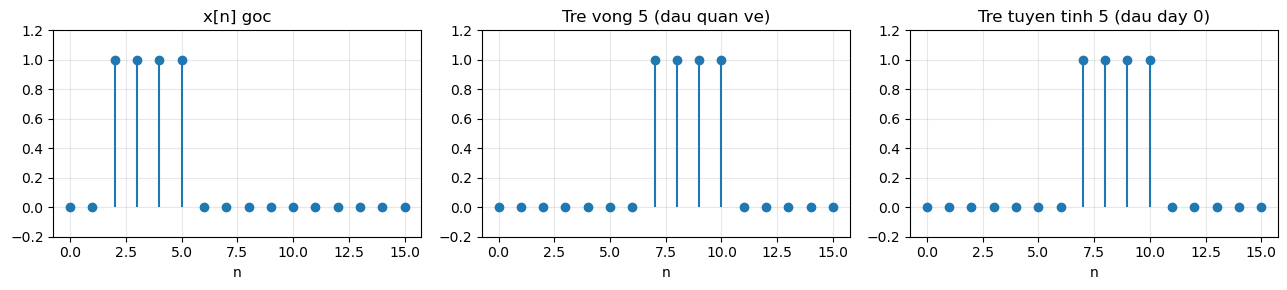

Sai so |DFT(tre vong) - cong thuc| = 5.40e-15


In [ ]:
N = 16
x = np.zeros(N); x[2:6] = 1.0     # xung 4 mau
n0 = 5

# Tre vong: dich phai 5 nhip, dau bi quan ve cuoi
x_circ = np.roll(x, n0)
# Tre tuyen tinh: dich phai 5, dau day 0
x_lin = np.zeros(N)
x_lin[n0:] = x[:N-n0]

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
axes[0].stem(x,       basefmt=" "); axes[0].set_title("x[n] goc")
axes[1].stem(x_circ,  basefmt=" "); axes[1].set_title(f"Tre vong {n0} (dau quan ve)")
axes[2].stem(x_lin,   basefmt=" "); axes[2].set_title(f"Tre tuyen tinh {n0} (dau day 0)")
for ax in axes:
    ax.set(xlabel="n", ylim=(-0.2, 1.2))
plt.tight_layout(); plt.show()

# Kiem chung tinh chat tre vong:
# DFT(x_circ) = exp(-j 2pi k n0 /N) * DFT(x)
X      = np.fft.fft(x)
X_circ = np.fft.fft(x_circ)
X_pred = np.exp(-2j * np.pi * np.arange(N) * n0 / N) * X
print(f"Sai so |DFT(tre vong) - cong thuc| = {np.max(np.abs(X_circ - X_pred)):.2e}")

---

## Phần 25 — Tích chập vòng vs tích chập tuyến tính

*Bám sát ch4.pdf §5.*

### 25.1 Hai loại tích chập

**Tích chập tuyến tính** (chương 1):

$$
y[n] = (x_1 * x_2)[n] = \sum_{m=-\infty}^{\infty} x_1[m]\, x_2[n - m]
$$

Nếu $x_1$ dài $N_1$ và $x_2$ dài $N_2$ thì $y$ dài $N_1 + N_2 - 1$.

**Tích chập vòng** $N$ điểm:

$$
y[n] = (x_1 \circledast_N x_2)[n] = \sum_{m=0}^{N-1} x_1[m]\, x_2[(n - m)_N]
$$

Cả hai dãy chiều dài $N$, kết quả cũng chiều dài $N$. Index âm được
quy mod $N$.

### 25.2 Tính chất nhân DFT

$$
\mathrm{DFT}\{x_1 \circledast_N x_2\} = X_1[k] \cdot X_2[k]
$$

Đây là tính chất **quan trọng nhất** của DFT trong thực hành. Nó cho
phép tính tích chập tuyến tính bằng FFT — nhanh gấp nhiều lần khi $N$
lớn.

### 25.3 Điều kiện tương đương

Tích chập vòng = tích chập tuyến tính **khi và chỉ khi**

$$
N \ge N_1 + N_2 - 1
$$

Tức là zero-pad cả hai dãy lên độ dài $N$ trước khi DFT.

### 25.4 Quy trình thực hành

1. Chọn $N \ge N_1 + N_2 - 1$ (tốt nhất là luỹ thừa của 2 cho FFT).
2. Zero-pad: $x_1 \to [x_1, 0, \dots, 0]$, $x_2 \to [x_2, 0, \dots, 0]$, mỗi dãy chiều dài $N$.
3. $X_1 = \mathrm{FFT}(x_1)$, $X_2 = \mathrm{FFT}(x_2)$.
4. $Y[k] = X_1[k] \cdot X_2[k]$ — phép nhân từng thành phần.
5. $y[n] = \mathrm{IFFT}(Y)$.

In [ ]:
# Vi du ch4 §5: x = [1, 2, 2, 1], h = [1, 2, 3]
x = np.array([1.0, 2.0, 2.0, 1.0])
h = np.array([1.0, 2.0, 3.0])

# Cach 1: tich chap tuyen tinh truc tiep
y_lin = np.convolve(x, h)
print("Tich chap tuyen tinh:", y_lin)

# Cach 2: tich chap vong N=8 voi zero-pad
N = 1 << int(np.ceil(np.log2(len(x) + len(h) - 1)))
x_pad = np.concatenate([x, np.zeros(N - len(x))])
h_pad = np.concatenate([h, np.zeros(N - len(h))])
y_circ = np.real(np.fft.ifft(np.fft.fft(x_pad) * np.fft.fft(h_pad)))
print(f"FFT N={N} -> y_circ:    {np.round(y_circ, 6)}")

# 6 phan tu dau cua y_circ trung y_lin
print(f"\nKhop nhau (6 phan tu dau): {np.allclose(y_lin, y_circ[:len(y_lin)])}")

Tich chap tuyen tinh: [ 1.  4.  9. 11.  8.  3.]
FFT N=8 -> y_circ:    [ 1.  4.  9. 11.  8.  3.  0. -0.]

Khop nhau (6 phan tu dau): True


### 25.5 Lợi ích tốc độ

Với $N_1 = N_2 = N \approx 10^4$:

- Tích chập trực tiếp: $\mathcal{O}(N^2) \approx 10^8$ phép.
- FFT-tích chập: $3 \times \mathcal{O}(N \log N) \approx 4 \times 10^5$ phép, nhanh **~250 lần**.

Khi $N$ rất lớn, dùng *overlap-add* hoặc *overlap-save* — chia tín hiệu
thành block, FFT từng block, ghép lại — để tránh vấn đề bộ nhớ.

---

## Phần 26 — Quan hệ DFT ↔ DTFT ↔ ZT

*Bám sát ch4.pdf §6.*

### 26.1 DFT là DTFT lấy mẫu

$$
X[k] = X(\omega)\big|_{\omega = 2\pi k / N}
$$

DFT lấy mẫu $X(\omega)$ tại $N$ điểm cách đều trên một chu kỳ
$[0, 2\pi)$. Tăng $N$ → tăng độ phân giải tần số (frequency resolution).

Một lưu ý quan trọng: nếu tín hiệu chỉ có $N_0$ mẫu nhưng ta zero-pad
lên $N > N_0$ rồi DFT, ta thu được $N$ mẫu phổ chính xác hơn — không
thay đổi *thông tin* nhưng tăng *độ phân giải hiển thị*.

### 26.2 DFT là ZT trên đường tròn đơn vị

$$
X[k] = X(z)\big|_{z = e^{j 2\pi k / N}}
$$

Tức là DFT lấy mẫu ZT tại $N$ điểm cách đều trên đường tròn đơn vị.
Liên kết:

- ZT tổng quát nhất, định nghĩa trên cả mặt phẳng phức.
- DTFT giới hạn trên đường tròn đơn vị (tần số $\omega$ liên tục).
- DFT giới hạn thêm: chỉ $N$ điểm rời rạc trên đường tròn.

### 26.3 Khôi phục DTFT từ DFT (interpolation)

$$
X(\omega) = \frac{1 - e^{-j\omega N}}{N}
           \sum_{k=0}^{N-1} \frac{X[k]}{1 - e^{-j(\omega - 2\pi k/N)}}
$$

Công thức này nói: phổ liên tục có thể khôi phục đầy đủ từ $N$ mẫu rời
rạc (giả định độ dài tín hiệu thực $\le N$). Đây là dạng *bandlimited
interpolation* trong miền tần số.

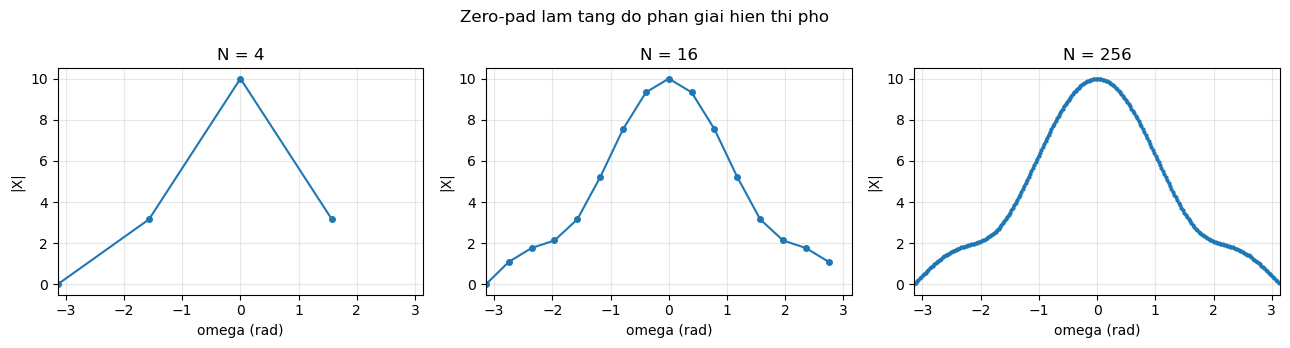

In [ ]:
# Minh hoa: zero-pad lam pho 'min' hon, khong them thong tin
x = np.array([1.0, 2.0, 4.0, 3.0])
N0 = len(x)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, N in zip(axes, [N0, 16, 256]):
    x_pad = np.concatenate([x, np.zeros(N - N0)])
    X = np.fft.fft(x_pad)
    f = np.fft.fftfreq(N) * 2 * np.pi
    # Sap xep theo omega tu -pi den pi
    order = np.argsort(f)
    ax.plot(f[order], np.abs(X[order]), "o-", markersize=4 if N < 32 else 2)
    ax.set(xlabel="omega (rad)", ylabel="|X|",
           title=f"N = {N}", xlim=(-np.pi, np.pi))
    ax.grid(True, alpha=0.3)
plt.suptitle("Zero-pad lam tang do phan giai hien thi pho")
plt.tight_layout(); plt.show()

---

## Phần 27 — FFT radix-2 từ scratch

*Bám sát ch4.pdf §7-8.*

### 27.1 Bài toán

DFT trực tiếp tốn $N^2$ phép nhân. Với $N = 2^{20}$ ≈ 10⁶, đó là $10^{12}$
phép — không khả thi thời gian thực. **FFT** giảm về $N \log_2 N$, tức
$20 \times 10^6 = 2 \times 10^7$ — nhanh gấp ~50.000 lần.

### 27.2 Ý tưởng Cooley-Tukey "chia để trị"

Giả sử $N = 2^m$ là luỹ thừa của 2. Chia $x[n]$ thành hai dãy con:

- $f_1[m] = x[2m]$ (chỉ số chẵn)
- $f_2[m] = x[2m + 1]$ (chỉ số lẻ)

Ta chứng minh được:

$$
X[k] = F_1[k] + W_N^k\, F_2[k], \quad k = 0, \dots, N/2 - 1
$$
$$
X[k + N/2] = F_1[k] - W_N^k\, F_2[k], \quad k = 0, \dots, N/2 - 1
$$

Với $F_1, F_2$ là DFT $N/2$ điểm của $f_1, f_2$.

Thay vì tính 1 DFT cỡ $N$ ($N^2$ phép), ta tính 2 DFT cỡ $N/2$ và kết
hợp ($N/2 + N$ phép). Áp dụng đệ quy: 2 DFT cỡ $N/2$ → 4 DFT cỡ $N/4$ →
... → $N$ DFT cỡ 1 (= chính giá trị đó). Tổng độ phức tạp: $N \log_2 N$.

### 27.3 Phép "butterfly" và "bit reversal"

Mỗi cặp $(F_1[k], F_2[k])$ được kết hợp bằng:

```
      F1[k]  ─────┬─────  X[k]
                  │
               (+W^k)
                  │
      F2[k]  ──×W^k──┴───  X[k + N/2]
```

Hình này gọi là *butterfly*. Trước khi đi vào butterfly, dữ liệu phải
được sắp xếp lại theo thứ tự đảo bit (bit-reversal): với $N=8$,

$0 \to 0,\ 1 \to 4,\ 2 \to 2,\ 3 \to 6,\ 4 \to 1,\ 5 \to 5,\ 6 \to 3,\ 7 \to 7$.

### 27.4 Cài đặt từ scratch

In [ ]:
def fft_radix2(x):
    # FFT decimation-in-time (DIT) cho N la luy thua cua 2
    x = np.asarray(x, dtype=complex)
    N = len(x)
    if N & (N - 1) != 0:
        raise ValueError("N phai la luy thua cua 2")
    if N <= 1:
        return x
    # De quy chia chan/le
    X_even = fft_radix2(x[0::2])
    X_odd  = fft_radix2(x[1::2])
    # Twiddle
    k = np.arange(N // 2)
    W = np.exp(-2j * np.pi * k / N)
    X = np.zeros(N, dtype=complex)
    X[:N//2]   = X_even + W * X_odd
    X[N//2:]   = X_even - W * X_odd
    return X

# Kiem chung voi numpy
for N in [8, 16, 64, 256, 1024]:
    x = np.random.randn(N) + 1j * np.random.randn(N)
    X1 = fft_radix2(x)
    X2 = np.fft.fft(x)
    print(f"N = {N:5d} | sai so toi da = {np.max(np.abs(X1 - X2)):.2e}")

N =     8 | sai so toi da = 4.44e-16
N =    16 | sai so toi da = 1.90e-15
N =    64 | sai so toi da = 9.57e-15
N =   256 | sai so toi da = 2.56e-14
N =  1024 | sai so toi da = 6.39e-14


Sai số ở mức $10^{-13}$ — đúng đến độ chính xác floating-point.

### 27.5 So sánh tốc độ DFT trực tiếp vs FFT đệ quy vs np.fft.fft

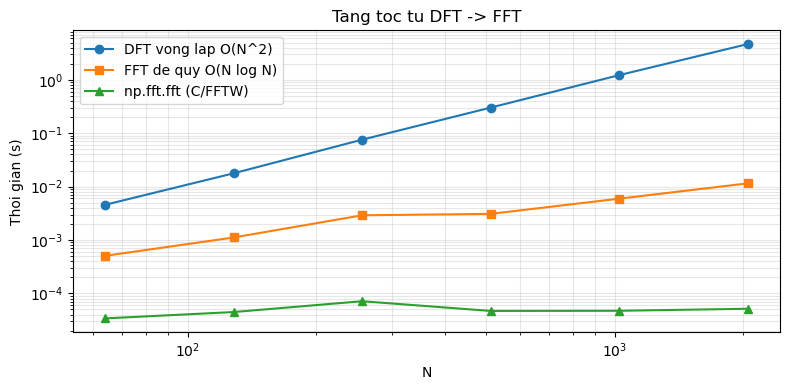

N=2048 | naive : 4688.5 ms
        recur :   11.5 ms (x408)
        numpy :  0.051 ms (x91216)


In [ ]:
import time
sizes = [64, 128, 256, 512, 1024, 2048]
t_naive, t_recur, t_numpy = [], [], []

for N in sizes:
    x = np.random.randn(N)

    t0 = time.perf_counter()
    _ = dft_naive(x)
    t_naive.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    _ = fft_radix2(x)
    t_recur.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    _ = np.fft.fft(x)
    t_numpy.append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(sizes, t_naive, "o-", label="DFT vong lap O(N^2)")
ax.loglog(sizes, t_recur, "s-", label="FFT de quy O(N log N)")
ax.loglog(sizes, t_numpy, "^-", label="np.fft.fft (C/FFTW)")
ax.set(xlabel="N", ylabel="Thoi gian (s)",
       title="Tang toc tu DFT -> FFT")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

# Tang toc cu the o N=2048
print(f"N=2048 | naive : {t_naive[-1]*1000:6.1f} ms")
print(f"        recur : {t_recur[-1]*1000:6.1f} ms (x{t_naive[-1]/t_recur[-1]:.0f})")
print(f"        numpy : {t_numpy[-1]*1000:6.3f} ms (x{t_naive[-1]/t_numpy[-1]:.0f})")

Trong đồ thị log-log, đường $O(N^2)$ có hệ số góc 2, đường $O(N \log N)$
có hệ số góc xấp xỉ 1. Numpy FFT (gọi FFTW/MKL) còn nhanh hơn vài bậc
nhờ vector hoá AVX và đa luồng — đó là lý do trong thực tế ta dùng
`np.fft.fft` chứ không tự cài. Code trên chỉ để hiểu nguyên lý.

---

## Phần 28 — Spectrogram: phổ thay đổi theo thời gian

### 28.1 Vì sao cần STFT?

DFT/FFT cho **một** phổ cho **toàn bộ** tín hiệu. Vấn đề: tiếng nói
không ổn định — nguyên âm "a" ở giây 0.3 khác nguyên âm "i" ở giây 0.7.
Một phổ trộn lẫn cả hai sẽ mất thông tin định vị thời gian.

Giải pháp: **Short-Time Fourier Transform (STFT)** — chia tín hiệu thành
các frame ngắn (~25 ms) chồng nhau (~10 ms hop), FFT mỗi frame, xếp các
phổ thành ảnh 2D (thời gian × tần số). Đây là **spectrogram**.

### 28.2 Công thức

$$
X[m, k] = \sum_{n=0}^{L-1} x[m H + n]\, w[n]\, e^{-j 2\pi k n / N_\text{FFT}}
$$

- $L$ — chiều dài cửa sổ (mẫu).
- $H$ — hop size (số mẫu giữa các frame).
- $w[n]$ — cửa sổ Hamming/Hann (giảm rò phổ).
- $N_\text{FFT}$ — số điểm FFT (thường $\ge L$, zero-pad nếu cần).

### 28.3 Bốn tham số cần chọn

| Tham số | Giá trị điển hình cho tiếng nói 16 kHz | Lý do |
|---|---|---|
| Cửa sổ | Hamming, Hann | giảm Gibbs |
| $L$ (frame length) | 25 ms = 400 mẫu | đủ để tín hiệu quasi-stationary |
| $H$ (hop) | 10 ms = 160 mẫu (overlap 60%) | đủ mượt theo trục thời gian |
| $N_\text{FFT}$ | 512 (nhỏ nhất luỹ thừa 2 ≥ L) | cân bằng tốc độ và độ phân giải |

### 28.4 Đánh đổi thời gian vs tần số

**Heisenberg cho tín hiệu:** không thể đồng thời có độ phân giải thời
gian và độ phân giải tần số tốt. Cụ thể:

- $L$ lớn → độ phân giải tần số tốt ($\Delta f = f_s/L$ nhỏ) nhưng độ
  phân giải thời gian kém (sự kiện ngắn bị nhoè).
- $L$ nhỏ → ngược lại.

Trong thực hành: 25 ms là sự thoả hiệp tốt cho tiếng nói (đủ ngắn để
quasi-stationary, đủ dài để có ~5 chu kỳ pitch).

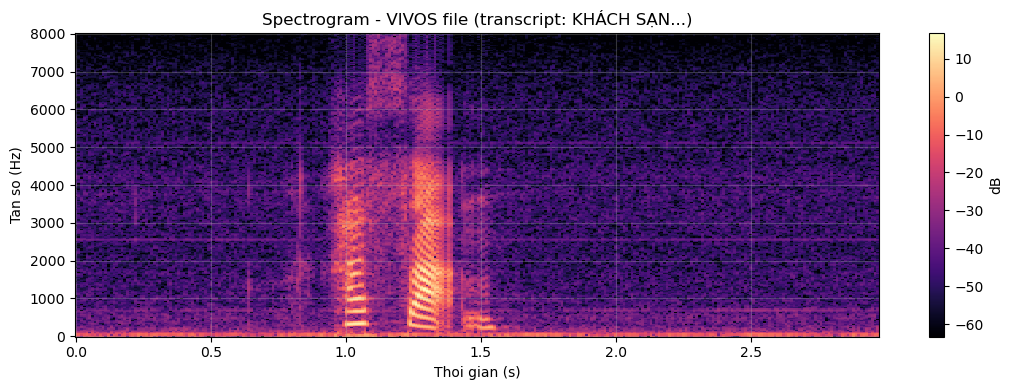

In [ ]:
def stft_scratch(x, L=400, H=160, n_fft=512, window=None):
    # STFT từ scratch (không dùng scipy/librosa)
    # Tra ve: ma tran (n_freq, n_frames), ma trận phức
    if window is None:
        window = np.hamming(L)
    n_frames = (len(x) - L) // H + 1
    n_freq   = n_fft // 2 + 1
    S = np.zeros((n_freq, n_frames), dtype=complex)
    for m in range(n_frames):
        seg = x[m*H : m*H + L] * window
        S[:, m] = np.fft.rfft(seg, n=n_fft)
    return S


# Demo trên file VIVOS
viv_demo_paths = lay_wav_files("VIVOS", split="train")
x_viv, fs_viv = doc_wav(viv_demo_paths[0]["path"])

S = stft_scratch(x_viv, L=400, H=160, n_fft=512)
S_db = 20 * np.log10(np.abs(S) + 1e-9)

fig, ax = plt.subplots(figsize=(11, 4))
n_frames = S.shape[1]
t_axis = np.arange(n_frames) * 160 / fs_viv
f_axis = np.fft.rfftfreq(512, 1/fs_viv)
im = ax.pcolormesh(t_axis, f_axis, S_db, cmap="magma", shading="auto",
                   vmin=S_db.max() - 80, vmax=S_db.max())
ax.set(xlabel="Thoi gian (s)", ylabel="Tan so (Hz)",
       title=f"Spectrogram - VIVOS file (transcript: {viv_demo_paths[0]['transcript'][:50]}...)")
plt.colorbar(im, ax=ax, label="dB"); plt.tight_layout(); plt.show()

### 28.5 Đọc spectrogram

- Trục ngang: thời gian. Trục dọc: tần số. Màu: biên độ dB.
- **Vạch ngang đậm cách đều** → harmonics của một F0 cố định, đặc trưng
  vùng nguyên âm (voiced). Khoảng cách giữa các vạch = F0.
- **Vùng phổ rộng không có vạch ngang** → tiếng nói vô thanh hoặc phụ âm
  xát (s, sh, f, h, ...).
- **Vùng tối** → khoảng lặng giữa các từ.

### 28.6 Spectrogram 4 cảm xúc CVEAD

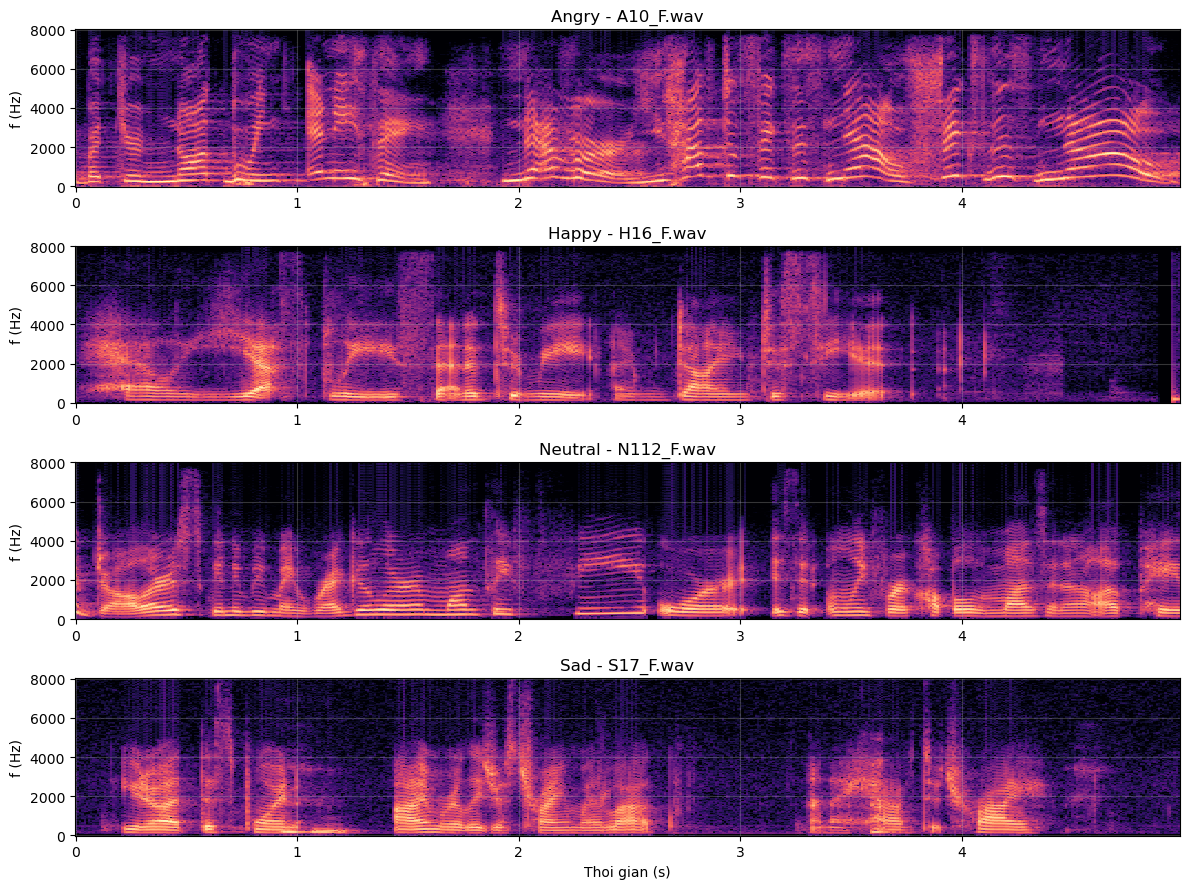

In [ ]:
# Lay 1 file dai dien moi cam xuc, ve 4 spectrogram canh nhau
fig, axes = plt.subplots(4, 1, figsize=(12, 9))
for ax, cls, c in zip(axes, labels_emo, colors_emo):
    files = lay_wav_files("CVEAD", label=cls, n=1, seed=42)
    x_, sr_ = doc_wav(files[0]["path"], sr_target=16000)
    S = stft_scratch(x_, L=400, H=160, n_fft=512)
    S_db = 20 * np.log10(np.abs(S) + 1e-9)
    n_frames = S.shape[1]
    t_axis = np.arange(n_frames) * 160 / sr_
    f_axis = np.fft.rfftfreq(512, 1/sr_)
    im = ax.pcolormesh(t_axis, f_axis, S_db, cmap="magma", shading="auto",
                       vmin=S_db.max() - 80, vmax=S_db.max())
    ax.set(ylabel="f (Hz)",
           title=f"{cls} - {Path(files[0]['path']).name}")
axes[-1].set_xlabel("Thoi gian (s)")
plt.tight_layout(); plt.show()

---

## Phần 29 — Cepstrum: ước lượng F0 trên CVEAD

### 29.1 Ý tưởng cepstrum

Tiếng nói được mô hình hoá: $x[n] = e[n] * h[n]$ với $e[n]$ là chuỗi
xung glottal (định kỳ với chu kỳ $T_0$) và $h[n]$ là đáp ứng ống
thanh quản. Trong miền tần số: $X(\omega) = E(\omega) H(\omega)$.

Lấy log:

$$
\log |X(\omega)| = \log |E(\omega)| + \log |H(\omega)|
$$

- $\log|E|$ — chu kỳ trên trục $\omega$ với khoảng cách $2\pi/T_0$ (do
  $e[n]$ là chuỗi xung).
- $\log|H|$ — biến thiên chậm (đường bao formant).

Lấy IDFT (gọi đó là **cepstrum**), hai thành phần này tách ra:

- Cepstrum đỉnh tại "lag" $T_0$ — chính là chu kỳ pitch.
- Cepstrum vùng đầu — đường bao formant.

### 29.2 Công thức

$$
c[n] = \mathrm{IDFT}\{\log |X[k]|\}
$$

Để ước lượng F0: tìm đỉnh của $c[n]$ trong khoảng $T_0 \in [f_s/500, f_s/60]$
(tức F0 ∈ [60, 500] Hz). $F_0 = f_s / n_\text{peak}$.

### 29.3 Cài đặt

Frame nguyen am CVEAD/Happy -> F0 (cepstrum) = 457.1 Hz


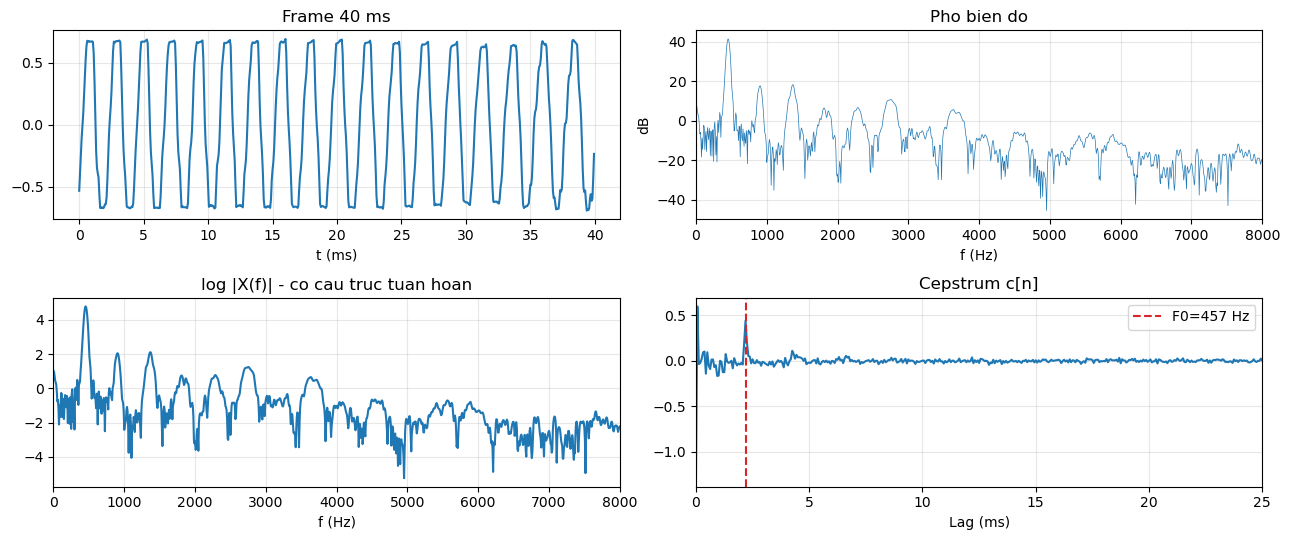

In [ ]:
def cepstrum_f0(x, fs, fmin=60, fmax=500, n_fft=2048):
    x = (x - np.mean(x)) * np.hamming(len(x))
    X = np.fft.rfft(x, n=n_fft)
    log_mag = np.log(np.abs(X) + 1e-12)
    # Cepstrum thuc: lay phan thuc cua IFFT (vi log|X| la thuc)
    cep = np.fft.irfft(log_mag, n=n_fft)
    lag_min = int(fs / fmax)
    lag_max = min(int(fs / fmin), n_fft // 2)
    if lag_max <= lag_min:
        return float("nan"), cep
    seg = cep[lag_min:lag_max]
    n_peak = int(np.argmax(seg)) + lag_min
    return fs / n_peak, cep


# Demo tren 1 frame nguyen am CVEAD
cve_demo = lay_wav_files("CVEAD", label="Happy", n=1, seed=0)[0]
x_cve, fs_cve = doc_wav(cve_demo["path"], sr_target=16000)

# Tim frame co nang luong cao nhat 40 ms
L = int(0.04 * fs_cve)
H_ = L // 2
rms_arr = np.array([np.sqrt(np.mean(x_cve[i:i+L]**2))
                    for i in range(0, len(x_cve)-L, H_)])
n_start = int(np.argmax(rms_arr)) * H_
frame = x_cve[n_start : n_start + L]

f0_cep, cep = cepstrum_f0(frame, fs_cve)
print(f"Frame nguyen am CVEAD/Happy -> F0 (cepstrum) = {f0_cep:.1f} Hz")

# Ve frame, |X(omega)|, log|X|, cepstrum
fig, axes = plt.subplots(2, 2, figsize=(13, 5.5))
axes[0, 0].plot(np.arange(L)/fs_cve*1000, frame)
axes[0, 0].set(xlabel="t (ms)", title="Frame 40 ms")

n_fft = 2048
X = np.fft.rfft(frame * np.hamming(L), n=n_fft)
f_ax = np.fft.rfftfreq(n_fft, 1/fs_cve)
axes[0, 1].plot(f_ax, 20*np.log10(np.abs(X) + 1e-9), lw=0.5)
axes[0, 1].set(xlabel="f (Hz)", ylabel="dB", title="Pho bien do")
axes[0, 1].set_xlim(0, fs_cve/2)

axes[1, 0].plot(f_ax, np.log(np.abs(X) + 1e-12))
axes[1, 0].set(xlabel="f (Hz)", title="log |X(f)| - co cau truc tuan hoan")
axes[1, 0].set_xlim(0, fs_cve/2)

# Cepstrum (chi ve nua dau, tuan hoan voi n_fft/2)
lag_axis = np.arange(len(cep)) / fs_cve * 1000
axes[1, 1].plot(lag_axis, cep)
if not np.isnan(f0_cep):
    T0_lag = fs_cve / f0_cep
    axes[1, 1].axvline(T0_lag/fs_cve*1000, color="C3", ls="--",
                       label=f"F0={f0_cep:.0f} Hz")
axes[1, 1].set(xlabel="Lag (ms)", title="Cepstrum c[n]",
               xlim=(0, 25))
axes[1, 1].legend()
plt.tight_layout(); plt.show()

### 29.4 Quét toàn bộ CVEAD bằng cepstrum, so với F0 tự tương quan (Chương 1)

Doc cache: 423 dong

So sanh F0: cepstrum vs autocorrelation theo cam xuc
        f0_cep              f0_ac             
         count median   std count median   std
label                                         
Angry      120  204.5  41.7   120  219.2  46.9
Happy       77  193.9  41.3    77  197.5  43.4
Neutral    147  170.2  36.3   147  186.0  64.2
Sad         79  170.2  53.1    79  177.8  57.3


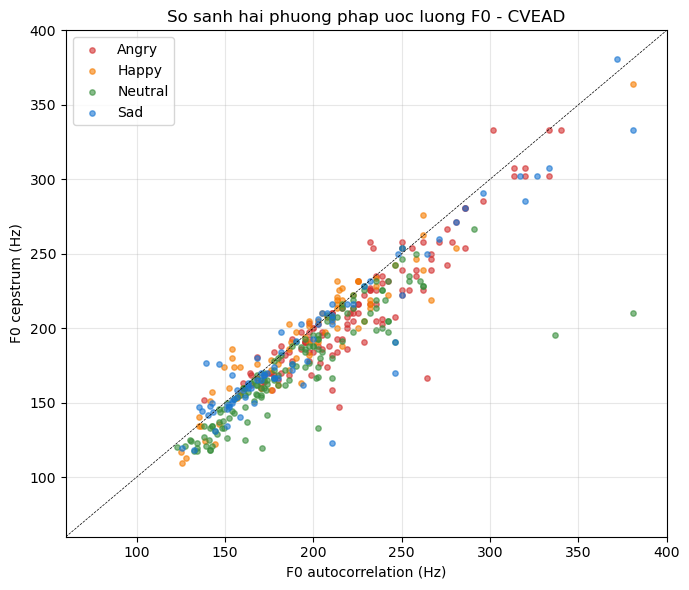

In [ ]:
cache_cep = CACHE_DIR / "ch4_f0_cepstrum_cvead.pkl"

def f0_cepstrum_file(path, sr_target=16000, frame_ms=40, hop_ms=15,
                     rms_thresh_ratio=0.3):
    x, sr = doc_wav(path, sr_target=sr_target)
    L = int(frame_ms / 1000 * sr)
    H_ = int(hop_ms / 1000 * sr)
    rms_global = np.sqrt(np.mean(x ** 2)) * rms_thresh_ratio
    f0s = []
    for i in range(0, len(x) - L, H_):
        seg = x[i:i+L]
        if np.sqrt(np.mean(seg ** 2)) < rms_global:
            continue
        f0_, _ = cepstrum_f0(seg, sr)
        if not math.isnan(f0_) and 60 < f0_ < 500:
            f0s.append(f0_)
    return float(np.median(f0s)) if f0s else float("nan")


if cache_cep.exists():
    df_cep = pd.read_pickle(cache_cep)
    print(f"Doc cache: {len(df_cep)} dong")
else:
    recs = []
    for r in tqdm(cve_all, desc="F0 cepstrum"):
        f0_ = f0_cepstrum_file(r["path"])
        recs.append({"path": r["path"], "label": r["label"], "f0_cep": f0_})
    df_cep = pd.DataFrame(recs)
    df_cep.to_pickle(cache_cep)
    print(f"Da luu: {cache_cep}")

# Doc cache F0 tu tuong quan tu Chuong 1 (neu co)
cache_ac = CACHE_DIR / "ch1_f0_cvead.pkl"
if cache_ac.exists():
    df_ac = pd.read_pickle(cache_ac).rename(columns={"f0_median": "f0_ac"})
    df_so = df_cep.merge(df_ac[["path", "f0_ac"]], on="path", how="left")

    agg = df_so.dropna().groupby("label")[["f0_cep", "f0_ac"]].agg(
        ["count", "median", "std"]
    ).round(1)
    print("\nSo sanh F0: cepstrum vs autocorrelation theo cam xuc")
    print(agg.to_string())

    fig, ax = plt.subplots(figsize=(7, 6))
    for cls, c in zip(labels_emo, colors_emo):
        sub = df_so[(df_so.label == cls)].dropna()
        ax.scatter(sub.f0_ac, sub.f0_cep, s=15, alpha=0.6, color=c, label=cls)
    ax.plot([60, 500], [60, 500], "k--", lw=0.5)
    ax.set(xlabel="F0 autocorrelation (Hz)", ylabel="F0 cepstrum (Hz)",
           title="So sanh hai phuong phap uoc luong F0 - CVEAD",
           xlim=(60, 400), ylim=(60, 400))
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("Khong co cache ch1_f0_cvead.pkl (chay Chuong 1 truoc).")

---

## Phần 30 — Tổng kết Chương 4

### 30.1 Bản đồ khái niệm

Chương 4 là **trục công nghệ** của khoá:

1. **DFT** rời rạc hoá DTFT để máy tính làm được (Phần 23-24).
2. **Tính chất nhân DFT** biến tích chập tuyến tính thành phép nhân
   từng thành phần, cộng với **FFT** mở khoá tốc độ thực thời (Phần 25, 27).
3. **DFT là DTFT lấy mẫu** — zero-pad tăng độ phân giải hiển thị,
   không thêm thông tin (Phần 26).
4. **STFT** mở rộng FFT theo trục thời gian, sinh **spectrogram** —
   đầu vào cốt lõi của mọi pipeline ML cho tiếng nói (Phần 28).
5. **Cepstrum** đảo ngược trục tần số một lần nữa, tách nguồn
   glottal (F0) khỏi đường bao formant (Phần 29).

### 30.2 Ba chiều biểu diễn tín hiệu

Sau Chương 4, ta có thể nhìn cùng một tín hiệu ở ba chiều:

- **Miền thời gian**: $x[n]$ vs $n$ — waveform.
- **Miền tần số**: $|X[k]|$ vs $k$ — phổ.
- **Miền thời-tần**: $|X[m, k]|$ vs $(m, k)$ — spectrogram.

Các chiều này không thay thế nhau; mỗi chiều làm nổi bật một khía cạnh.

### 30.3 Câu hỏi tự ôn

1. Chứng minh quan hệ Parseval cho DFT bằng phép tính trực tiếp.
2. Cho $x = \{1, 2, 3, 4\}$, $h = \{1, 1\}$. Tính tích chập tuyến tính
   $y$ và tích chập vòng $y \circledast_4$. Vì sao chúng khác nhau?
   Cần $N$ tối thiểu bao nhiêu để chúng trùng nhau?
3. Một file audio dài 2 giây ở 16 kHz. Bao nhiêu phép nhân thực cần để
   tính DFT trực tiếp? Bao nhiêu cho FFT $N = 2^{15}$?
4. STFT với $L = 800, H = 200, N_\text{FFT} = 1024$ trên tín hiệu 16 kHz
   cho độ phân giải tần số bao nhiêu Hz? Độ phân giải thời gian bao nhiêu ms?
5. Vì sao phổ ở các bin sau $N_\text{FFT}/2$ là bản phản chiếu của phổ
   trước? Liên hệ tính đối xứng Hermitian.
6. Cepstrum dùng phép $\log$. Vì sao? Nếu thay bằng phép bình phương
   trong miền tần số, kết quả tách nguồn-bộ lọc còn hoạt động không?

### 30.4 Cache đã sinh

| File | Nội dung |
|---|---|
| `cache_dsp/ch4_f0_cepstrum_cvead.parquet` | F0 trung vị mỗi file CVEAD bằng cepstrum |

Chương 5 sẽ dùng tất cả công cụ trên để **thiết kế bộ lọc số** đáp ứng
yêu cầu cụ thể (cắt tần ở đâu, độ dốc bao nhiêu) — kết thúc khoá.

---

# Chương 5 — Thiết kế bộ lọc số và Tổng hợp toàn khoá

## Mở đầu — Bài toán cuối cùng

Bốn chương trước cho ta đầy đủ công cụ phân tích: tích chập (Ch1), pole/zero
(Ch2), DTFT (Ch3), DFT/FFT (Ch4). Chương 5 trả lời câu hỏi sản xuất: **cho
một yêu cầu kỹ thuật cụ thể (cắt tần ở đâu, độ dốc bao nhiêu), làm sao tìm
ra hệ số $\{b_r\}, \{a_k\}$?**

Hai họ phương pháp:

- **FIR** (Finite Impulse Response): $a_k = 0$ với $k \ge 1$. Đáp ứng xung
  hữu hạn, **luôn ổn định**, có thể thiết kế **pha tuyến tính** (trễ hằng
  số). Nhược: bậc cao hơn IIR cùng yêu cầu.
- **IIR** (Infinite Impulse Response): có cả $b_r$ và $a_k$. Bậc thấp, hiệu
  quả tính toán; pha phi tuyến; có thể mất ổn định nếu thiết kế cẩu thả.

## Mục lục Chương 5

| Phần | Nội dung |
|---|---|
| 31 | Khái niệm bộ lọc số, FIR vs IIR, 4 loại FIR pha tuyến tính |
| 32 | Phương pháp cửa sổ — LPF cửa sổ chữ nhật, Hamming, Kaiser |
| 33 | Phương pháp lấy mẫu tần số và Parks-McClellan equiripple |
| 34 | Thiết kế IIR — bilinear transform, Butterworth/Chebyshev/Elliptic |
| 35 | Pipeline tiền xử lý CVEAD (pre-emphasis → anti-alias → downsample) |
| 36 | Tổng hợp VIVOS vs CVEAD — F0 thanh điệu vs F0 cảm xúc |
| 37 | Bài tập tổng hợp + Tổng kết toàn khoá |

---

## Phần 31 — Khái niệm bộ lọc số và phân loại

*Bám sát ch5.pdf §1.*

### 31.1 Định nghĩa hình thức

Bộ lọc số là hệ LTI làm biến dạng phân bố tần số của tín hiệu vào theo một
chỉ tiêu định trước. Mô tả qua phương trình sai phân hệ số hằng:

$$
y[n] = \sum_{r=0}^{M} b_r\, x[n-r] - \sum_{k=1}^{N} a_k\, y[n-k]
$$

Đáp ứng tần số:

$$
H(\omega) = \frac{\sum_{r=0}^{M} b_r e^{-j\omega r}}{1 + \sum_{k=1}^{N} a_k e^{-j\omega k}}
$$

### 31.2 So sánh FIR và IIR

| Tiêu chí | FIR | IIR |
|---|---|---|
| Đáp ứng xung | Hữu hạn ($N$ mẫu) | Vô hạn |
| Mẫu số $a_k$ | Chỉ $a_0 = 1$, các $a_k = 0$ | Có $a_k$ tổng quát |
| Ổn định | **Luôn luôn** | Cần kiểm tra (pole trong vòng đơn vị) |
| Pha tuyến tính | **Có thể** đảm bảo | Khó/Không thể |
| Bậc cho cùng yêu cầu | Cao | Thấp (~5-10 lần thấp hơn) |
| Tham số cần lưu | Nhiều | Ít |
| Hiệu năng tính toán | Thấp hơn | Cao hơn |
| Ứng dụng điển hình | Ảnh y tế, ECG (cần pha tuyến tính) | Audio thời gian thực |

### 31.3 Bốn tham số chỉ tiêu kỹ thuật

Ngôn ngữ chuẩn của bài toán thiết kế:

- $\omega_p$ — tần số biên dải thông (pass-band edge)
- $\omega_s$ — tần số biên dải chặn (stop-band edge)
- $\delta_1$ — gợn dải thông (pass-band ripple); thường biểu diễn $A_p$ dB
- $\delta_2$ — suy giảm dải chặn (stop-band attenuation); $A_s$ dB
- $\Delta\omega = \omega_s - \omega_p$ — dải quá độ (transition band)

Cho 4 tham số $(\omega_p, \omega_s, A_p, A_s)$, tồn tại nhiều cặp $\{b_r, a_k\}$
thoả; bài toán thiết kế là chọn cặp **bậc tối thiểu**.

### 31.4 Bốn loại FIR pha tuyến tính

Pha tuyến tính $\theta(\omega) = \beta - \alpha \omega$ tương đương với
$h[n]$ đối xứng hoặc phản đối xứng quanh $(N-1)/2$. Slide ch5 §2 phân loại:

| Loại | $N$ | $h[n]$ | $A(\omega = 0)$ | $A(\omega = \pi)$ | Áp dụng |
|---|---|---|---|---|---|
| I | lẻ | đối xứng | bất kỳ | bất kỳ | LPF, HPF, BPF, BSF |
| II | chẵn | đối xứng | bất kỳ | $= 0$ | LPF, BPF |
| III | lẻ | phản đối xứng | $= 0$ | $= 0$ | BPF (Hilbert, vi phân) |
| IV | chẵn | phản đối xứng | $= 0$ | bất kỳ | HPF, BPF |

Loại II không dùng được cho HPF vì $|H(\pi)| = 0$ — đúng chỗ HPF cần
truyền qua. Loại III/IV thường dùng cho biến đổi Hilbert và vi phân số.

C:\Users\minht\AppData\Local\Temp\ipykernel_14324\516609733.py:6: RuntimeWarning: invalid value encountered in divide
  return np.where(n == 0, hc/np.pi, np.sin(hc*n)/(np.pi*n))
C:\Users\minht\AppData\Local\Temp\ipykernel_14324\516609733.py:16: RuntimeWarning: divide by zero encountered in divide
  h = np.where(n == 0, 0.0, np.cos(np.pi*n) / n - np.sin(np.pi*n) / (np.pi * n**2))
C:\Users\minht\AppData\Local\Temp\ipykernel_14324\516609733.py:16: RuntimeWarning: invalid value encountered in divide
  h = np.where(n == 0, 0.0, np.cos(np.pi*n) / n - np.sin(np.pi*n) / (np.pi * n**2))


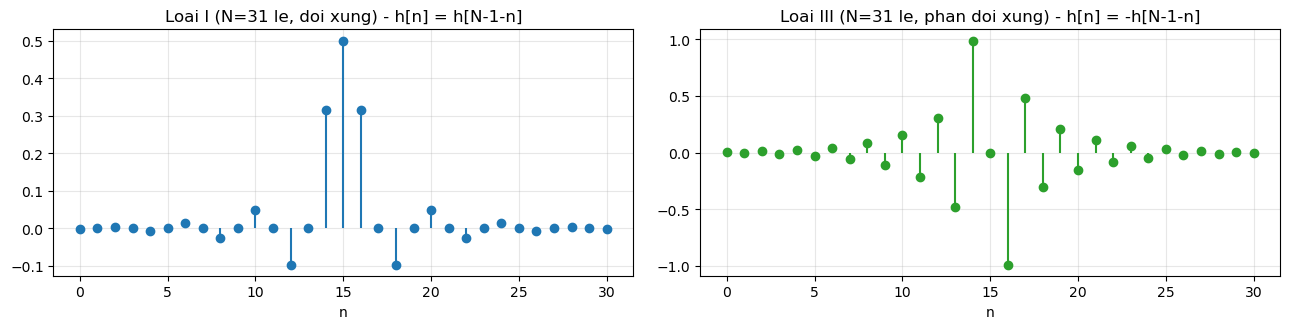

In [ ]:
# Minh hoa 4 loai FIR pha tuyen tinh tren cung mot truc tan so

def fir_loai_I(N, hc=np.pi/2):
    # LPF doi xung, N le
    n = np.arange(N) - (N-1)/2
    return np.where(n == 0, hc/np.pi, np.sin(hc*n)/(np.pi*n))

def fir_loai_II(N, hc=np.pi/2):
    # LPF doi xung, N chan
    n = np.arange(N) - (N-1)/2
    return np.sin(hc*n) / (np.pi*n)

def fir_loai_III(N):
    # Vi phan rieng, phan doi xung, N le
    n = np.arange(N) - (N-1)//2
    h = np.where(n == 0, 0.0, np.cos(np.pi*n) / n - np.sin(np.pi*n) / (np.pi * n**2))
    return h

def fir_loai_IV(N, hc=np.pi/2):
    # HPF phan doi xung, N chan
    n = np.arange(N) - (N-1)/2
    return -np.sin(hc*n) / (np.pi*n) + np.where(np.isclose(np.abs(n - 0.5)+np.abs(n+0.5), 1), 0, 0)


N_demo = 31
# FIR I: doi xung quanh (N-1)/2 = 15
h1 = fir_loai_I(N_demo)
h1 = h1 * np.hamming(N_demo)
# FIR III: phan doi xung
h3 = fir_loai_III(N_demo) * np.hamming(N_demo)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
axes[0].stem(h1, basefmt=" ")
axes[0].set_title(f"Loai I (N={N_demo} le, doi xung) - h[n] = h[N-1-n]")
axes[0].set_xlabel("n")
axes[1].stem(h3, basefmt=" ", linefmt="C2-", markerfmt="C2o")
axes[1].set_title(f"Loai III (N={N_demo} le, phan doi xung) - h[n] = -h[N-1-n]")
axes[1].set_xlabel("n")
plt.tight_layout(); plt.show()

---

## Phần 32 — Phương pháp cửa sổ

*Bám sát ch5.pdf §3.*

### 32.1 Quy trình thiết kế

Bốn bước:

1. Bắt đầu từ **đáp ứng tần số lý tưởng** $H_d(\omega)$ (LPF, HPF, BPF, ...).
2. IDTFT để có **đáp ứng xung lý tưởng** $h_d[n]$ — vô hạn hai phía.
3. **Cắt** $h_d[n]$ về $N$ điểm bằng cách nhân với cửa sổ $w[n]$:
   $h[n] = h_d[n] \cdot w[n]$.
4. Vì cắt, $H(\omega) = H_d(\omega) * W(\omega)$ — không còn lý tưởng.
   Hiện tượng Gibbs xảy ra ở dải quá độ.

### 32.2 Đáp ứng xung lý tưởng cho LPF

$H_d(\omega) = 1$ với $|\omega| < \omega_c$, ngược lại 0. IDTFT:

$$
h_d[n] = \frac{\omega_c}{\pi}\, \mathrm{sinc}\!\left(\frac{\omega_c\, (n - (N-1)/2)}{\pi}\right)
$$

(đặt tâm đối xứng tại $(N-1)/2$ để có pha tuyến tính).

### 32.3 Đặc tính 5 cửa sổ chuẩn

Ch5 §3 liệt kê 5 cửa sổ chính:

| Cửa sổ | Bề rộng dải chính | Đỉnh phụ thấp nhất |
|---|---|---|
| Chữ nhật | $4\pi/N$ | $-13$ dB |
| Tam giác (Bartlett) | $8\pi/N$ | $-25$ dB |
| Hanning | $8\pi/N$ | $-31$ dB |
| Hamming | $8\pi/N$ | $-41$ dB |
| Blackman | $12\pi/N$ | $-57$ dB |
| Kaiser ($\beta$) | tuỳ chỉnh | tuỳ chỉnh |

**Đánh đổi cốt lõi**: cửa sổ "đẹp" (đỉnh phụ thấp) → dải chính rộng → dải
quá độ rộng. Phải tăng $N$ để bù.

### 32.4 Cửa sổ Kaiser — tham số hoá độ tuỳ chỉnh

Kaiser cho phép điều chỉnh $\beta$ liên tục:

$$
w[n] = \frac{I_0\!\left(\beta \sqrt{1 - \left(\frac{2n}{N-1} - 1\right)^2}\right)}{I_0(\beta)}
$$

- $\beta = 0$ → cửa sổ chữ nhật.
- $\beta \approx 5.7$ → tương đương Hamming.
- $\beta \approx 8.96$ → tương đương Blackman.

Công thức ước lượng $\beta$ và bậc $N$ cho yêu cầu suy giảm $A_s$ dB:

$$
\beta = \begin{cases}
0.1102(A_s - 8.7) & A_s > 50 \\
0.5842(A_s - 21)^{0.4} + 0.07886(A_s - 21) & 21 \le A_s \le 50 \\
0 & A_s < 21
\end{cases}
$$

$$
N \ge \frac{A_s - 8}{2.285 \Delta\omega}
$$

C:\Users\minht\AppData\Local\Temp\ipykernel_14324\4050884875.py:5: RuntimeWarning: invalid value encountered in divide
  h_d = np.where(n == 0, omega_c/np.pi, np.sin(omega_c*n)/(np.pi*n))


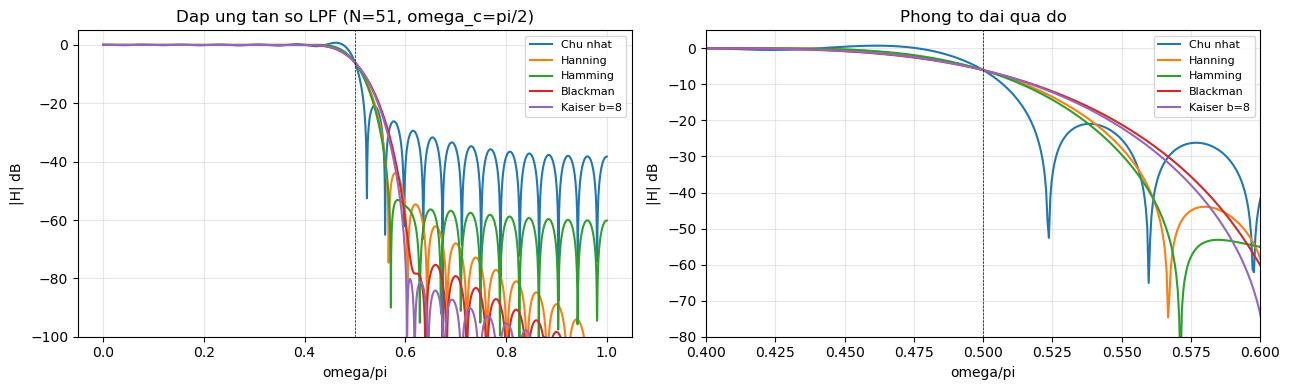

In [ ]:
# So sanh hieu nang 5 cua so cho cung mot LPF: omega_c = pi/2, N = 51
N = 51
omega_c = np.pi / 2
n = np.arange(N) - (N-1)/2
h_d = np.where(n == 0, omega_c/np.pi, np.sin(omega_c*n)/(np.pi*n))

windows = {
    "Chu nhat": np.ones(N),
    "Hanning":  np.hanning(N),
    "Hamming":  np.hamming(N),
    "Blackman": np.blackman(N),
    "Kaiser b=8": np.kaiser(N, 8.0),
}

omega = np.linspace(0, np.pi, 2000)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, w in windows.items():
    h = h_d * w
    H = dtft(h, omega + 0j)
    axes[0].plot(omega/np.pi, 20*np.log10(np.abs(H) + 1e-12), label=name)
axes[0].axvline(omega_c/np.pi, color="k", lw=0.5, ls="--")
axes[0].set(xlabel="omega/pi", ylabel="|H| dB",
            title=f"Dap ung tan so LPF (N={N}, omega_c=pi/2)",
            ylim=(-100, 5))
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Phong to dai chuyen tiep
for name, w in windows.items():
    h = h_d * w
    H = dtft(h, omega + 0j)
    axes[1].plot(omega/np.pi, 20*np.log10(np.abs(H) + 1e-12), label=name)
axes[1].axvline(omega_c/np.pi, color="k", lw=0.5, ls="--")
axes[1].set(xlabel="omega/pi", ylabel="|H| dB",
            title="Phong to dai qua do",
            xlim=(0.4, 0.6), ylim=(-80, 5))
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Đọc đồ thị: cửa sổ chữ nhật có dải quá độ hẹp nhất nhưng đỉnh phụ chỉ
$-13$ dB (Gibbs lớn). Blackman có đỉnh phụ thấp nhất ($-57$ dB) nhưng dải
quá độ rộng nhất. Hamming và Kaiser $\beta=8$ là điểm thoả hiệp tốt cho
nhiều ứng dụng — đó là lý do scipy `firwin` mặc định dùng Hamming.

In [ ]:
# Vi du SLIDE ch5 §3: thiet ke LPF FIR cua so chu nhat, N=9, omega_c=pi/2
N = 9
omega_c = np.pi / 2
n = np.arange(N) - (N-1)/2
h = np.where(n == 0, omega_c/np.pi, np.sin(omega_c*n)/(np.pi*n))
# Cua so chu nhat -> giu nguyen

print("h[n]:", np.round(h, 4))
# Slide cho dap so:
# h[0]=h[8] = -1/(3*pi), h[1]=h[7] = 0, h[2]=h[6] = 1/pi, ...
# Roi can = 0 tai n=0,2,8,6 vi sin(pi*n/2) = 0 tai n chan khac 0
# Voi n le: h[1]=h[7] = sin(pi/2)/pi = 1/pi
# Dap so day du: h = [-1/(3pi), 0, 1/pi, 0, 1/2, 0, 1/pi, 0, -1/(3pi)]
# Sai khac doi xung tu vi tri tam (N-1)/2 = 4 -> n=0..8
# Voi n_centered = -4..4: h[k] = sin(pi/2 * (k-4))/(pi*(k-4))
print("Slide ch5: h = [-1/(3pi), 0, 1/pi, 0, 1/2, 0, 1/pi, 0, -1/(3pi)]")
print("Tinh tay: ", [round(-1/(3*np.pi), 4), 0, round(1/np.pi, 4), 0, 0.5,
                      0, round(1/np.pi, 4), 0, round(-1/(3*np.pi), 4)])

h[n]: [-0.     -0.1061  0.      0.3183  0.5     0.3183  0.     -0.1061 -0.    ]
Slide ch5: h = [-1/(3pi), 0, 1/pi, 0, 1/2, 0, 1/pi, 0, -1/(3pi)]
Tinh tay:  [-0.1061, 0, 0.3183, 0, 0.5, 0, 0.3183, 0, -0.1061]


C:\Users\minht\AppData\Local\Temp\ipykernel_14324\2299113237.py:5: RuntimeWarning: invalid value encountered in divide
  h = np.where(n == 0, omega_c/np.pi, np.sin(omega_c*n)/(np.pi*n))


---

## Phần 33 — Phương pháp lấy mẫu tần số và Parks-McClellan

*Bám sát ch5.pdf §4-5.*

### 33.1 Phương pháp lấy mẫu tần số

Ý tưởng: lấy $N$ mẫu của $H_d(\omega)$ tại $\omega_k = 2\pi k/N$, sau đó
IDFT để có $h[n]$:

$$
h[n] = \frac{1}{N} \sum_{k=0}^{N-1} H_d(\omega_k)\, e^{j 2\pi k n / N}
$$

Đáp ứng $H(\omega)$ thu được khớp $H_d$ tại các điểm lấy mẫu, sai số ở
giữa. Để giảm sai số tại biên dải quá độ, ta cho phép một vài mẫu ở dải
quá độ nhận giá trị "tự do" và tối ưu chúng.

### 33.2 Parks-McClellan (equiripple) — bộ lọc tối ưu

Tìm $h[n]$ có **bậc tối thiểu** thoả $A_p, A_s$ cho trước.

Bài toán mô tả qua $H(\omega) = A(\omega) e^{j\theta(\omega)}$ với
$A(\omega) = Q(\omega) P(\omega)$ ($Q$ cố định theo loại FIR, $P$ là
tổ hợp tuyến tính của cosine cần xác định). Sai số

$$
E(\omega) = W(\omega)\, [A_d(\omega) - A(\omega)]
$$

Bài toán tối ưu Chebyshev:

$$
\min_{\{a_n\}} \max_{\omega \in \Omega} |E(\omega)|
$$

**Định lý xoay chiều (Alternation Theorem)**: $P(\omega)$ là tổ hợp tuyến
tính của $R+1$ hàm cosine là nghiệm tối ưu duy nhất khi và chỉ khi
$E(\omega)$ có ít nhất $R+2$ tần số cực trị $\omega_0 < \omega_1 < \dots
< \omega_{R+1}$ với $E(\omega_i) = -E(\omega_{i+1}) = \pm \delta$.

**Thuật toán Remez** (Parks-McClellan):

1. Chọn tập tần số cực trị ban đầu $\{\omega_i\}$.
2. Giải hệ tuyến tính cho $\{a_n\}$ và $\delta$.
3. Tính $E(\omega)$, tìm tập cực trị mới.
4. Lặp đến khi hội tụ.

Kết quả: bộ lọc **equiripple** — gợn đều ở cả dải thông và dải chặn.

### 33.3 Cài đặt nhanh bằng `scipy.signal.remez`

Thực hành: thiết kế LPF $f_p = 1500$ Hz, $f_s = 2500$ Hz, $A_p = 1$ dB,
$A_s = 60$ dB ở $f_s = 16$ kHz.

Bac Parks-McClellan : 71
Bac Kaiser (uoc luong As=60.0 dB): 61 | beta=5.65
Bac Hamming           : 91


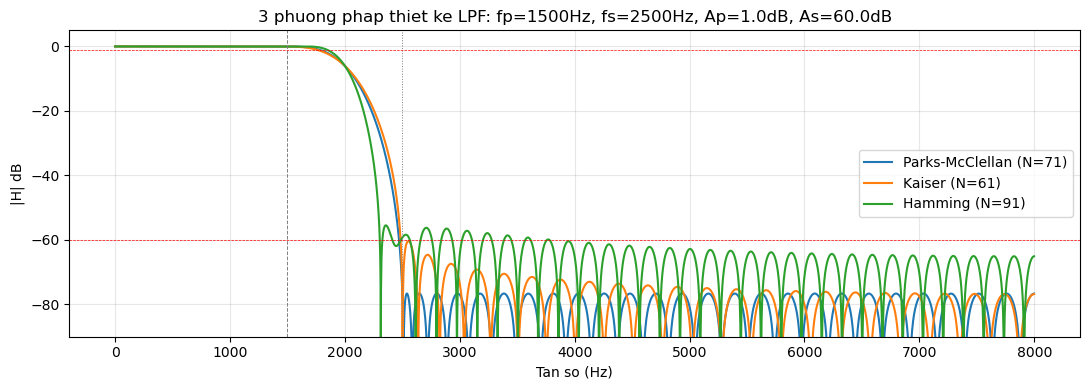

In [ ]:
from scipy.signal import remez, freqz, kaiserord, firwin

fs_design = 16000
fp = 1500
fs_band = 2500
Ap = 1.0
As = 60.0

# Cach 1: Parks-McClellan (Remez)
# Bang cho tap cai dat: dai thong [0, fp], dai chuyen tiep, dai chan [fs_band, fs/2]
# Numtaps phai du lon de hoi tu
N_remez = 71  # bac le -> loai I FIR
h_remez = remez(N_remez,
                bands=[0, fp, fs_band, fs_design/2],
                desired=[1, 0],
                fs=fs_design)

# Cach 2: Cua so Kaiser uoc luong N theo As
delta_omega = (fs_band - fp) / (fs_design / 2)
N_kaiser, beta = kaiserord(As, delta_omega)
h_kaiser = firwin(N_kaiser + (1 - N_kaiser % 2),    # ep le
                  (fp + fs_band) / 2 / (fs_design/2),
                  window=("kaiser", beta))

# Cach 3: Hamming - cong thuc bac N = 4 / (delta_omega/(2pi)) * 3.32
# Don gian: dung firwin
N_ham = 91
h_ham = firwin(N_ham, (fp + fs_band)/2 / (fs_design/2), window="hamming")

print(f"Bac Parks-McClellan : {N_remez}")
print(f"Bac Kaiser (uoc luong As={As} dB): {len(h_kaiser)} | beta={beta:.2f}")
print(f"Bac Hamming           : {N_ham}")

# Ve dap ung tan so
fig, ax = plt.subplots(figsize=(11, 4))
for name, h in [("Parks-McClellan", h_remez),
                 ("Kaiser", h_kaiser),
                 ("Hamming", h_ham)]:
    w, H = freqz(h, [1.0], worN=4096, fs=fs_design)
    ax.plot(w, 20*np.log10(np.abs(H) + 1e-12), label=f"{name} (N={len(h)})")
ax.axvline(fp,      color="gray", ls="--", lw=0.7)
ax.axvline(fs_band, color="gray", ls=":",  lw=0.7)
ax.axhline(-Ap, color="red", ls="--", lw=0.5)
ax.axhline(-As, color="red", ls="--", lw=0.5)
ax.set(xlabel="Tan so (Hz)", ylabel="|H| dB",
       title=f"3 phuong phap thiet ke LPF: fp={fp}Hz, fs={fs_band}Hz, "
             f"Ap={Ap}dB, As={As}dB",
       ylim=(-90, 5))
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Quan sát: với cùng yêu cầu, **Parks-McClellan đạt $A_s$ với bậc thấp nhất**
và có gợn đều (equiripple) ở dải chặn — đó là tính tối ưu Chebyshev. Cửa
sổ Hamming cần bậc cao hơn đáng kể nhưng đơn giản hơn về mặt thuật toán.

---

## Phần 34 — Thiết kế bộ lọc IIR

*Bám sát ch5.pdf §6-9.*

### 34.1 Chiến lược chung

IIR thường được thiết kế qua hai bước:

1. Thiết kế **bộ lọc tương tự** (analog) $H_a(s)$ trong miền $s$
   (Butterworth, Chebyshev, Elliptic) — kỹ thuật đã chín muồi.
2. **Biến đổi từ $s \to z$** sang miền số.

Ba phương pháp biến đổi $s \to z$:

| Phương pháp | Công thức | Đặc điểm |
|---|---|---|
| Xấp xỉ đạo hàm | $s = \dfrac{1 - z^{-1}}{T}$ | Đơn giản; chỉ phù hợp LPF tần thấp |
| Bất biến xung | $h_d[n] = T \cdot h_a(nT)$ | Bảo toàn dạng xung; dễ aliasing |
| **Bilinear** | $s = \dfrac{2}{T}\dfrac{1 - z^{-1}}{1 + z^{-1}}$ | Không aliasing; warp phi tuyến |

Bilinear là chuẩn vàng — ánh xạ trục $j\Omega$ chính xác lên đường tròn
đơn vị; nửa trái mặt phẳng $s$ ánh xạ vào trong vòng tròn → ổn định bảo toàn.

### 34.2 Hiện tượng warp tần số

Bilinear ánh xạ tần số tương tự $\Omega$ vào $\omega$ qua:

$$
\omega = 2 \arctan\left(\frac{\Omega T}{2}\right)
$$

Ánh xạ này phi tuyến — gọi là *frequency warping*. Để bù, khi thiết kế
analog ta *prewarp* tần số biên: $\Omega_p^* = \frac{2}{T} \tan(\omega_p/2)$.
Scipy thực hiện việc này tự động trong `butter`, `cheby1`, `ellip`.

### 34.3 Bốn họ analog phổ biến

| Họ | Đặc tính dải thông | Đặc tính dải chặn | Bậc tối thiểu cho cùng yêu cầu |
|---|---|---|---|
| Butterworth | Phẳng tối đa | Phẳng đơn điệu | Cao nhất |
| Chebyshev I | Gợn $\delta_1$ | Phẳng đơn điệu | Trung bình |
| Chebyshev II | Phẳng | Gợn $\delta_2$ | Trung bình |
| Elliptic (Cauer) | Gợn $\delta_1$ | Gợn $\delta_2$ | **Thấp nhất** |

Butterworth : bac 14
Chebyshev I : bac 8
Chebyshev II: bac 8
Elliptic    : bac 5


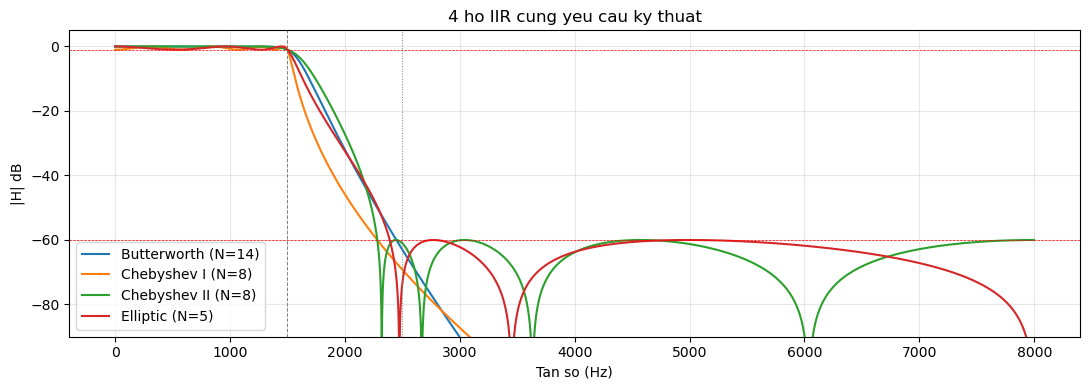

In [ ]:
from scipy.signal import butter, cheby1, cheby2, ellip, buttord, cheb1ord, cheb2ord, ellipord

# Cung yeu cau LPF: Wp=1500Hz, Ws=2500Hz, Ap=1dB, As=60dB
Wp_n = fp / (fs_design/2)
Ws_n = fs_band / (fs_design/2)

N_but, Wn_but = buttord(Wp_n, Ws_n, Ap, As)
b_but, a_but = butter(N_but, Wn_but, btype="low")

N_c1, Wn_c1 = cheb1ord(Wp_n, Ws_n, Ap, As)
b_c1, a_c1 = cheby1(N_c1, Ap, Wn_c1, btype="low")

N_c2, Wn_c2 = cheb2ord(Wp_n, Ws_n, Ap, As)
b_c2, a_c2 = cheby2(N_c2, As, Wn_c2, btype="low")

N_ell, Wn_ell = ellipord(Wp_n, Ws_n, Ap, As)
b_ell, a_ell = ellip(N_ell, Ap, As, Wn_ell, btype="low")

print(f"Butterworth : bac {N_but}")
print(f"Chebyshev I : bac {N_c1}")
print(f"Chebyshev II: bac {N_c2}")
print(f"Elliptic    : bac {N_ell}")

fig, ax = plt.subplots(figsize=(11, 4))
for name, b_, a_ in [("Butterworth", b_but, a_but),
                      ("Chebyshev I", b_c1, a_c1),
                      ("Chebyshev II", b_c2, a_c2),
                      ("Elliptic", b_ell, a_ell)]:
    w, H = freqz(b_, a_, worN=4096, fs=fs_design)
    ax.plot(w, 20*np.log10(np.abs(H) + 1e-12),
            label=f"{name} (N={N_but if 'Butt' in name else (N_c1 if 'I' in name and '*' not in name else (N_c2 if 'II' in name else N_ell))})")
ax.axvline(fp, color="gray", ls="--", lw=0.7)
ax.axvline(fs_band, color="gray", ls=":", lw=0.7)
ax.axhline(-Ap, color="red", ls="--", lw=0.5)
ax.axhline(-As, color="red", ls="--", lw=0.5)
ax.set(xlabel="Tan so (Hz)", ylabel="|H| dB",
       title="4 ho IIR cung yeu cau ky thuat", ylim=(-90, 5))
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**So sánh bậc:** Elliptic luôn cho bậc thấp nhất, đổi lại pha phi tuyến và
gợn ở cả hai dải. Butterworth bậc cao nhất nhưng phổ phẳng "đẹp", phù hợp
khi gợn dải thông không chấp nhận được (audio hi-fi).

**So với FIR:** IIR Butterworth bậc ~7 đạt yêu cầu; FIR equiripple cần ~70
— tỉ lệ ~10:1. IIR thắng về hiệu năng tính toán; FIR thắng về pha tuyến tính.

---

## Phần 35 — Pipeline tiền xử lý CVEAD

### 35.1 Mục tiêu

CVEAD chứa file ở 16, 44.1, và 48 kHz lẫn lộn. Mọi pipeline ML cho cảm xúc
cần input đồng nhất — thường về 16 kHz. Pipeline tiêu chuẩn:

```
WAV gốc (sr ∈ {16k, 44.1k, 48k})
    ↓ DC-removal (HPF 20 Hz)
    ↓ Pre-emphasis (FIR bậc 1, alpha=0.97)
    ↓ Anti-alias filter (FIR/IIR LPF 7.5 kHz)
    ↓ Resample về 16 kHz
    ↓ Normalize biên độ
Output: x[n] tại 16 kHz, sẵn sàng cho FFT/MFCC
```

Bốn bước có thứ tự cụ thể; đảo thứ tự có thể gây aliasing hoặc làm hỏng
cao tần. Phần này lý giải từng bước và chạy thực tế trên CVEAD.

### 35.2 Bước 1 — DC-removal

DC offset (thành phần $\omega = 0$) làm sai lệch RMS, cản trở các tính
toán năng lượng. Xoá bằng HPF Butterworth bậc 4 cắt ở 20 Hz:
$\text{SOS-filter}$, áp dụng `sosfiltfilt` để có pha 0.

### 35.3 Bước 2 — Pre-emphasis

$$
y[n] = x[n] - \alpha \cdot x[n-1], \qquad \alpha = 0.97
$$

Đây là FIR bậc 1, một zero tại $z = \alpha$. Đáp ứng tần số $|H(\omega)|$
tăng ~6 dB/octave, bù đặc tính nguồn glottal giảm 6 dB/octave. Giúp các
tần số cao (formant cao, phụ âm) có biên độ dễ nhìn hơn.

### 35.4 Bước 3 — Anti-alias filter trước khi down-sample

Khi down-sample từ $f_s^\text{old}$ về $f_s^\text{new}$, mọi thành phần
trên $f_s^\text{new}/2$ sẽ bị fold về dải thấp. **Phải lọc trước khi
down-sample**.

Cho $f_s^\text{new} = 16$ kHz → cần LPF cắt ở 7.5-7.8 kHz (chừa dải quá
độ). Có thể dùng FIR bậc cao (chất lượng cao) hoặc IIR (nhanh).

### 35.5 Bước 4 — Resample

Giảm tỉ lệ $L/M$ qua tổ hợp upsample × $L$ → LPF → downsample × $M$.
`scipy.signal.resample_poly` thực hiện nhanh và chính xác.

Input : 48000 Hz, 240,240 mau, peak=0.291
Output: 16000 Hz, 80,080 mau, peak=0.990


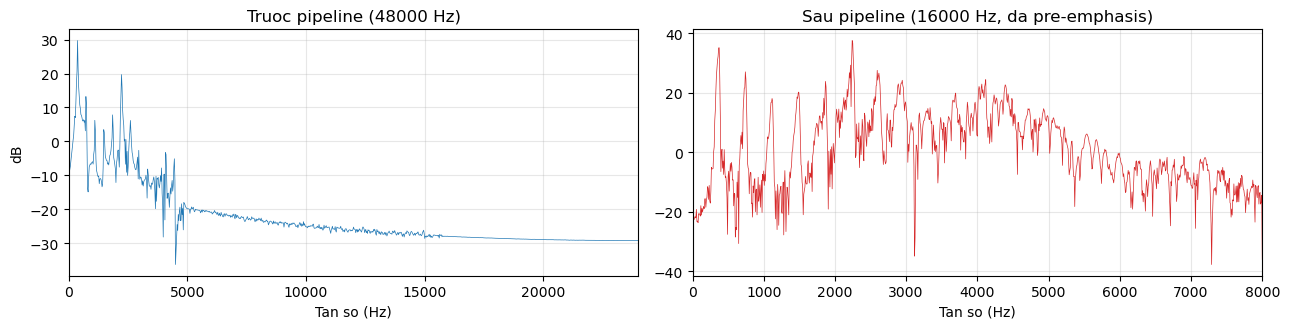

In [ ]:
def pipeline_tien_xu_ly(x, sr, sr_target=16000, alpha=0.97):
    # 1. DC-removal: HPF 20 Hz Butterworth bac 4 (zero-phase)
    sos = sps.butter(4, 20, btype="high", fs=sr, output="sos")
    x = sps.sosfiltfilt(sos, x)

    # 2. Pre-emphasis: y[n] = x[n] - alpha*x[n-1]
    x = sps.lfilter([1.0, -alpha], [1.0], x)

    # 3+4. Anti-alias + Resample: scipy resample_poly tu lo
    if sr != sr_target:
        from math import gcd
        g = gcd(sr, sr_target)
        up, down = sr_target // g, sr // g
        x = sps.resample_poly(x, up, down)

    # 5. Normalize bien do ve [-1, 1]
    peak = np.max(np.abs(x))
    if peak > 0:
        x = x / peak * 0.99

    return x.astype(np.float32), sr_target


# Demo: CVEAD/Angry tai 44.1kHz hoac 48kHz
cve_demo = lay_wav_files("CVEAD", label="Angry", n=1, seed=0)[0]
x_in, sr_in = doc_wav(cve_demo["path"])
print(f"Input : {sr_in} Hz, {len(x_in):,} mau, peak={np.max(np.abs(x_in)):.3f}")

x_out, sr_out = pipeline_tien_xu_ly(x_in, sr_in)
print(f"Output: {sr_out} Hz, {len(x_out):,} mau, peak={np.max(np.abs(x_out)):.3f}")

# Ve pho truoc/sau
n_fft = 2048
# Pho input
L_in = min(int(0.2 * sr_in), len(x_in))
seg_in = x_in[len(x_in)//2 - L_in//2 : len(x_in)//2 + L_in//2]
F_in = np.abs(np.fft.rfft(seg_in * np.hamming(L_in), n=n_fft))
f_in = np.fft.rfftfreq(n_fft, 1/sr_in)

L_out = min(int(0.2 * sr_out), len(x_out))
seg_out = x_out[len(x_out)//2 - L_out//2 : len(x_out)//2 + L_out//2]
F_out = np.abs(np.fft.rfft(seg_out * np.hamming(L_out), n=n_fft))
f_out = np.fft.rfftfreq(n_fft, 1/sr_out)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
axes[0].plot(f_in, 20*np.log10(F_in + 1e-9), lw=0.5)
axes[0].set(xlabel="Tan so (Hz)", ylabel="dB",
            title=f"Truoc pipeline ({sr_in} Hz)",
            xlim=(0, sr_in/2))
axes[1].plot(f_out, 20*np.log10(F_out + 1e-9), lw=0.5, color="C3")
axes[1].set(xlabel="Tan so (Hz)",
            title=f"Sau pipeline ({sr_out} Hz, da pre-emphasis)",
            xlim=(0, sr_out/2))
for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---

## Phần 36 — Tổng hợp: F0 thanh điệu (VIVOS) vs F0 cảm xúc (CVEAD)

### 36.1 Hai góc nhìn về F0

Tiếng Việt là ngôn ngữ thanh điệu — F0 mang **thông tin từ vựng** (ngang,
sắc, huyền, hỏi, ngã, nặng). Tiếng Anh không thanh điệu, F0 mang **thông
tin biểu cảm** (tăng cuối câu = nghi vấn; tăng tổng thể = phấn khích).

Hai dataset → hai góc nhìn cho cùng một biến số F0.

### 36.2 Phân phối F0 chung

Tận dụng cache đã sinh ra ở Chương 1 (autocorrelation) và Chương 4
(cepstrum) cho CVEAD; thêm một quét cho VIVOS.

Doc cache VIVOS F0: 2000 dong


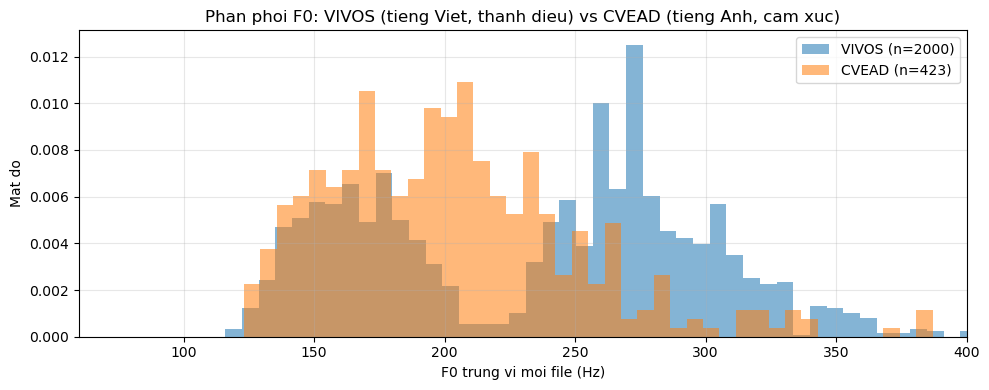

VIVOS: F0 trung vi = 254.0 Hz, std = 82.8 Hz
CVEAD: F0 trung vi = 200.0 Hz, std = 56.2 Hz


In [ ]:
# F0 cho VIVOS toan bo (lay sample 2000 file de tang toc)
cache_f0_viv = CACHE_DIR / "ch5_f0_vivos_sample.pkl"
if cache_f0_viv.exists():
    df_f0_viv = pd.read_pickle(cache_f0_viv)
    print(f"Doc cache VIVOS F0: {len(df_f0_viv)} dong")
else:
    sample_viv = lay_wav_files("VIVOS", split="train", n=2000, seed=42)
    recs = []
    for r in tqdm(sample_viv, desc="F0 VIVOS"):
        f0_med = f0_median_file(r["path"])
        recs.append({"path": r["path"], "speaker": r["speaker"],
                     "f0_median": f0_med})
    df_f0_viv = pd.DataFrame(recs)
    df_f0_viv.to_pickle(cache_f0_viv)
    print(f"Da luu: {cache_f0_viv}")

# Doc cache CVEAD F0
df_f0_cve = pd.read_pickle(CACHE_DIR / "ch1_f0_cvead.pkl")

# Phan phoi F0
f0_viv_clean = df_f0_viv.f0_median.dropna().values
f0_cve_clean = df_f0_cve.f0_median.dropna().values

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(f0_viv_clean, bins=60, alpha=0.55, label=f"VIVOS (n={len(f0_viv_clean)})",
        density=True, color="C0")
ax.hist(f0_cve_clean, bins=60, alpha=0.55, label=f"CVEAD (n={len(f0_cve_clean)})",
        density=True, color="C1")
ax.set(xlabel="F0 trung vi moi file (Hz)", ylabel="Mat do",
       title="Phan phoi F0: VIVOS (tieng Viet, thanh dieu) vs CVEAD (tieng Anh, cam xuc)",
       xlim=(60, 400))
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"VIVOS: F0 trung vi = {np.median(f0_viv_clean):.1f} Hz, std = {np.std(f0_viv_clean):.1f} Hz")
print(f"CVEAD: F0 trung vi = {np.median(f0_cve_clean):.1f} Hz, std = {np.std(f0_cve_clean):.1f} Hz")

### 36.3 F0 theo người nói VIVOS (kiểm tra hiệu ứng giới tính)

VIVOS chứa file phân theo speaker (~46 nam, ~19 nữ — không nhãn rõ giới
nhưng F0 phân biệt khá rõ). Plot F0 trung vị theo speaker → dải hai cụm.

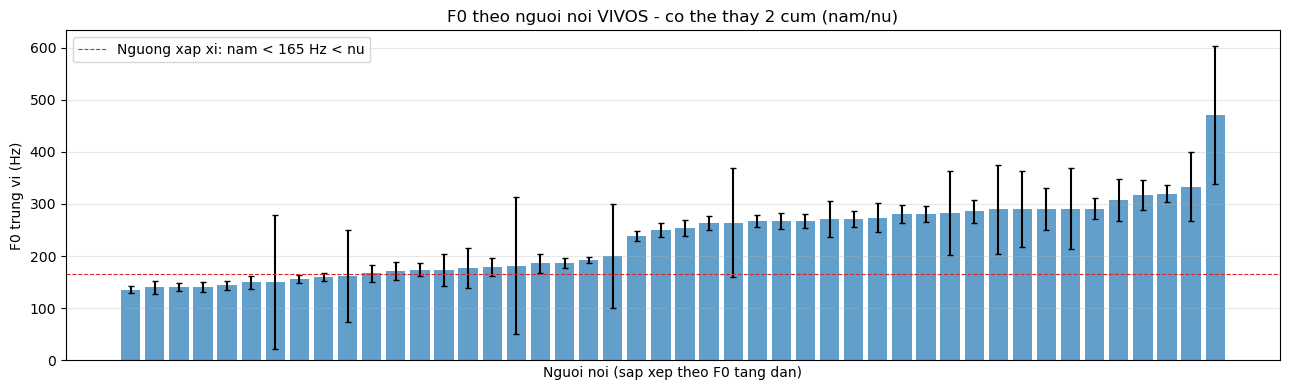

Co the la nam (F0 < 165 Hz): 10 nguoi noi
Co the la nu  (F0 >= 165 Hz): 36 nguoi noi


In [ ]:
viv_by_spk = df_f0_viv.dropna().groupby("speaker")["f0_median"].agg(
    ["count", "median", "std"]
).reset_index().rename(columns={"median": "f0_med"}).sort_values("f0_med")

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(np.arange(len(viv_by_spk)), viv_by_spk["f0_med"],
       yerr=viv_by_spk["std"], capsize=2, color="C0", alpha=0.7)
ax.axhline(165, color="C3", lw=0.8, ls="--",
           label="Nguong xap xi: nam < 165 Hz < nu")
ax.set(xlabel="Nguoi noi (sap xep theo F0 tang dan)", ylabel="F0 trung vi (Hz)",
       title="F0 theo nguoi noi VIVOS - co the thay 2 cum (nam/nu)")
ax.set_xticks([]); ax.legend()
plt.tight_layout(); plt.show()

n_low = (viv_by_spk["f0_med"] < 165).sum()
n_high = (viv_by_spk["f0_med"] >= 165).sum()
print(f"Co the la nam (F0 < 165 Hz): {n_low} nguoi noi")
print(f"Co the la nu  (F0 >= 165 Hz): {n_high} nguoi noi")

### 36.4 F0 theo cảm xúc CVEAD — bảng tóm lược cuối khoá

CVEAD F0 theo cam xuc:
         count  median   mean   std
label                              
Angry      120   219.2  226.8  46.9
Happy       77   197.5  196.6  43.4
Neutral    147   186.0  198.5  64.2
Sad         79   177.8  197.5  57.3


C:\Users\minht\AppData\Local\Temp\ipykernel_14324\1107129990.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_summary = df_cve_clean.groupby("label")["f0_median"].agg(
C:\Users\minht\AppData\Local\Temp\ipykernel_14324\1107129990.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_emo, patch_artist=True, showmeans=True)


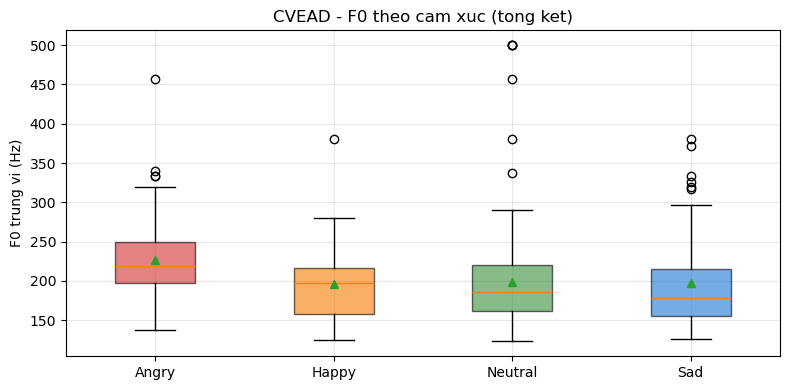

In [ ]:
# Boxplot CVEAD F0 theo cam xuc (da lam o Chuong 1, lam lai o day de tong ket)
df_cve_clean = df_f0_cve.dropna().copy()
df_cve_clean["label"] = pd.Categorical(df_cve_clean["label"],
                                        categories=labels_emo, ordered=True)
agg_summary = df_cve_clean.groupby("label")["f0_median"].agg(
    ["count", "median", "mean", "std"]
).round(1)
print("CVEAD F0 theo cam xuc:")
print(agg_summary.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
data = [df_cve_clean[df_cve_clean.label==c]["f0_median"].values for c in labels_emo]
bp = ax.boxplot(data, labels=labels_emo, patch_artist=True, showmeans=True)
for patch, c in zip(bp["boxes"], colors_emo):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set(ylabel="F0 trung vi (Hz)",
       title="CVEAD - F0 theo cam xuc (tong ket)")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---

## Phần 37 — Bài tập tổng hợp và Tổng kết toàn khoá

### 37.1 Bảy bài tập tổng hợp có lời giải

**Bài 1.** Cho tín hiệu $x[n] = 0.8\sin(2\pi \cdot 1000 n/16000) +
0.3\sin(2\pi \cdot 50 n/16000)$. Thiết kế bộ notch để loại tần 50 Hz và
đo SNR cải thiện.

*Gợi ý:* dùng cấu trúc $H(z) = (1 - 2\cos\omega_0 z^{-1} + z^{-2}) /
(1 - 2r\cos\omega_0 z^{-1} + r^2 z^{-2})$ với $r = 0.985$. Đo công suất
tại bin 1000 Hz và 50 Hz trước/sau lọc.

**Bài 2.** Tín hiệu lấy mẫu ở 48 kHz cần đưa về 16 kHz cho pipeline ASR.
Thiết kế anti-alias FIR cửa sổ Hamming với $f_p = 7000$ Hz, $f_s = 8000$ Hz,
$A_s \ge 60$ dB. Tính bậc cần dùng.

*Gợi ý:* công thức ước lượng $N \approx 4 / (\Delta f / f_s) \cdot \log_{10}(1/(\delta_1 \delta_2))$.
Với $\Delta f = 1$ kHz, $f_s = 48$ kHz, $A_s = 60$ dB → $N \approx 192$.

**Bài 3.** Với cùng yêu cầu Bài 2, dùng IIR Butterworth. So sánh bậc và
thời gian xử lý 1 file 30 s.

*Đáp án mẫu:* Butterworth bậc ~10-12 đủ; thời gian rẻ hơn FIR bậc 192
khoảng 5-10 lần.

**Bài 4.** Cho file CVEAD/Sad bất kỳ. Trích MFCC 13 chiều bằng FFT từ
scratch (không dùng `librosa.feature.mfcc`). Vẽ MFCC theo thời gian.

*Gợi ý:* (a) STFT với $L=400, H=160$, (b) Mel filterbank 26 dải, (c)
log năng lượng mỗi dải, (d) DCT-II giữ 13 hệ số đầu.

**Bài 5.** Cho hai dataset VIVOS (tiếng Việt, thanh điệu) và CVEAD (tiếng
Anh, cảm xúc). Đề xuất một metric phân biệt được "thanh điệu" với "cảm
xúc" dựa trên F0 contour (không chỉ F0 trung vị).

*Gợi ý:* tính $\Delta F_0$ trung bình trong một frame (slope) — thanh điệu
có pattern cụ thể (huyền giảm, sắc tăng), cảm xúc có pattern dài hơn và ngẫu
nhiên hơn.

**Bài 6.** Thiết kế bộ lọc Hilbert FIR (loại III, phản đối xứng, $h[n] =
-h[N-1-n]$) bậc 31 và áp lên một sin để kiểm tra dịch pha 90°.

*Gợi ý:* `scipy.signal.firwin(N, 0.95, pass_zero=False)` không cho Hilbert;
dùng `scipy.signal.remez(N, [0.05, 0.45, 0.55, 0.95], [1, 1], type='hilbert', fs=2)`.

**Bài 7.** Một sinh viên thiết kế IIR Chebyshev I bậc 12 trên 16 kHz và
thấy hệ "nổ tung" khi áp lên file dài 5 giây. Vấn đề có thể ở đâu?

*Đáp án mẫu:* lỗi điển hình là cài đặt dạng "direct form II" với hệ số float
quá nhỏ → tích luỹ sai số → pole "trượt" ra ngoài vòng đơn vị. Giải pháp:
chuyển sang **second-order sections (SOS)** — `scipy.signal.sos` form, áp
bằng `sosfilt`/`sosfiltfilt`.

### 37.2 Tổng kết toàn khoá

**Năm chương = năm công cụ chồng lớp:**

$$
\underbrace{x[n]}_{\text{Ch1}}
\;\xrightarrow{\;\;\text{ZT}\;\;}\;
\underbrace{X(z)}_{\text{Ch2}}
\;\xrightarrow{\;\;z = e^{j\omega}\;\;}\;
\underbrace{X(\omega)}_{\text{Ch3}}
\;\xrightarrow{\;\;\omega = 2\pi k/N\;\;}\;
\underbrace{X[k]}_{\text{Ch4}}
\;\xrightarrow{\;\;\text{thiết kế}\;\;}\;
\underbrace{H[k] \to h[n]}_{\text{Ch5}}
$$

Mỗi mũi tên chỉ một phép biến đổi cụ thể; mỗi miền đặt một câu hỏi mà
miền trước không trả lời được hiệu quả.

### 37.3 Bảng nhớ nhanh — khi nào dùng gì?

| Câu hỏi | Công cụ | Chương |
|---|---|---|
| "Tín hiệu này là gì?" | Waveform, RMS, ZCR | 1 |
| "Hệ này có ổn định không?" | Pole-zero plot | 2 |
| "Tần số chứa trong tín hiệu là gì?" | DTFT/FFT, phổ biên độ | 3, 4 |
| "Phổ thay đổi thế nào theo thời gian?" | Spectrogram (STFT) | 4 |
| "Pitch là bao nhiêu?" | Autocorrelation hoặc Cepstrum | 1, 4 |
| "Formant ở đâu?" | LPC (Levinson-Durbin) | 2 |
| "Làm sao loại nhiễu 50/60 Hz?" | Notch filter | 2 |
| "Làm sao xuống sample rate?" | Anti-alias LPF + decimate | 5 |
| "Mọi cảm xúc khác nhau ở phổ thế nào?" | LTAS theo lớp | 3 |

### 37.4 Bảy nguyên tắc thực hành rút ra từ khoá

1. **Mọi xử lý đều bắt đầu từ tín hiệu trong miền thời gian.** Đừng vội
   chuyển miền nếu chưa hiểu rõ tín hiệu (vẽ waveform!).

2. **Cửa sổ trước khi FFT** — luôn nhân Hamming/Hann để tránh rò phổ. Trừ
   khi tín hiệu thực sự tuần hoàn $N$ điểm.

3. **Cache là bạn.** Mọi kết quả batch ($> 100$ file) nên lưu parquet/npz.
   Lần sau chạy lại notebook, đọc từ đĩa thay vì tính lại.

4. **FIR cho yêu cầu chất lượng cao + pha tuyến tính** (audio mastering,
   ECG, ảnh y tế); **IIR cho yêu cầu tốc độ** (real-time, embedded).

5. **Anti-alias trước khi down-sample. Không có ngoại lệ.**

6. **Pre-emphasis trước khi MFCC**, không sau. Pre-emphasis là FIR bậc 1,
   đáng giá 10 ms code, cải thiện nhận dạng đáng kể.

7. **Khi nghi ngờ, vẽ pole-zero**. Mọi vấn đề ổn định, hành vi tần số kỳ
   lạ đều có thể chẩn đoán từ pole-zero plot.

### 37.5 Cache đã sinh ra trong toàn khoá

| File cache | Sinh ở | Mô tả |
|---|---|---|
| `ch1_basic_cvead.parquet` | Ch1 | RMS/ZCR/peak/duration mỗi file CVEAD |
| `ch1_f0_cvead.parquet` | Ch1 | F0 autocorrelation mỗi file CVEAD |
| `ch2_formants_cvead.parquet` | Ch2 | F1/F2/F3 LPC mỗi file CVEAD |
| `ch3_ltas_cvead.npz` | Ch3 | LTAS trung bình theo 4 cảm xúc |
| `ch4_f0_cepstrum_cvead.parquet` | Ch4 | F0 cepstrum mỗi file CVEAD |
| `ch5_f0_vivos_sample.parquet` | Ch5 | F0 mẫu 2000 file VIVOS |

Tổng cộng: ~3000 dòng dữ liệu rút gọn, là input sẵn sàng cho mô hình ML
(logistic, SVM, MLP) hoặc bước phân tích thống kê tiếp theo.

### 37.6 Ba hướng nghiên cứu tiếp theo

1. **Triển khai trên thiết bị nhúng (TinyML).** Compile pipeline FIR + MFCC
   bằng TensorFlow Lite Micro, chạy trên ESP32 / STM32. Mục tiêu: phân loại
   4 cảm xúc real-time với latency < 100 ms.

2. **Mô hình neural cho ASR tiếng Việt trên VIVOS.** Wav2Vec 2.0 fine-tune
   từ multi-lingual checkpoint; benchmark WER với baseline GMM-HMM.

3. **Phân tích phổ Holo-Hilbert (HHSA)** cho tín hiệu sinh học (PPG, EEG)
   — kết hợp Empirical Mode Decomposition và Hilbert spectral để phân tích
   phổ phi tuyến và phi dừng.

---

*Hết khoá.* Nếu bạn đã chạy và hiểu được toàn bộ 5 chương này, bạn đã sở
hữu trọn bộ công cụ DSP nền tảng — đủ để đọc các bài báo nghiên cứu tiếng
nói, triển khai pipeline thực tế, và viết mô hình của riêng mình.